# MASTER THESIS - night ventilation strategies

This notebook demonstrates the usage of the `DarkGreyBox` models via fitting them with `DarkGreyFit`

Model used: 
##### TiTmCn2R2C_summer_V9

Period:
##### 01/09 --> 15/09

## Importation

In [1]:
import sys
import importlib
from pathlib import Path
import pvlib
from scipy.interpolate import BSpline

# go from ...\docs\tutorials up two levels to the repo root (...\darkgreybox)
repo_root = Path.cwd().parents[1]
sys.path.insert(0, str(repo_root))
importlib.invalidate_caches()


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, KFold
from statsmodels.graphics.tsaplots import plot_pacf

from darkgreybox.models import TiTmCn2R2C_summer_V9
from darkgreybox.night_ventilation import simulate_night_vent_scenario, comfort_metrics
from darkgreybox.fit import darkgreyfit
from docs.tutorials.util.plot import plot
from docs.tutorials.util.error import rmse

2026-03-26 21:15:30,864 darkgreybox  INFO     Logging enabled...


In [2]:
rec_duration = 5/60

In [3]:
import pickle

RESULTS_FILE = "simulation_results.pkl"

with open(RESULTS_FILE, "rb") as f:
    saved = pickle.load(f)

df           = saved["df"]
X_train      = saved["X_train"]
y_train      = saved["y_train"]
X_test       = saved["X_test"]
y_test       = saved["y_test"]

model         = df.iloc[0][('train', 'model')]
train_results = df.iloc[0][('train', 'model_result')]
test_results  = df.iloc[0][('test', 'model_result')]

print(f"Loaded! DataFrame shape: {df.shape}")


Loaded! DataFrame shape: (1, 13)


## Train results

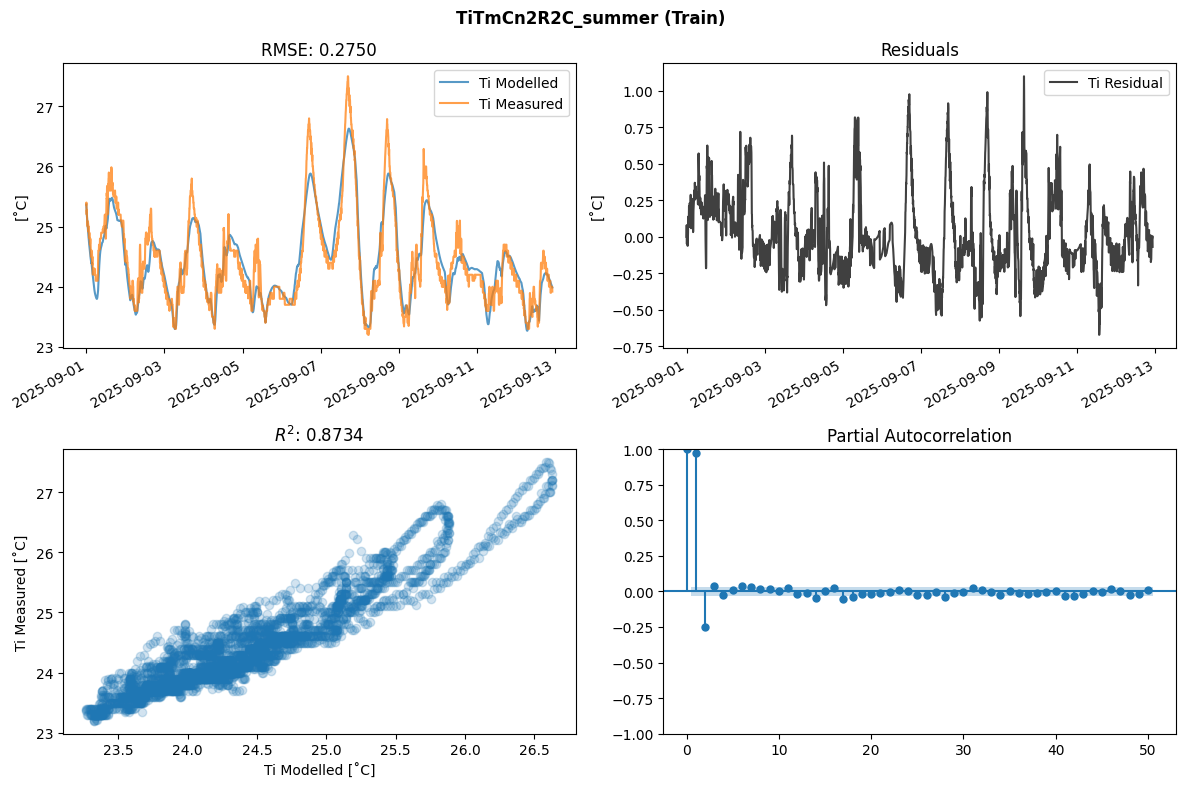

In [4]:
plot(y_train, train_results, 'TiTmCn2R2C_summer (Train)')

## Test results

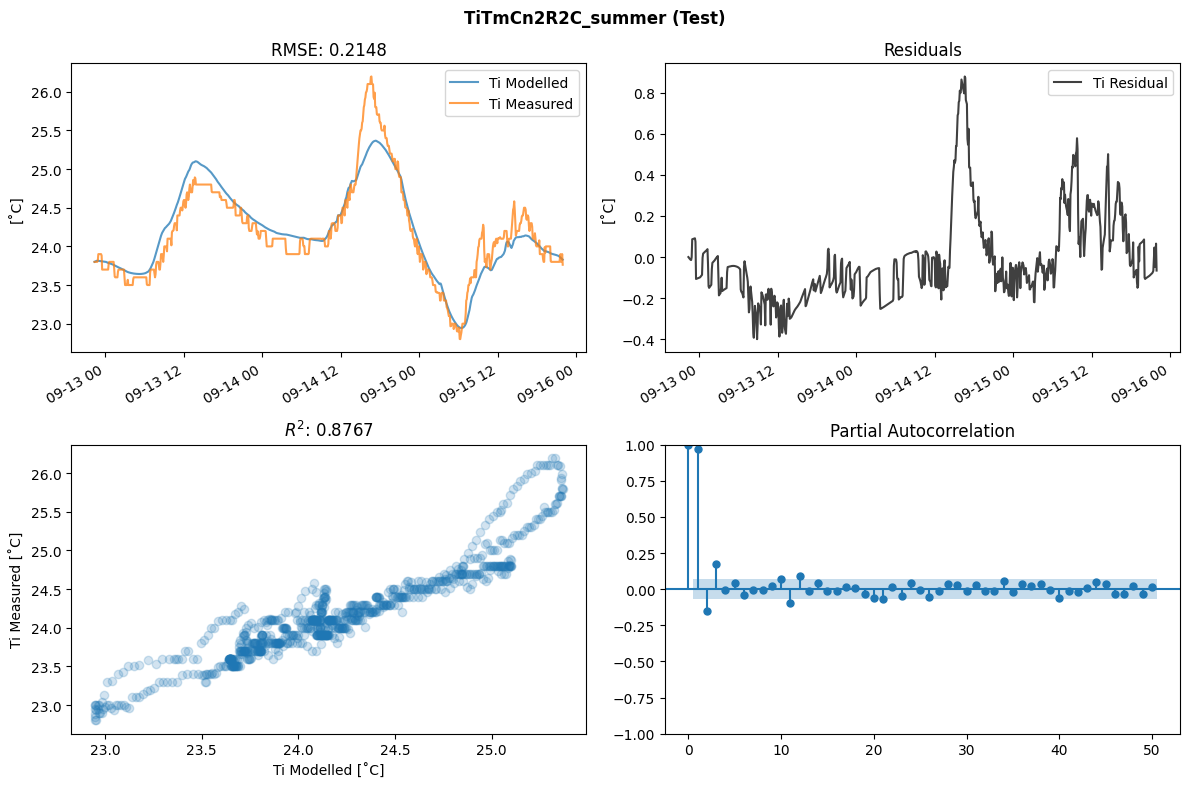

In [5]:
plot(y_test, test_results, 'TiTmCn2R2C_summer (Test)')

# Plot the main results

Using variables already in memory.


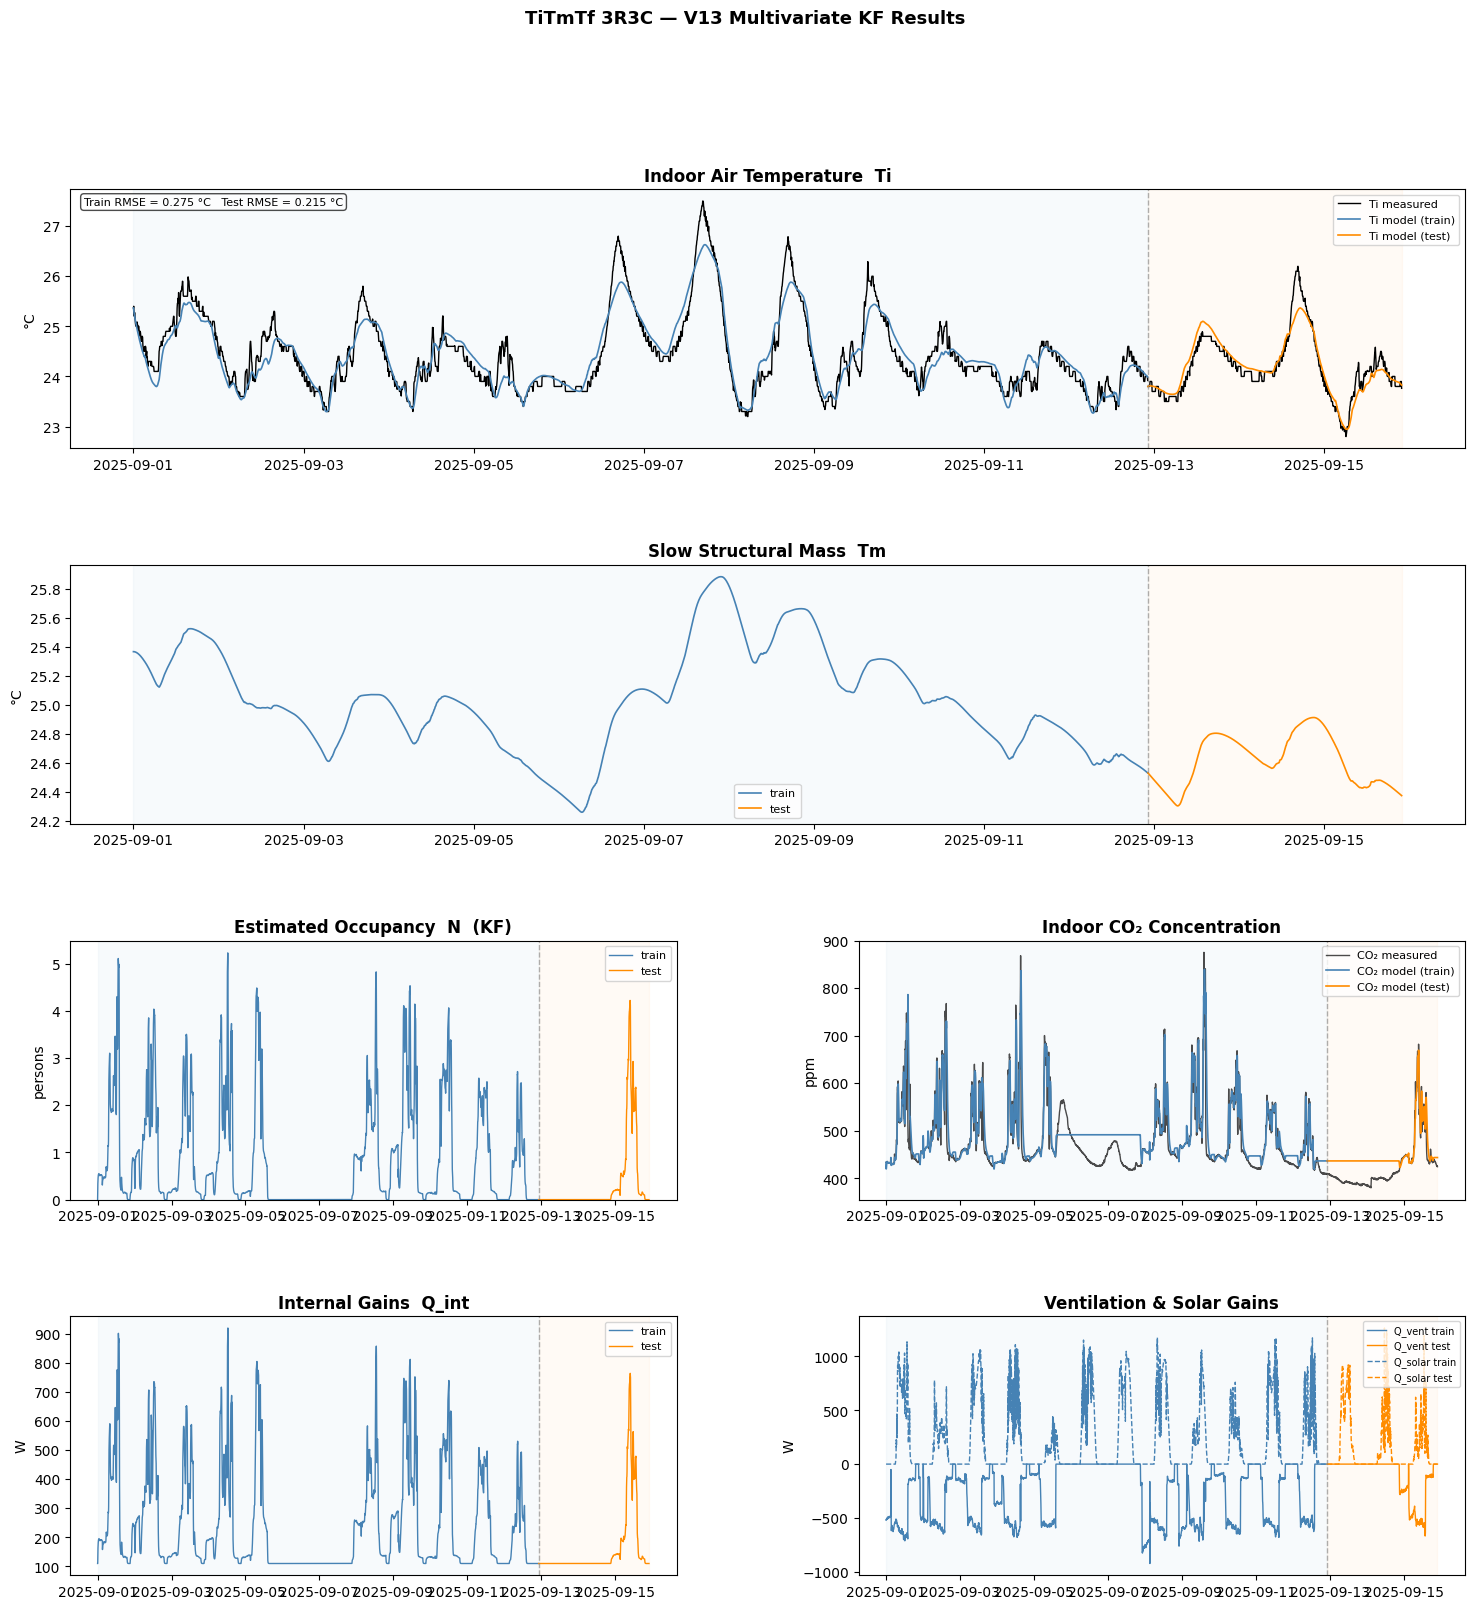

In [6]:
import pickle
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

RESULTS_FILE = "simulation_results.pkl"

# ── Load from pickle if variables are not already in memory ──────────────────
if 'df' not in dir() or 'y_train' not in dir():
    print("Variables not in memory — loading from saved file...")
    with open(RESULTS_FILE, "rb") as f:
        saved = pickle.load(f)
    df            = saved["df"]
    X_train       = saved["X_train"]
    y_train       = saved["y_train"]
    X_test        = saved["X_test"]
    y_test        = saved["y_test"]
    model         = saved["model"]
    train_results = saved["train_results"]
    test_results  = saved["test_results"]
    print("Loaded successfully!")
else:
    print("Using variables already in memory.")

# ── get_var: handles DarkGreyModelResult attribute-based access ───────────────
def get_var(result, key):
    if key in result.var:
        return np.asarray(result.var[key], dtype=float)
    print(f"Warning: '{key}' not found in result.var. Available keys: {list(result.var.keys())}")
    return None

def rmse(pred, actual):
    return np.sqrt(np.mean((np.asarray(pred) - np.asarray(actual)) ** 2))

# ── Reconstruct time index ────────────────────────────────────────────────────
train_index = X_train.index
test_index  = X_test.index

# ── Unpack results ────────────────────────────────────────────────────────────
Ti_train   = get_var(train_results, 'Ti')
Tm_train   = get_var(train_results, 'Tm')
N_train    = get_var(train_results, 'N')
c_train    = get_var(train_results, 'c')
Qint_train = get_var(train_results, 'Q_int')
Qven_train = get_var(train_results, 'Q_vent')
Qsol_train = get_var(train_results, 'Q_solar')

Ti_test    = get_var(test_results, 'Ti')
Tm_test    = get_var(test_results, 'Tm')
N_test     = get_var(test_results, 'N')
c_test     = get_var(test_results, 'c')
Qint_test  = get_var(test_results, 'Q_int')
Qven_test  = get_var(test_results, 'Q_vent')
Qsol_test  = get_var(test_results, 'Q_solar')

c_meas_train = np.asarray(X_train['c'], dtype=float)
c_meas_test  = np.asarray(X_test['c'],  dtype=float)

# ── Figure layout — 4 rows ────────────────────────────────────────────────────
fig = plt.figure(figsize=(18, 18))
gs  = gridspec.GridSpec(4, 2, figure=fig, hspace=0.45, wspace=0.3)

ax_ti   = fig.add_subplot(gs[0, :])
ax_tm   = fig.add_subplot(gs[1, :])
ax_n    = fig.add_subplot(gs[2, 0])
ax_co2  = fig.add_subplot(gs[2, 1])
ax_qint = fig.add_subplot(gs[3, 0])
ax_qven = fig.add_subplot(gs[3, 1])

def shade_split(ax):
    ax.axvline(test_index[0], color='grey', lw=1, ls='--', alpha=0.6)
    ax.axvspan(train_index[0], test_index[0],  alpha=0.04, color='steelblue')
    ax.axvspan(test_index[0],  test_index[-1], alpha=0.04, color='darkorange')

# ── 1. Ti ─────────────────────────────────────────────────────────────────────
ax_ti.plot(train_index, y_train,  color='black',      lw=1.0, label='Ti measured')
ax_ti.plot(train_index, Ti_train, color='steelblue',  lw=1.2, label='Ti model (train)')
ax_ti.plot(test_index,  y_test,   color='black',      lw=1.0)
ax_ti.plot(test_index,  Ti_test,  color='darkorange', lw=1.2, label='Ti model (test)')
shade_split(ax_ti)
ax_ti.set_title('Indoor Air Temperature  Ti', fontweight='bold')
ax_ti.set_ylabel('°C')
ax_ti.legend(fontsize=8)
ax_ti.text(0.01, 0.97,
    f'Train RMSE = {rmse(Ti_train, y_train.values):.3f} °C   '
    f'Test RMSE = {rmse(Ti_test, y_test.values):.3f} °C',
    transform=ax_ti.transAxes, va='top', fontsize=8,
    bbox=dict(boxstyle='round', fc='white', alpha=0.7))

# ── 2. Tm ─────────────────────────────────────────────────────────────────────
ax_tm.plot(train_index, Tm_train, color='steelblue',  lw=1.2, label='train')
ax_tm.plot(test_index,  Tm_test,  color='darkorange', lw=1.2, label='test')
shade_split(ax_tm)
ax_tm.set_title('Slow Structural Mass  Tm', fontweight='bold')
ax_tm.set_ylabel('°C')
ax_tm.legend(fontsize=8)

# ── 3. Occupancy N ────────────────────────────────────────────────────────────
ax_n.plot(train_index, N_train, color='steelblue',  lw=1.0, label='train')
ax_n.plot(test_index,  N_test,  color='darkorange', lw=1.0, label='test')
ax_n.set_ylim(bottom=0)
shade_split(ax_n)
ax_n.set_title('Estimated Occupancy  N  (KF)', fontweight='bold')
ax_n.set_ylabel('persons')
ax_n.legend(fontsize=8)

# ── 4. CO2 ────────────────────────────────────────────────────────────────────
ax_co2.plot(train_index, c_meas_train, color='black',      lw=1.0, alpha=0.7, label='CO₂ measured')
ax_co2.plot(train_index, c_train,      color='steelblue',  lw=1.2, label='CO₂ model (train)')
ax_co2.plot(test_index,  c_meas_test,  color='black',      lw=1.0, alpha=0.7)
ax_co2.plot(test_index,  c_test,       color='darkorange', lw=1.2, label='CO₂ model (test)')
shade_split(ax_co2)
ax_co2.set_title('Indoor CO₂ Concentration', fontweight='bold')
ax_co2.set_ylabel('ppm')
ax_co2.legend(fontsize=8)

# ── 5. Internal heat gains ────────────────────────────────────────────────────
ax_qint.plot(train_index, Qint_train, color='steelblue',  lw=1.0, label='train')
ax_qint.plot(test_index,  Qint_test,  color='darkorange', lw=1.0, label='test')
shade_split(ax_qint)
ax_qint.set_title('Internal Gains  Q_int', fontweight='bold')
ax_qint.set_ylabel('W')
ax_qint.legend(fontsize=8)

# ── 6. Ventilation + solar ────────────────────────────────────────────────────
ax_qven.plot(train_index, Qven_train, color='steelblue',  lw=1.0, label='Q_vent train')
ax_qven.plot(test_index,  Qven_test,  color='darkorange', lw=1.0, label='Q_vent test')
ax_qven.plot(train_index, Qsol_train, color='steelblue',  lw=1.0, ls='--', label='Q_solar train')
ax_qven.plot(test_index,  Qsol_test,  color='darkorange', lw=1.0, ls='--', label='Q_solar test')
shade_split(ax_qven)
ax_qven.set_title('Ventilation & Solar Gains', fontweight='bold')
ax_qven.set_ylabel('W')
ax_qven.legend(fontsize=7)

# ── Save & show ───────────────────────────────────────────────────────────────
fig.suptitle('TiTmTf 3R3C — V13 Multivariate KF Results',
             fontsize=13, fontweight='bold')
plt.savefig('V13_results.png', dpi=150, bbox_inches='tight')
plt.show()


# NIGHT VENTILATION

## Baseline + single scenario comparison

Metric                        Baseline   Night vent 22-07
---------------------------------------------------------
dh_above                          1.74 °Ch           1.05 °Ch
dh_below                          0.00 °Ch           0.00 °Ch
pct_ok                           96.39 %          97.15 %
Ti_peak                          26.63 °C          26.46 °C
Ti_mean                          24.58 °C          24.45 °C


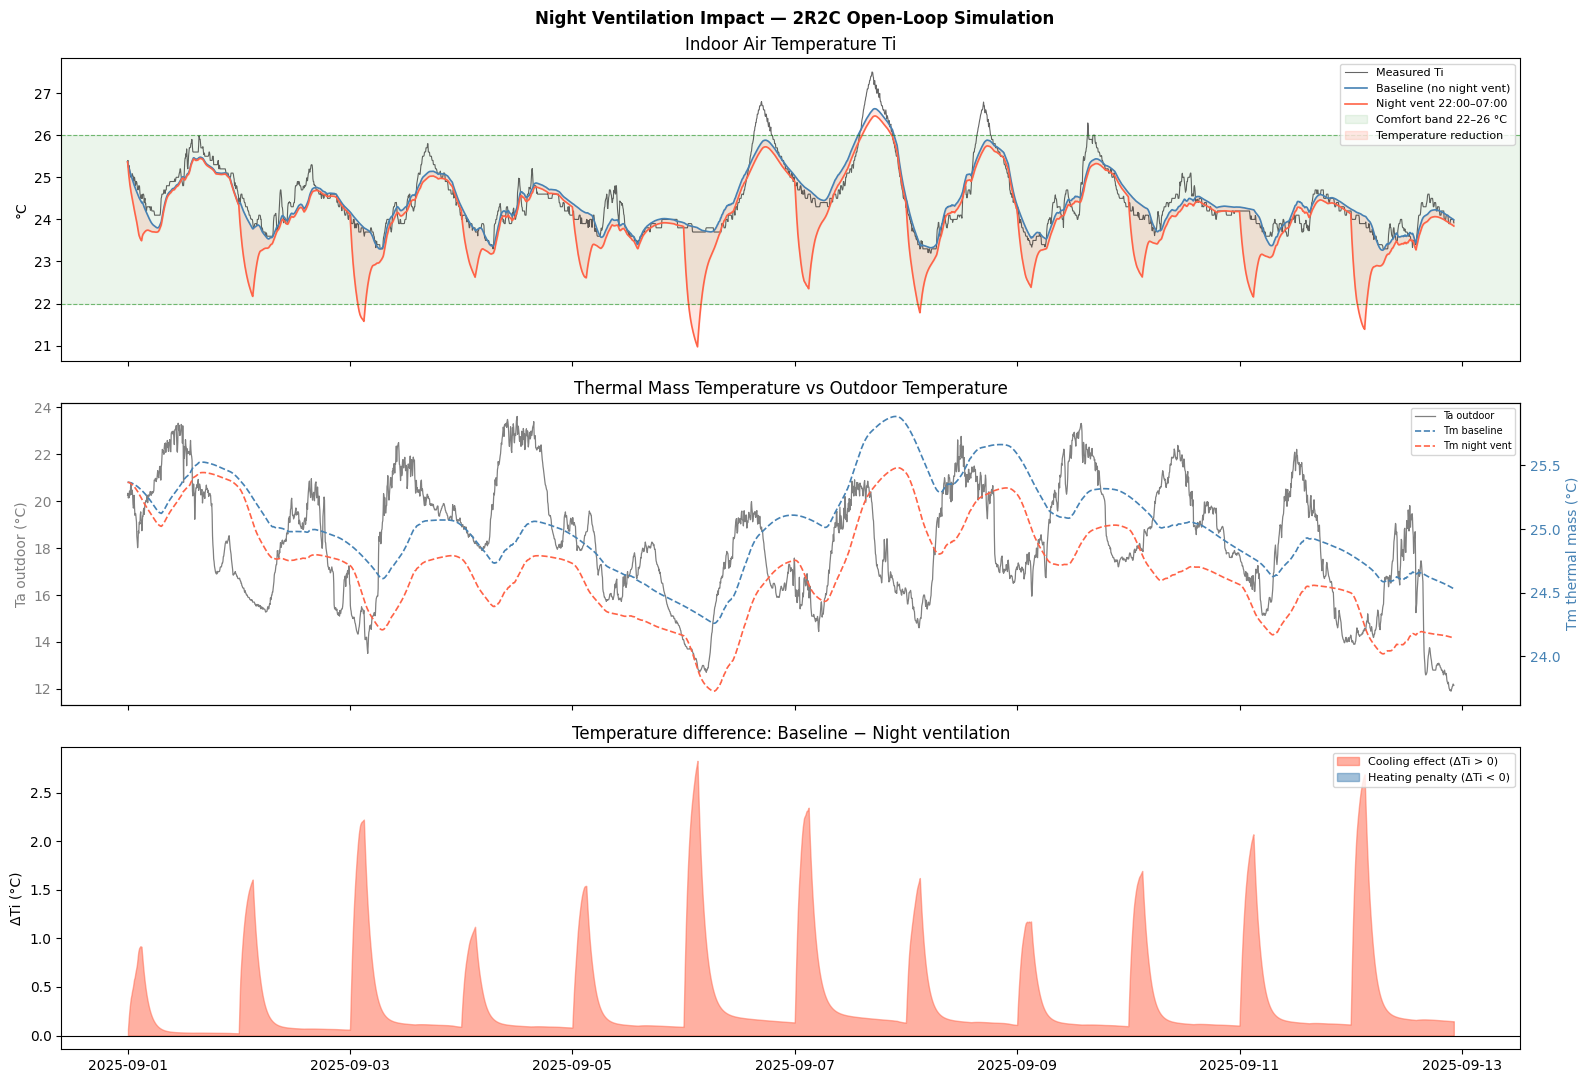

In [7]:
# Get fitted parameters from the trained model
fitted_params = model.result.params

# ── Shared initial conditions and occupancy ──────────────────────────────────
Ti_init = float(y_train.iloc[0])
Tm_init = float(train_results.var['Tm'][0])
c_init  = float(train_results.var['c'][0])
N_hist  = train_results.var['N']      # Estimated occupancy from model

# ── BASELINE: no extra night ventilation ─────────────────────────────────────
baseline = simulate_night_vent_scenario(
    fitted_params, X_train, N_hist,
    night_start_hour=0, night_stop_hour=0,   # no-op (mask always False)
    qv_night=0,
    rec_duration=rec_duration,
    Ti_init=Ti_init, Tm_init=Tm_init, c_init=c_init
)

# ── SCENARIO: night vent 22:00–07:00 at 3× normal flow ───────────────────────
qv_normal_max = float(np.percentile(np.asarray(X_train['qv'], dtype=float), 90))
qv_night_rate = 3.0 * qv_normal_max     # adjust to your system capacity

scenario = simulate_night_vent_scenario(
    fitted_params, X_train, N_hist,
    night_start_hour=0, night_stop_hour=3,
    qv_night=qv_night_rate,
    rec_duration=rec_duration,
    Ti_init=Ti_init, Tm_init=Tm_init, c_init=c_init
)

m_base = comfort_metrics(baseline['Ti'], X_train.index)
m_scen = comfort_metrics(scenario['Ti'], X_train.index)

print(f"{'Metric':<25} {'Baseline':>12} {'Night vent 22-07':>18}")
print("-" * 57)
for k in ['dh_above', 'dh_below', 'pct_ok', 'Ti_peak', 'Ti_mean']:
    unit = ' °Ch' if 'dh' in k else (' %' if 'pct' in k else ' °C')
    print(f"{k:<25} {m_base[k]:>12.2f}{unit}   {m_scen[k]:>12.2f}{unit}")

# ── Plot baseline vs scenario ─────────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(16, 11), sharex=True)
fig.suptitle('Night Ventilation Impact — 2R2C Open-Loop Simulation', fontweight='bold')

# ── 1. Ti ─────────────────────────────────────────────────────────────────────
ax = axes[0]
ax.plot(X_train.index, y_train,        color='black',     lw=0.8, alpha=0.6, label='Measured Ti')
ax.plot(X_train.index, baseline['Ti'], color='steelblue', lw=1.2, label='Baseline (no night vent)')
ax.plot(X_train.index, scenario['Ti'], color='tomato',    lw=1.2, label='Night vent 22:00–07:00')
ax.axhspan(22, 26, alpha=0.08, color='green', label='Comfort band 22–26 °C')
ax.axhline(26, color='green', lw=0.8, ls='--', alpha=0.5)
ax.axhline(22, color='green', lw=0.8, ls='--', alpha=0.5)
ax.fill_between(X_train.index,
    baseline['Ti'], scenario['Ti'],
    where=(baseline['Ti'] > scenario['Ti']),
    alpha=0.15, color='tomato', label='Temperature reduction')
ax.set_ylabel('°C')
ax.legend(fontsize=8)
ax.set_title('Indoor Air Temperature Ti')

# ── 2. Tm vs Ta — dual y-axis ─────────────────────────────────────────────────
ax_ta = axes[1]                          # left axis  → Ta outdoor
ax_tm = ax_ta.twinx()                    # right axis → Tm thermal mass

Ta_arr = np.asarray(X_train['Ta'], dtype=float)

l1, = ax_ta.plot(X_train.index, Ta_arr,           color='grey',      lw=0.9, label='Ta outdoor')
l2, = ax_tm.plot(X_train.index, baseline['Tm'],   color='steelblue', lw=1.2, ls='--', label='Tm baseline')
l3, = ax_tm.plot(X_train.index, scenario['Tm'],   color='tomato',    lw=1.2, ls='--', label='Tm night vent')

ax_ta.set_ylabel('Ta outdoor (°C)', color='grey')
ax_ta.tick_params(axis='y', labelcolor='grey')

ax_tm.set_ylabel('Tm thermal mass (°C)', color='steelblue')
ax_tm.tick_params(axis='y', labelcolor='steelblue')

# combined legend
lines  = [l1, l2, l3]
labels = [l.get_label() for l in lines]
ax_ta.legend(lines, labels, fontsize=7, loc='upper right')
ax_ta.set_title('Thermal Mass Temperature vs Outdoor Temperature')

# ── 3. Delta Ti ───────────────────────────────────────────────────────────────
ax = axes[2]
delta_Ti = baseline['Ti'].values - scenario['Ti'].values
ax.fill_between(X_train.index, delta_Ti, 0,
    where=(delta_Ti > 0), color='tomato',    alpha=0.5, label='Cooling effect (ΔTi > 0)')
ax.fill_between(X_train.index, delta_Ti, 0,
    where=(delta_Ti < 0), color='steelblue', alpha=0.5, label='Heating penalty (ΔTi < 0)')
ax.axhline(0, color='black', lw=0.8)
ax.set_ylabel('ΔTi (°C)')
ax.legend(fontsize=8)
ax.set_title('Temperature difference: Baseline − Night ventilation')

plt.tight_layout()
plt.savefig('night_vent_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


## Analysis of current night ventilation

  EXISTING NIGHT VENTILATION ANALYSIS
  Night window           : 22:00 – 07:00
  qv threshold used      : 0.0 m³/h
  Night steps total      : 1276
  Night vent active      : 931 steps  (73.0%)
  Free cooling active    : 931 steps  (73.0%)
  Missed opportunities   : 345 steps  (27.0%)
  Mean qv (night, active): 181.2 m³/h
  Max  qv (night)        : 361.9 m³/h
  Mean qv (daytime)      : 114.1 m³/h
  Mean ΔT when active    : 6.69 °C  (Ti − Ta)
  Mean ΔT missed opport. : 9.02 °C  (Ti − Ta)


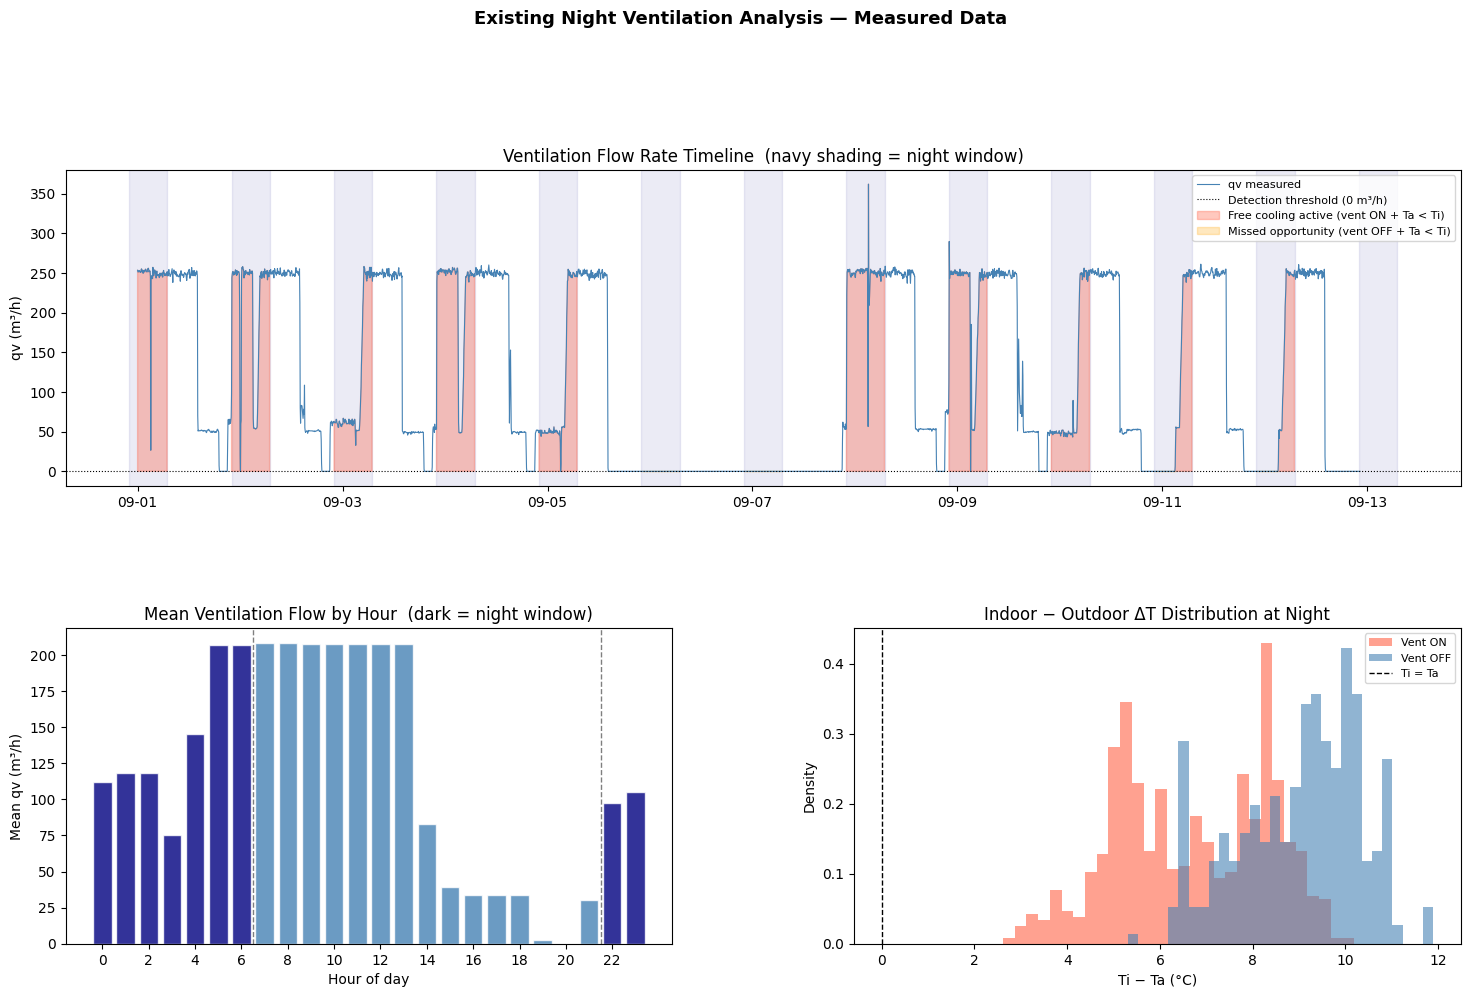

In [8]:
# ════════════════════════════════════════════════════════════════════════════
#  NIGHT VENTILATION ANALYSIS — existing behaviour in measured data
# ════════════════════════════════════════════════════════════════════════════

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import pandas as pd

# ── Config ───────────────────────────────────────────────────────────────────
NIGHT_START   = 22      # hour (inclusive)
NIGHT_STOP    = 7       # hour (exclusive, crosses midnight)
QV_THRESHOLD  = float(np.percentile(np.asarray(X_train['qv'], dtype=float), 25))
                        # anything above 25th percentile at night = "ventilation active"

# ── Raw arrays ───────────────────────────────────────────────────────────────
index   = X_train.index
qv_arr  = np.asarray(X_train['qv'],  dtype=float)
Ta_arr  = np.asarray(X_train['Ta'],  dtype=float)
Ti_meas = np.asarray(y_train,        dtype=float)
hours   = np.array([t.hour + t.minute / 60.0 for t in index])
dt_h    = (index[1] - index[0]).seconds / 3600.0

# ── Night mask (crosses midnight) ────────────────────────────────────────────
night_mask = (hours >= NIGHT_START) | (hours < NIGHT_STOP)

# ── Detect night ventilation events ──────────────────────────────────────────
night_vent_active = night_mask & (qv_arr > QV_THRESHOLD)
free_cooling_ok   = night_mask & (qv_arr > QV_THRESHOLD) & (Ta_arr < Ti_meas)
free_cooling_miss = night_mask & (qv_arr <= QV_THRESHOLD) & (Ta_arr < Ti_meas)
                    # night, no vent, but outdoor is cooler → missed opportunity

# ── Summary statistics ────────────────────────────────────────────────────────
n_night_steps        = night_mask.sum()
n_vent_steps         = night_vent_active.sum()
n_free_cooling_steps = free_cooling_ok.sum()
n_missed_steps       = free_cooling_miss.sum()

pct_night_vented     = 100 * n_vent_steps / n_night_steps if n_night_steps > 0 else 0
pct_free_cooling     = 100 * n_free_cooling_steps / n_night_steps if n_night_steps > 0 else 0
pct_missed           = 100 * n_missed_steps / n_night_steps if n_night_steps > 0 else 0

qv_night_mean = qv_arr[night_vent_active].mean() if n_vent_steps > 0 else 0
qv_night_max  = qv_arr[night_vent_active].max()  if n_vent_steps > 0 else 0
qv_day_mean   = qv_arr[~night_mask].mean()

delta_T_free  = (Ti_meas - Ta_arr)[free_cooling_ok]   # Ti - Ta when free cooling active
delta_T_miss  = (Ti_meas - Ta_arr)[free_cooling_miss]  # Ti - Ta when opportunity missed

print("=" * 60)
print("  EXISTING NIGHT VENTILATION ANALYSIS")
print("=" * 60)
print(f"  Night window           : {NIGHT_START}:00 – {NIGHT_STOP:02d}:00")
print(f"  qv threshold used      : {QV_THRESHOLD:.1f} m³/h")
print(f"  Night steps total      : {n_night_steps}")
print(f"  Night vent active      : {n_vent_steps} steps  ({pct_night_vented:.1f}%)")
print(f"  Free cooling active    : {n_free_cooling_steps} steps  ({pct_free_cooling:.1f}%)")
print(f"  Missed opportunities   : {n_missed_steps} steps  ({pct_missed:.1f}%)")
print(f"  Mean qv (night, active): {qv_night_mean:.1f} m³/h")
print(f"  Max  qv (night)        : {qv_night_max:.1f} m³/h")
print(f"  Mean qv (daytime)      : {qv_day_mean:.1f} m³/h")
if len(delta_T_free) > 0:
    print(f"  Mean ΔT when active    : {delta_T_free.mean():.2f} °C  (Ti − Ta)")
if len(delta_T_miss) > 0:
    print(f"  Mean ΔT missed opport. : {delta_T_miss.mean():.2f} °C  (Ti − Ta)")
print("=" * 60)

# ── Hourly profile: mean qv by hour ──────────────────────────────────────────
hour_int   = np.array([t.hour for t in index])
qv_by_hour = np.array([qv_arr[hour_int == h].mean() for h in range(24)])

# ── Figure ────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(18, 16))
gs  = fig.add_gridspec(3, 2, hspace=0.45, wspace=0.3)

ax1 = fig.add_subplot(gs[0, :])   # full width — qv timeline
ax2 = fig.add_subplot(gs[1, 0])   # hourly qv profile
ax3 = fig.add_subplot(gs[1, 1])   # ΔT histogram (Ti - Ta) during night

fig.suptitle('Existing Night Ventilation Analysis — Measured Data', fontsize=13, fontweight='bold')

# ── 1. qv timeline with night shading ────────────────────────────────────────
ax1.plot(index, qv_arr, color='steelblue', lw=0.8, label='qv measured')
ax1.axhline(QV_THRESHOLD, color='black', lw=0.8, ls=':', label=f'Detection threshold ({QV_THRESHOLD:.0f} m³/h)')

# shade night periods
day_start = index[0].normalize()
for d in range((index[-1] - index[0]).days + 2):
    ns = day_start + pd.Timedelta(hours=NIGHT_START + d * 24 - 24)
    ne = day_start + pd.Timedelta(hours=NIGHT_STOP   + d * 24)
    ax1.axvspan(ns, ne, alpha=0.08, color='navy', zorder=0)

# mark free-cooling active steps
ax1.fill_between(index, qv_arr, 0,
    where=free_cooling_ok, alpha=0.35, color='tomato',
    label='Free cooling active (vent ON + Ta < Ti)')
ax1.fill_between(index, QV_THRESHOLD, 0,
    where=free_cooling_miss, alpha=0.25, color='orange',
    label='Missed opportunity (vent OFF + Ta < Ti)')

ax1.set_ylabel('qv (m³/h)')
ax1.legend(fontsize=8)
ax1.set_title('Ventilation Flow Rate Timeline  (navy shading = night window)')
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))

# ── 2. Mean qv by hour of day ─────────────────────────────────────────────────
bar_colors = ['navy' if (h >= NIGHT_START or h < NIGHT_STOP) else 'steelblue'
              for h in range(24)]
ax2.bar(range(24), qv_by_hour, color=bar_colors, alpha=0.8, edgecolor='white')
ax2.axvline(NIGHT_START - 0.5, color='black', lw=1, ls='--', alpha=0.5)
ax2.axvline(NIGHT_STOP  - 0.5, color='black', lw=1, ls='--', alpha=0.5)
ax2.set_xlabel('Hour of day')
ax2.set_ylabel('Mean qv (m³/h)')
ax2.set_title('Mean Ventilation Flow by Hour  (dark = night window)')
ax2.set_xticks(range(0, 24, 2))

# ── 3. Histogram of ΔT = Ti − Ta during night ─────────────────────────────────
delta_T_all_night = (Ti_meas - Ta_arr)[night_mask]
ax3.hist(delta_T_all_night[night_vent_active[night_mask]],
         bins=30, color='tomato', alpha=0.6, label='Vent ON', density=True)
ax3.hist(delta_T_all_night[~night_vent_active[night_mask]],
         bins=30, color='steelblue', alpha=0.6, label='Vent OFF', density=True)
ax3.axvline(0, color='black', lw=1, ls='--', label='Ti = Ta')
ax3.set_xlabel('Ti − Ta (°C)')
ax3.set_ylabel('Density')
ax3.set_title('Indoor − Outdoor ΔT Distribution at Night')
ax3.legend(fontsize=8)


plt.savefig('night_vent_analysis.png', dpi=150, bbox_inches='tight')
plt.show()


# Optimization

## Optimization, baseline = no ventilation at all

Decision variables      : 11  (one qv per night, was ~1056)
qv bounds               : [0, 250] m³/h
Target                  : EN 16798-1 Category I [23.5–25.5°C]
Running optimisation...


c:\Users\clemr\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\clemr\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)



Optimisation converged : False
Final cost             : 40.7797
Optimal qv per night   : [249.7  63.  250.   51.7   nan 250.  248.1  49.    0.    0.    nan] m³/h

Metric                         Baseline (qv=0)    Optimised
------------------------------------------------------------
dh_above                                 21.65 °Ch           5.79 °Ch
dh_below                                  0.00 °Ch           0.03 °Ch
Ti_peak                                  26.72 °C          26.63 °C
Ti_mean                                  25.41 °C          24.61 °C
pct_ok (Cat. I,  occ.)                   58.13 %          89.72 %
pct_ok (Cat. II, occ.)                   83.89 %          96.39 %

  [Info only — not in optimisation]
  Night fan energy cost — Baseline (qv=0) : 0.000 DKK
  Night fan energy cost — Optimised       : 7.590 DKK
  Extra cost vs baseline                  : 7.590 DKK


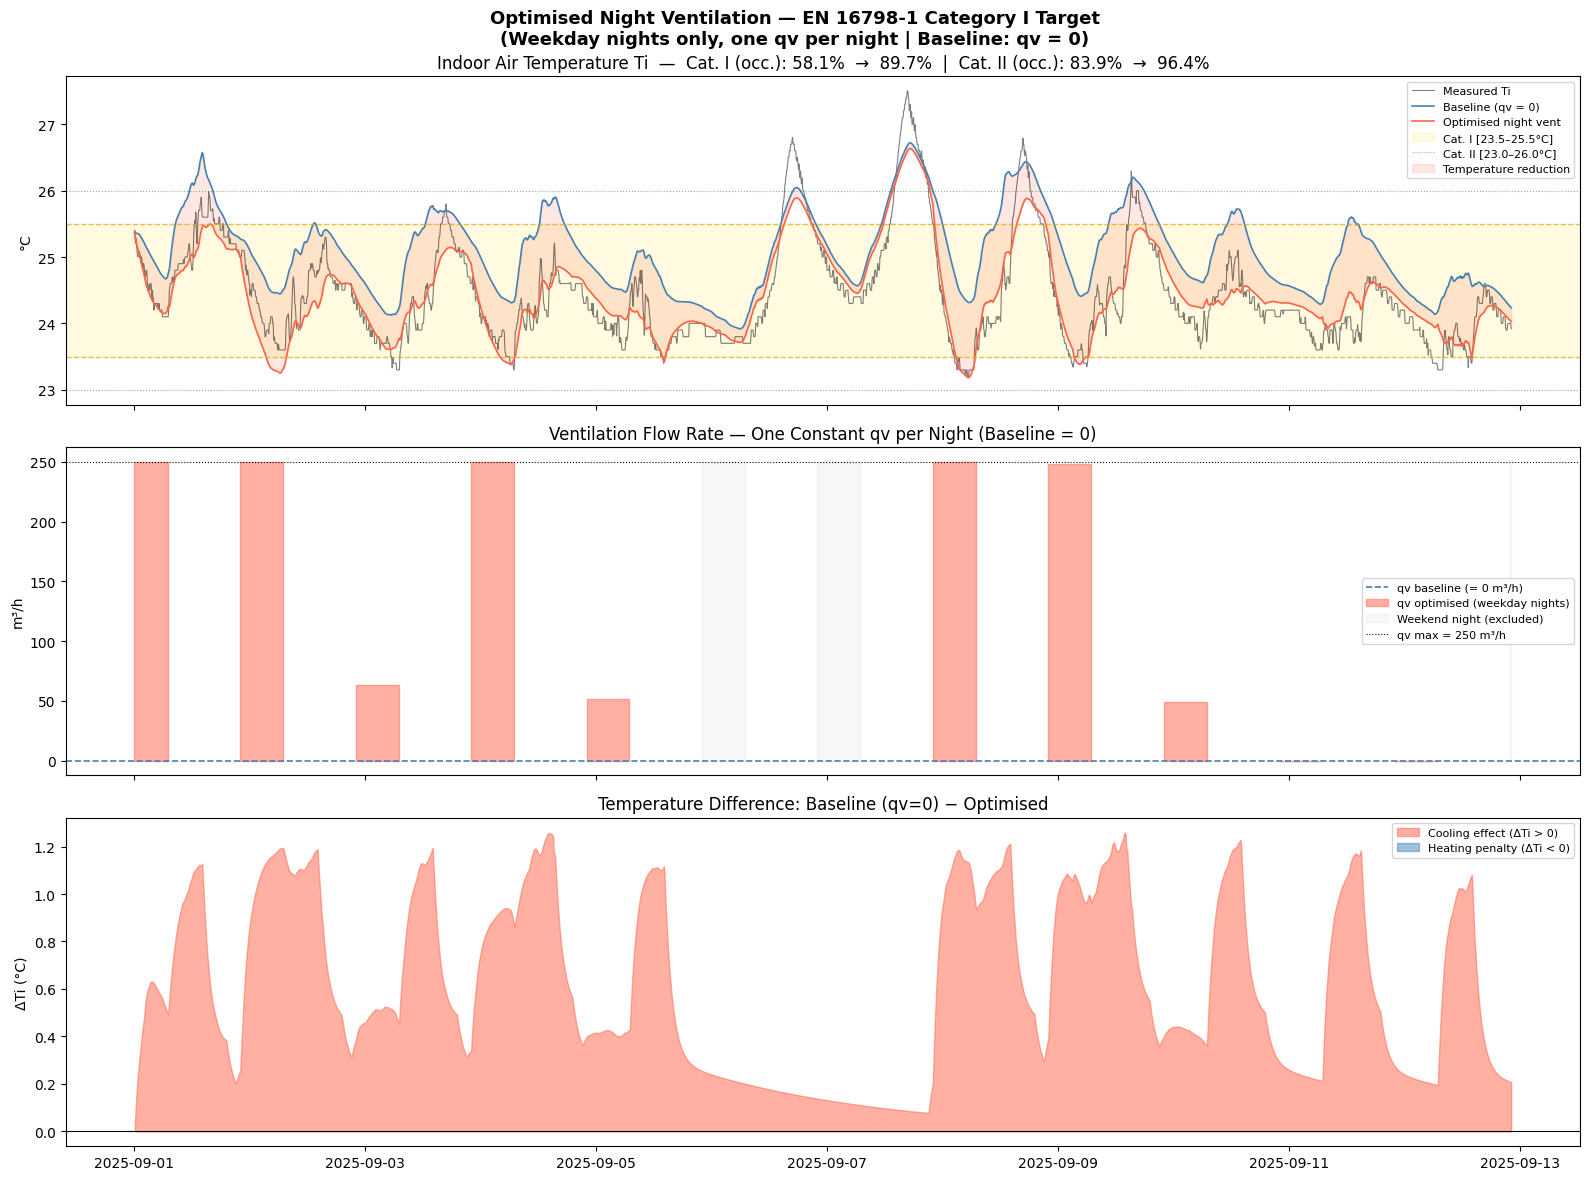

In [9]:
from scipy.optimize import minimize
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ════════════════════════════════════════════════════════════════════════════
#  CONFIG
# ════════════════════════════════════════════════════════════════════════════
T_cat1_min  = 23.5
T_cat1_max  = 25.5
T_cat2_min  = 23.0
T_cat2_max  = 26.0
OCC_START   = 8
OCC_END     = 18
NIGHT_START = 22
NIGHT_STOP  = 7


SFP         = 1.5
P_ELEC      = 1.493   # DKK/kWh — Danish commercial all-in tariff, DK2 zone


QV_MAX      = 250.0
QV_MIN      = 0.0
W_HOT       = 10.0
W_COLD      = 1.0


# ════════════════════════════════════════════════════════════════════════════
#  MASKS & PRECOMPUTED ARRAYS  (outside objective — computed once)
# ════════════════════════════════════════════════════════════════════════════
index    = X_train.index
hours    = np.array([t.hour + t.minute / 60.0 for t in index])
dt_h     = (index[1] - index[0]).seconds / 3600.0


if NIGHT_START > NIGHT_STOP:
    night_time_mask = (hours >= NIGHT_START) | (hours < NIGHT_STOP)
else:
    night_time_mask = (hours >= NIGHT_START) & (hours < NIGHT_STOP)


def next_morning_is_weekday(t):
    next_day = t + pd.Timedelta(days=1) if t.hour >= NIGHT_START else t
    return next_day.weekday() < 5


weekday_night_mask = night_time_mask & np.array(
    [next_morning_is_weekday(t) for t in index]
)
weekend_night_mask = night_time_mask & ~weekday_night_mask
occ_mask           = (hours >= OCC_START) & (hours < OCC_END)


# ── Precompute arrays once — avoids repeated DataFrame access ────────────────
qv_arr     = np.asarray(X_train['qv'],  dtype=float)
Ta_arr     = np.asarray(X_train['Ta'],  dtype=float)
Tsup_arr   = np.asarray(X_train['Tsup'], dtype=float)


# ── Key speedup: group night steps by calendar night ─────────────────────────
night_dates = pd.Series(index[weekday_night_mask]).dt.normalize().unique()
n_nights    = len(night_dates)


# Map each night step to its night index
night_step_indices = np.where(weekday_night_mask)[0]
step_to_night      = {}
for step_idx in night_step_indices:
    t = index[step_idx]
    cal_date = (t - pd.Timedelta(days=1)).normalize() if t.hour < NIGHT_START else t.normalize()
    night_num = np.searchsorted(night_dates, cal_date)
    step_to_night[step_idx] = night_num


print(f"Decision variables      : {n_nights}  (one qv per night, was ~{len(night_step_indices)})")
print(f"qv bounds               : [{QV_MIN:.0f}, {QV_MAX:.0f}] m³/h")
print(f"Target                  : EN 16798-1 Category I [{T_cat1_min}–{T_cat1_max}°C]")


# ════════════════════════════════════════════════════════════════════════════
#  BASELINE — zero ventilation everywhere
# ════════════════════════════════════════════════════════════════════════════
X_baseline         = X_train.copy()
X_baseline['qv']   = 0.0


baseline = simulate_night_vent_scenario(
    fitted_params, X_baseline, N_hist,
    night_start_hour=0, night_stop_hour=0,
    qv_night=0,
    rec_duration=rec_duration,
    Ti_init=Ti_init, Tm_init=Tm_init, c_init=c_init
)


# ════════════════════════════════════════════════════════════════════════════
#  FAST OBJECTIVE — numpy arrays only, no DataFrame copy
# ════════════════════════════════════════════════════════════════════════════
def build_X_mod(qv_per_night):
    """Build modified qv and Tsup arrays from one-per-night decision vars."""
    qv_mod   = qv_arr.copy()
    Tsup_mod = Tsup_arr.copy()
    for step_idx, night_num in step_to_night.items():
        qv_mod[step_idx]   = qv_per_night[night_num]
        Tsup_mod[step_idx] = Ta_arr[step_idx]   # free cooling
    return qv_mod, Tsup_mod


def objective(qv_per_night):
    qv_mod, Tsup_mod = build_X_mod(qv_per_night)


    X_mod = X_train.copy()
    X_mod['qv']   = qv_mod
    X_mod['Tsup'] = Tsup_mod


    result = simulate_night_vent_scenario(
        fitted_params, X_mod, N_hist,
        night_start_hour=0, night_stop_hour=0,
        qv_night=0,
        rec_duration=rec_duration,
        Ti_init=Ti_init, Tm_init=Tm_init, c_init=c_init
    )


    Ti     = result['Ti'].values
    Ti_occ = Ti[occ_mask]


    overheat   = np.maximum(0.0, Ti_occ - T_cat1_max) ** 2
    undershoot = np.maximum(0.0, T_cat1_min - Ti_occ) ** 2
    return (W_HOT * overheat.sum() + W_COLD * undershoot.sum()) * dt_h


# ════════════════════════════════════════════════════════════════════════════
#  INITIAL GUESS + BOUNDS
#  One value per night — initialise from median of measured night qv
# ════════════════════════════════════════════════════════════════════════════
x0 = np.array([
    float(np.median(qv_arr[
        [s for s, n in step_to_night.items() if n == i]
    ]))
    for i in range(n_nights)
])
bounds = [(QV_MIN, QV_MAX)] * n_nights


print("Running optimisation...")
result_opt = minimize(
    objective, x0,
    method='L-BFGS-B',
    bounds=bounds,
    options={'maxiter': 200, 'ftol': 1e-7, 'gtol': 1e-5, 'disp': True}
)


qv_opt_per_night = result_opt.x
print(f"\nOptimisation converged : {result_opt.success}")
print(f"Final cost             : {result_opt.fun:.4f}")
print(f"Optimal qv per night   : {np.round(qv_opt_per_night, 1)} m³/h")


# ════════════════════════════════════════════════════════════════════════════
#  RECONSTRUCT FULL QV ARRAY + RUN OPTIMISED SCENARIO
# ════════════════════════════════════════════════════════════════════════════
qv_opt_full, Tsup_opt_full = build_X_mod(qv_opt_per_night)


X_opt          = X_train.copy()
X_opt['qv']    = qv_opt_full
X_opt['Tsup']  = Tsup_opt_full


optimised = simulate_night_vent_scenario(
    fitted_params, X_opt, N_hist,
    night_start_hour=0, night_stop_hour=0,
    qv_night=0,
    rec_duration=rec_duration,
    Ti_init=Ti_init, Tm_init=Tm_init, c_init=c_init
)


# ════════════════════════════════════════════════════════════════════════════
#  METRICS
# ════════════════════════════════════════════════════════════════════════════
def pct_in_category(Ti_series, T_min, T_max):
    """% of OCCUPIED hours where Ti is within [T_min, T_max]."""
    Ti = np.asarray(Ti_series)[occ_mask]   # occupied hours only, reuse precomputed mask
    return float(np.mean((Ti >= T_min) & (Ti <= T_max)) * 100)


m_base = comfort_metrics(baseline['Ti'],  X_train.index,
                         T_comfort_min=T_cat1_min, T_comfort_max=T_cat1_max)
m_opt  = comfort_metrics(optimised['Ti'], X_train.index,
                         T_comfort_min=T_cat1_min, T_comfort_max=T_cat1_max)


# Occupied-hours-only % for both categories
pct1_base = pct_in_category(baseline['Ti'],  T_cat1_min, T_cat1_max)
pct1_opt  = pct_in_category(optimised['Ti'], T_cat1_min, T_cat1_max)
pct2_base = pct_in_category(baseline['Ti'],  T_cat2_min, T_cat2_max)
pct2_opt  = pct_in_category(optimised['Ti'], T_cat2_min, T_cat2_max)


print(f"\n{'Metric':<30} {'Baseline (qv=0)':>15} {'Optimised':>12}")
print("-" * 60)
for k in ['dh_above', 'dh_below', 'Ti_peak', 'Ti_mean']:
    unit  = ' °Ch' if 'dh' in k else ' °C'
    print(f"{k:<30} {m_base[k]:>15.2f}{unit}   {m_opt[k]:>12.2f}{unit}")

# Occupied-hours-only comfort percentages
print(f"{'pct_ok (Cat. I,  occ.)':<30} {pct1_base:>15.2f} %   {pct1_opt:>12.2f} %")
print(f"{'pct_ok (Cat. II, occ.)':<30} {pct2_base:>15.2f} %   {pct2_opt:>12.2f} %")


# Baseline has qv=0 everywhere so fan cost is zero
P_fan_opt_kW  = (qv_opt_full[weekday_night_mask] / 3.6) * SFP / 1000.0
cost_baseline = 0.0
cost_opt      = np.sum(P_fan_opt_kW * P_ELEC * dt_h)
print(f"\n  [Info only — not in optimisation]")
print(f"  Night fan energy cost — Baseline (qv=0) : {cost_baseline:.3f} DKK")
print(f"  Night fan energy cost — Optimised       : {cost_opt:.3f} DKK")
print(f"  Extra cost vs baseline                  : {cost_opt - cost_baseline:.3f} DKK")


# ════════════════════════════════════════════════════════════════════════════
#  PLOT
# ════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=True)
fig.suptitle('Optimised Night Ventilation — EN 16798-1 Category I Target\n'
             '(Weekday nights only, one qv per night | Baseline: qv = 0)',
             fontsize=13, fontweight='bold')


ax = axes[0]
ax.plot(index, y_train,         color='black',     lw=0.8, alpha=0.5, label='Measured Ti')
ax.plot(index, baseline['Ti'],  color='steelblue', lw=1.2, label='Baseline (qv = 0)')
ax.plot(index, optimised['Ti'], color='tomato',    lw=1.2, label='Optimised night vent')
ax.axhspan(T_cat1_min, T_cat1_max, alpha=0.12, color='gold',
           label=f'Cat. I [{T_cat1_min}–{T_cat1_max}°C]')
ax.axhline(T_cat1_max, color='goldenrod', lw=1.0, ls='--', alpha=0.7)
ax.axhline(T_cat1_min, color='goldenrod', lw=1.0, ls='--', alpha=0.7)
ax.axhline(T_cat2_max, color='green',     lw=0.8, ls=':', alpha=0.5,
           label=f'Cat. II [{T_cat2_min}–{T_cat2_max}°C]')
ax.axhline(T_cat2_min, color='green',     lw=0.8, ls=':', alpha=0.5)
ax.fill_between(index,
    baseline['Ti'], optimised['Ti'],
    where=(baseline['Ti'] > optimised['Ti']),
    alpha=0.15, color='tomato', label='Temperature reduction')
ax.set_ylabel('°C')
ax.legend(fontsize=8)
ax.set_title(f'Indoor Air Temperature Ti  —  '
             f'Cat. I (occ.): {pct1_base:.1f}%  →  {pct1_opt:.1f}%  |  '
             f'Cat. II (occ.): {pct2_base:.1f}%  →  {pct2_opt:.1f}%')


ax = axes[1]
# Baseline qv is 0 everywhere — no fill needed, just a reference line
ax.axhline(0, color='steelblue', lw=1.2, ls='--', label='qv baseline (= 0 m³/h)')
ax.fill_between(index, qv_opt_full, 0,
    where=weekday_night_mask, alpha=0.5, color='tomato',
    label='qv optimised (weekday nights)')
ax.fill_between(index, QV_MAX, 0,
    where=weekend_night_mask, alpha=0.06, color='grey',
    label='Weekend night (excluded)')
ax.axhline(QV_MAX, color='black', lw=0.8, ls=':',
           label=f'qv max = {QV_MAX:.0f} m³/h')
ax.set_ylabel('m³/h')
ax.legend(fontsize=8)
ax.set_title('Ventilation Flow Rate — One Constant qv per Night (Baseline = 0)')


ax = axes[2]
delta = baseline['Ti'].values - optimised['Ti'].values
ax.fill_between(index, delta, 0,
    where=(delta > 0), color='tomato',    alpha=0.5, label='Cooling effect (ΔTi > 0)')
ax.fill_between(index, delta, 0,
    where=(delta < 0), color='steelblue', alpha=0.5, label='Heating penalty (ΔTi < 0)')
ax.axhline(0, color='black', lw=0.8)
ax.set_ylabel('ΔTi (°C)')
ax.legend(fontsize=8)
ax.set_title('Temperature Difference: Baseline (qv=0) − Optimised')


plt.tight_layout()
plt.savefig('night_vent_optimised_cat1.png', dpi=150, bbox_inches='tight')
plt.show()


## Last version

### Pre-computation block

In [10]:
# ════════════════════════════════════════════════════════════════════════════
#  PRE-COMPUTATION
# ════════════════════════════════════════════════════════════════════════════
import numpy as np
import pandas as pd
from scipy.optimize import minimize
import matplotlib.pyplot as plt

# ── CONFIG ───────────────────────────────────────────────────────────────────
T_cat1_min        = 22.0   # Custom category: 22–24 °C (replaces EN16798 Cat II)
T_cat1_max        = 24.0
T_TARGET          = 23.0   # Setpoint ±1 °C deadband
TA_MIN_NIGHT_VENT = 14.0   # Min T_ext for night vent — condensation dew-point limit
NIGHT_START       = 22
NIGHT_STOP        = 7
OCC_START         = 8
OCC_END           = 18
dt_h              = rec_duration

# ── TIME / WEEKDAY ARRAYS ────────────────────────────────────────────────────
hours    = np.array([t.hour + t.minute / 60.0 for t in index])
weekdays = np.array([t.weekday() for t in index])

# ── OCCUPANCY MASKS ──────────────────────────────────────────────────────────
occ_mask         = (hours >= OCC_START) & (hours < OCC_END)
weekday_day_mask = occ_mask & (weekdays < 5)

# ── NIGHT MASK ───────────────────────────────────────────────────────────────
if NIGHT_START > NIGHT_STOP:
    nighttime_mask = (hours >= NIGHT_START) | (hours < NIGHT_STOP)
else:
    nighttime_mask = (hours >= NIGHT_START) & (hours < NIGHT_STOP)

def _next_morning_is_weekday(t):
    ref = t + pd.Timedelta(days=1) if t.hour >= NIGHT_START else t
    return ref.weekday() < 5

weekday_night_mask = nighttime_mask & np.array(
    [_next_morning_is_weekday(t) for t in index])
weekend_night_mask = nighttime_mask & ~weekday_night_mask
all_night_mask     = nighttime_mask.copy()

# ── FREE-COOLING ELIGIBILITY (condensation constraint: T_ext > 14°C) ─────────
Ta_arr     = np.asarray(X_train['Ta'], dtype=float)
ta_ok_mask = Ta_arr > TA_MIN_NIGHT_VENT   # False → qv forced to 0 at night

# ── HELPER FUNCTIONS ─────────────────────────────────────────────────────────
def pct_in_band(Ti_series, Tmin, Tmax, mask):
    Ti = np.asarray(Ti_series)[mask]
    return float(np.mean((Ti >= Tmin) & (Ti <= Tmax)) * 100)

def fan_cost(qv_array):
    P_kW = np.asarray(qv_array) / 3.6 * SFP / 1000.0
    return float(np.sum(P_kW) * P_ELEC * dt_h)

def dh_from_target(Ti_arr, T_target=T_TARGET, mask=None):
    """
    Returns (degree-hours above T_target, degree-hours below T_target).
    If mask is given, only computes over that subset.
    Units: °C·h (integrated over time using dt_h).
    """
    Ti = np.asarray(Ti_arr)
    if mask is not None:
        Ti = Ti[mask]
    dh_above = float(np.sum(np.maximum(0.0, Ti - T_target)) * dt_h)
    dh_below = float(np.sum(np.maximum(0.0, T_target - Ti)) * dt_h)
    return dh_above, dh_below

# ── qv ARRAYS ────────────────────────────────────────────────────────────────
qv_arr      = np.asarray(X_train['qv'], dtype=float)
qv_baseline = qv_arr.copy()
qv_baseline[weekday_night_mask] = 0.0

# ── FULL-DAY OPTIMISATION LAYOUT ─────────────────────────────────────────────
_idx_s      = pd.Series(index)
occ_dates   = _idx_s[occ_mask].dt.normalize().unique()
night_dates = _idx_s[weekday_night_mask].dt.normalize().unique()
n_days_occ  = len(occ_dates)
n_nights    = len(night_dates)
night_indices = np.where(weekday_night_mask)[0]

def build_X_fullday(qv_params):
    """
    Map flat params → (qv_full, Tsup_full).
    Layout: [qv_day_0 … qv_day_{n_days_occ-1},
             qv_night_0 … qv_night_{n_nights-1}]

    Condensation constraint enforced:
      - qv = 0 at night when Ta ≤ TA_MIN_NIGHT_VENT (14°C)
      - Tsup = Ta only when night vent is active AND Ta > 14°C
    """
    qv_day_p   = qv_params[:n_days_occ]
    qv_night_p = qv_params[n_days_occ:]
    qv_mod     = np.zeros(len(qv_arr))
    Tsup_mod   = np.asarray(X_train['Tsup'], dtype=float).copy()

    for i, d in enumerate(occ_dates):
        mask_d = (_idx_s.dt.normalize() == d).values & occ_mask
        qv_mod[mask_d] = qv_day_p[i]

    for j, d in enumerate(night_dates):
        mask_n        = (_idx_s.dt.normalize() == d).values & weekday_night_mask
        eligible      = mask_n & ta_ok_mask          # Ta > 14°C check
        suppressed    = mask_n & ~ta_ok_mask          # Ta ≤ 14°C → forced to 0

        qv_mod[eligible]   = qv_night_p[j]           # vent only when eligible
        qv_mod[suppressed] = 0.0                      # hard zero — condensation risk
        Tsup_mod[eligible] = Ta_arr[eligible]         # T_ext as supply when eligible
        # suppressed steps: Tsup stays as original (no cold outdoor air)

    return qv_mod, Tsup_mod

# ═══════════════════════════════════════════════════════════════════════
#  SCENARIO 1 — BASE SIMULATION
# ═══════════════════════════════════════════════════════════════════════
base_sim_result = simulate_night_vent_scenario(
    fitted_params, X_train, N_hist,
    night_start_hour=0, night_stop_hour=0, qv_night=0,
    rec_duration=rec_duration,
    Ti_init=Ti_init, Tm_init=Tm_init, c_init=c_init)

Ti_ref        = np.asarray(base_sim_result['Ti'])
cost_ref      = fan_cost(qv_arr)
pct_occ_ref   = pct_in_band(Ti_ref, T_cat1_min, T_cat1_max, occ_mask)
pct_night_ref = pct_in_band(Ti_ref, T_cat1_min, T_cat1_max, all_night_mask)
dh_above_ref,     dh_below_ref     = dh_from_target(Ti_ref)
dh_above_ref_occ, dh_below_ref_occ = dh_from_target(Ti_ref, mask=occ_mask)

_dev_ref       = (np.maximum(0.0, Ti_ref - T_TARGET) ** 2
                + np.maximum(0.0, T_TARGET - Ti_ref) ** 2)
Ti_cost_ref    = float(_dev_ref.sum() * dt_h)
fan_cost_ref_v = cost_ref

pct_occ_meas   = pct_in_band(y_train, T_cat1_min, T_cat1_max, occ_mask)

# ═══════════════════════════════════════════════════════════════════════
#  SCENARIO 2 — meas_text (original qv + T_ext as Tsup at night, only if > 14°C)
# ═══════════════════════════════════════════════════════════════════════
X_meas_text = X_train.copy()
# Only swap Tsup when Ta > 14°C (condensation constraint)
eligible_night = weekday_night_mask & ta_ok_mask
X_meas_text.loc[eligible_night, 'Tsup'] = Ta_arr[eligible_night]

meas_text = simulate_night_vent_scenario(
    fitted_params, X_meas_text, N_hist,
    night_start_hour=0, night_stop_hour=0, qv_night=0,
    rec_duration=rec_duration,
    Ti_init=Ti_init, Tm_init=Tm_init, c_init=c_init)

qv_meas_text        = qv_arr.copy()
cost_meas_text      = fan_cost(qv_meas_text)
pct_occ_meas_text   = pct_in_band(meas_text['Ti'], T_cat1_min, T_cat1_max, occ_mask)
pct_night_meas_text = pct_in_band(meas_text['Ti'], T_cat1_min, T_cat1_max, all_night_mask)

# ═══════════════════════════════════════════════════════════════════════
#  SCENARIO 3 — BASELINE (no night ventilation)
# ═══════════════════════════════════════════════════════════════════════
X_base       = X_train.copy()
X_base['qv'] = qv_baseline

baseline = simulate_night_vent_scenario(
    fitted_params, X_base, N_hist,
    night_start_hour=0, night_stop_hour=0, qv_night=0,
    rec_duration=rec_duration,
    Ti_init=Ti_init, Tm_init=Tm_init, c_init=c_init)

pct_occ_base   = pct_in_band(baseline['Ti'], T_cat1_min, T_cat1_max, occ_mask)
pct_night_base = pct_in_band(baseline['Ti'], T_cat1_min, T_cat1_max, all_night_mask)
cost_baseline  = fan_cost(qv_baseline)

# ═══════════════════════════════════════════════════════════════════════
#  SCENARIO 4 — NO VENTILATION AT ALL
# ═══════════════════════════════════════════════════════════════════════
X_novent         = X_train.copy()
X_novent['qv']   = 0.0
X_novent['Tsup'] = Ta_arr

novent_result = simulate_night_vent_scenario(
    fitted_params, X_novent, N_hist,
    night_start_hour=0, night_stop_hour=0, qv_night=0,
    rec_duration=rec_duration,
    Ti_init=Ti_init, Tm_init=Tm_init, c_init=c_init)

Ti_novent        = np.asarray(novent_result['Ti'])
cost_novent      = fan_cost(np.zeros(len(qv_arr)))
pct_occ_novent   = pct_in_band(Ti_novent, T_cat1_min, T_cat1_max, occ_mask)
pct_night_novent = pct_in_band(Ti_novent, T_cat1_min, T_cat1_max, all_night_mask)

# ═══════════════════════════════════════════════════════════════════════
#  SCENARIO 5 — OPTIMISED NIGHT VENT (22–24 °C band, one qv per night)
# ═══════════════════════════════════════════════════════════════════════
def _objective_night(qv_night_vec):
    qv_mod   = qv_arr.copy()
    Tsup_mod = np.asarray(X_train['Tsup'], dtype=float).copy()

    for j, d in enumerate(night_dates):
        mask_n     = (_idx_s.dt.normalize() == d).values & weekday_night_mask
        eligible   = mask_n & ta_ok_mask       # Ta > 14°C
        suppressed = mask_n & ~ta_ok_mask      # Ta ≤ 14°C → no vent

        qv_mod[eligible]   = qv_night_vec[j]
        qv_mod[suppressed] = 0.0               # condensation constraint
        Tsup_mod[eligible] = Ta_arr[eligible]  # T_ext as supply

    X_mod         = X_train.copy()
    X_mod['qv']   = qv_mod
    X_mod['Tsup'] = Tsup_mod

    result = simulate_night_vent_scenario(
        fitted_params, X_mod, N_hist,
        night_start_hour=0, night_stop_hour=0, qv_night=0,
        rec_duration=rec_duration,
        Ti_init=Ti_init, Tm_init=Tm_init, c_init=c_init)

    Ti = result['Ti'].values
    if not np.all(np.isfinite(Ti)):
        return 1e10

    Ti_occ     = Ti[occ_mask]
    overheat   = np.maximum(0.0, Ti_occ - T_cat1_max) ** 2
    undershoot = np.maximum(0.0, T_cat1_min - Ti_occ) ** 2
    return float((overheat.sum() + undershoot.sum()) * dt_h)

print(f"Running Scenario 5 — optimised night vent ({n_nights} nights)...")
_res5 = minimize(
    _objective_night,
    x0=np.full(n_nights, QV_MAX / 2.0),
    method='L-BFGS-B',
    bounds=[(QV_MIN, QV_MAX)] * n_nights,
    options={'maxiter': 300, 'ftol': 1e-9, 'gtol': 1e-6, 'eps': 1.0}
)
qv_opt_per_night = np.clip(np.nan_to_num(_res5.x, nan=0.0), QV_MIN, QV_MAX)
print(f"  Converged: {_res5.success}  |  cost: {_res5.fun:.4f}")

qv_opt_full  = qv_arr.copy()
Tsup_opt     = np.asarray(X_train['Tsup'], dtype=float).copy()
for j, d in enumerate(night_dates):
    mask_n     = (_idx_s.dt.normalize() == d).values & weekday_night_mask
    eligible   = mask_n & ta_ok_mask
    suppressed = mask_n & ~ta_ok_mask

    qv_opt_full[eligible]   = qv_opt_per_night[j]
    qv_opt_full[suppressed] = 0.0
    Tsup_opt[eligible]      = Ta_arr[eligible]

X_opt         = X_train.copy()
X_opt['qv']   = qv_opt_full
X_opt['Tsup'] = Tsup_opt

optimised = simulate_night_vent_scenario(
    fitted_params, X_opt, N_hist,
    night_start_hour=0, night_stop_hour=0, qv_night=0,
    rec_duration=rec_duration,
    Ti_init=Ti_init, Tm_init=Tm_init, c_init=c_init)

pct_occ_opt    = pct_in_band(optimised['Ti'], T_cat1_min, T_cat1_max, occ_mask)
pct_night_opt  = pct_in_band(optimised['Ti'], T_cat1_min, T_cat1_max, all_night_mask)
cost_optimised = fan_cost(qv_opt_full)

# ═══════════════════════════════════════════════════════════════════════
#  SCENARIO 6 — OPTIMISED DAY+NIGHT (minimise Σ(Ti−23°C)²·dt)
# ═══════════════════════════════════════════════════════════════════════
def _objective_fullday(qv_params):
    qv_safe = np.clip(np.nan_to_num(qv_params, nan=QV_MAX / 2.0), QV_MIN, QV_MAX)
    qv_mod, Tsup_mod = build_X_fullday(qv_safe)  # condensation constraint inside

    X_mod         = X_train.copy()
    X_mod['qv']   = qv_mod
    X_mod['Tsup'] = Tsup_mod

    result = simulate_night_vent_scenario(
        fitted_params, X_mod, N_hist,
        night_start_hour=0, night_stop_hour=0, qv_night=0,
        rec_duration=rec_duration,
        Ti_init=Ti_init, Tm_init=Tm_init, c_init=c_init)

    Ti = result['Ti'].values
    if not np.all(np.isfinite(Ti)):
        return 1e10
    dev = (np.maximum(0.0, Ti - T_TARGET) ** 2
         + np.maximum(0.0, T_TARGET - Ti) ** 2)
    return float(dev.sum() * dt_h)

print("Running Scenario 6 — optimised day+night (23°C target)...")
_res6 = minimize(
    _objective_fullday,
    x0=np.full(n_days_occ + n_nights, QV_MAX / 2.0),
    method='L-BFGS-B',
    bounds=[(QV_MIN, QV_MAX)] * (n_days_occ + n_nights),
    options={'maxiter': 500, 'ftol': 1e-9, 'gtol': 1e-6, 'eps': 1.0}
)
qv_fullday_params = np.clip(np.nan_to_num(_res6.x, nan=0.0), QV_MIN, QV_MAX)
print(f"  Converged: {_res6.success}  |  cost: {_res6.fun:.4f}")

qv_fullday_full, Tsup_fullday = build_X_fullday(qv_fullday_params)
X_fullday         = X_train.copy()
X_fullday['qv']   = qv_fullday_full
X_fullday['Tsup'] = Tsup_fullday

optimised_fullday = simulate_night_vent_scenario(
    fitted_params, X_fullday, N_hist,
    night_start_hour=0, night_stop_hour=0, qv_night=0,
    rec_duration=rec_duration,
    Ti_init=Ti_init, Tm_init=Tm_init, c_init=c_init)

Ti_fullday        = np.asarray(optimised_fullday['Ti'])
pct_occ_fullday   = pct_in_band(Ti_fullday, T_cat1_min, T_cat1_max, occ_mask)
pct_night_fullday = pct_in_band(Ti_fullday, T_cat1_min, T_cat1_max, all_night_mask)
cost_fullday      = fan_cost(qv_fullday_full)

# ── MULTI-OBJECTIVE ───────────────────────────────────────────────────────────
W_TEMP_MO = 1.0
W_COST_MO = 100.0

def objective_multiobjective(qv_params):
    qv_safe = np.clip(np.nan_to_num(qv_params, nan=QV_MAX / 2.0), QV_MIN, QV_MAX)
    qv_mod, Tsup_mod = build_X_fullday(qv_safe)
    X_mod         = X_train.copy()
    X_mod['qv']   = qv_mod
    X_mod['Tsup'] = Tsup_mod
    result = simulate_night_vent_scenario(
        fitted_params, X_mod, N_hist,
        night_start_hour=0, night_stop_hour=0, qv_night=0,
        rec_duration=rec_duration,
        Ti_init=Ti_init, Tm_init=Tm_init, c_init=c_init)
    Ti = result['Ti'].values
    if not np.all(np.isfinite(Ti)):
        return 1e10
    cost_temp   = float((np.maximum(0.0, Ti - T_TARGET)**2
                       + np.maximum(0.0, T_TARGET - Ti)**2).sum() * dt_h)
    cost_energy = fan_cost(qv_mod)
    return W_TEMP_MO * cost_temp + W_COST_MO * cost_energy

print("Running multi-objective optimisation...")
result_mo = minimize(
    objective_multiobjective,
    x0=np.full(n_days_occ + n_nights, QV_MAX / 4.0),
    method='L-BFGS-B',
    bounds=[(QV_MIN, QV_MAX)] * (n_days_occ + n_nights),
    options={'maxiter': 500, 'ftol': 1e-7, 'gtol': 1e-5, 'eps': 1.0}
)
qv_mo_params = np.clip(np.nan_to_num(result_mo.x, nan=0.0), QV_MIN, QV_MAX)
qv_mo_full, Tsup_mo_full = build_X_fullday(qv_mo_params)
X_mo         = X_train.copy()
X_mo['qv']   = qv_mo_full
X_mo['Tsup'] = Tsup_mo_full
optimised_mo = simulate_night_vent_scenario(
    fitted_params, X_mo, N_hist,
    night_start_hour=0, night_stop_hour=0, qv_night=0,
    rec_duration=rec_duration,
    Ti_init=Ti_init, Tm_init=Tm_init, c_init=c_init)
Ti_mo        = np.asarray(optimised_mo['Ti'])
cost_mo      = fan_cost(qv_mo_full)
pct_occ_mo   = pct_in_band(optimised_mo['Ti'], T_cat1_min, T_cat1_max, occ_mask)
pct_night_mo = pct_in_band(optimised_mo['Ti'], T_cat1_min, T_cat1_max, all_night_mask)
dh_above_mo, dh_below_mo         = dh_from_target(Ti_mo)
dh_above_mo_occ, dh_below_mo_occ = dh_from_target(Ti_mo, mask=occ_mask)

# ── SUMMARY PRINT ─────────────────────────────────────────────────────────────
rows = [
    ('Base simulation',              pct_occ_ref,        pct_night_ref,        cost_ref),
    ('meas_text (T_ext Tsup night)', pct_occ_meas_text,  pct_night_meas_text,  cost_meas_text),
    ('Baseline — no night vent',     pct_occ_base,       pct_night_base,       cost_baseline),
    ('No ventilation at all',        pct_occ_novent,     pct_night_novent,     cost_novent),
    ('Optimised night vent',         pct_occ_opt,        pct_night_opt,        cost_optimised),
    ('Optimised day+night',          pct_occ_fullday,    pct_night_fullday,    cost_fullday),
    ('Multi-objective',              pct_occ_mo,         pct_night_mo,         cost_mo),
]
print(f"\n  {'Scenario':<34} {'Day occ.':>10} {'Night':>10} {'Cost DKK':>10}")
print(f"  {'─'*66}")
for label, po, pn, cost in rows:
    print(f"  {label:<34} {po:>9.1f}% {pn:>9.1f}% {cost:>10.2f}")

Running Scenario 5 — optimised night vent (11 nights)...
  Converged: True  |  cost: 91.2089
Running Scenario 6 — optimised day+night (23°C target)...
  Converged: True  |  cost: 477.0449
Running multi-objective optimisation...

  Scenario                             Day occ.      Night   Cost DKK
  ──────────────────────────────────────────────────────────────────
  Base simulation                         19.2%      46.6%      21.52
  meas_text (T_ext Tsup night)            19.2%      44.9%      21.52
  Baseline — no night vent                11.2%       7.6%      12.78
  No ventilation at all                    0.0%       3.3%       0.00
  Optimised night vent                    21.5%      67.9%      26.25
  Optimised day+night                     26.5%      69.7%      32.14
  Multi-objective                          0.0%       3.3%       0.00



───────────────────────────────────────────────────────
  Fan electricity cost over full period
───────────────────────────────────────────────────────
  Scenario                     Cost (DKK)   vs Measured
───────────────────────────────────────────────────────
  Measured (actual)                 21.52             —
  Baseline (no night vent)          12.78        -8.74
  Optimised (night vent)            26.25        +4.74
───────────────────────────────────────────────────────
  Optimised vs Baseline (extra night fan cost): +13.48 DKK


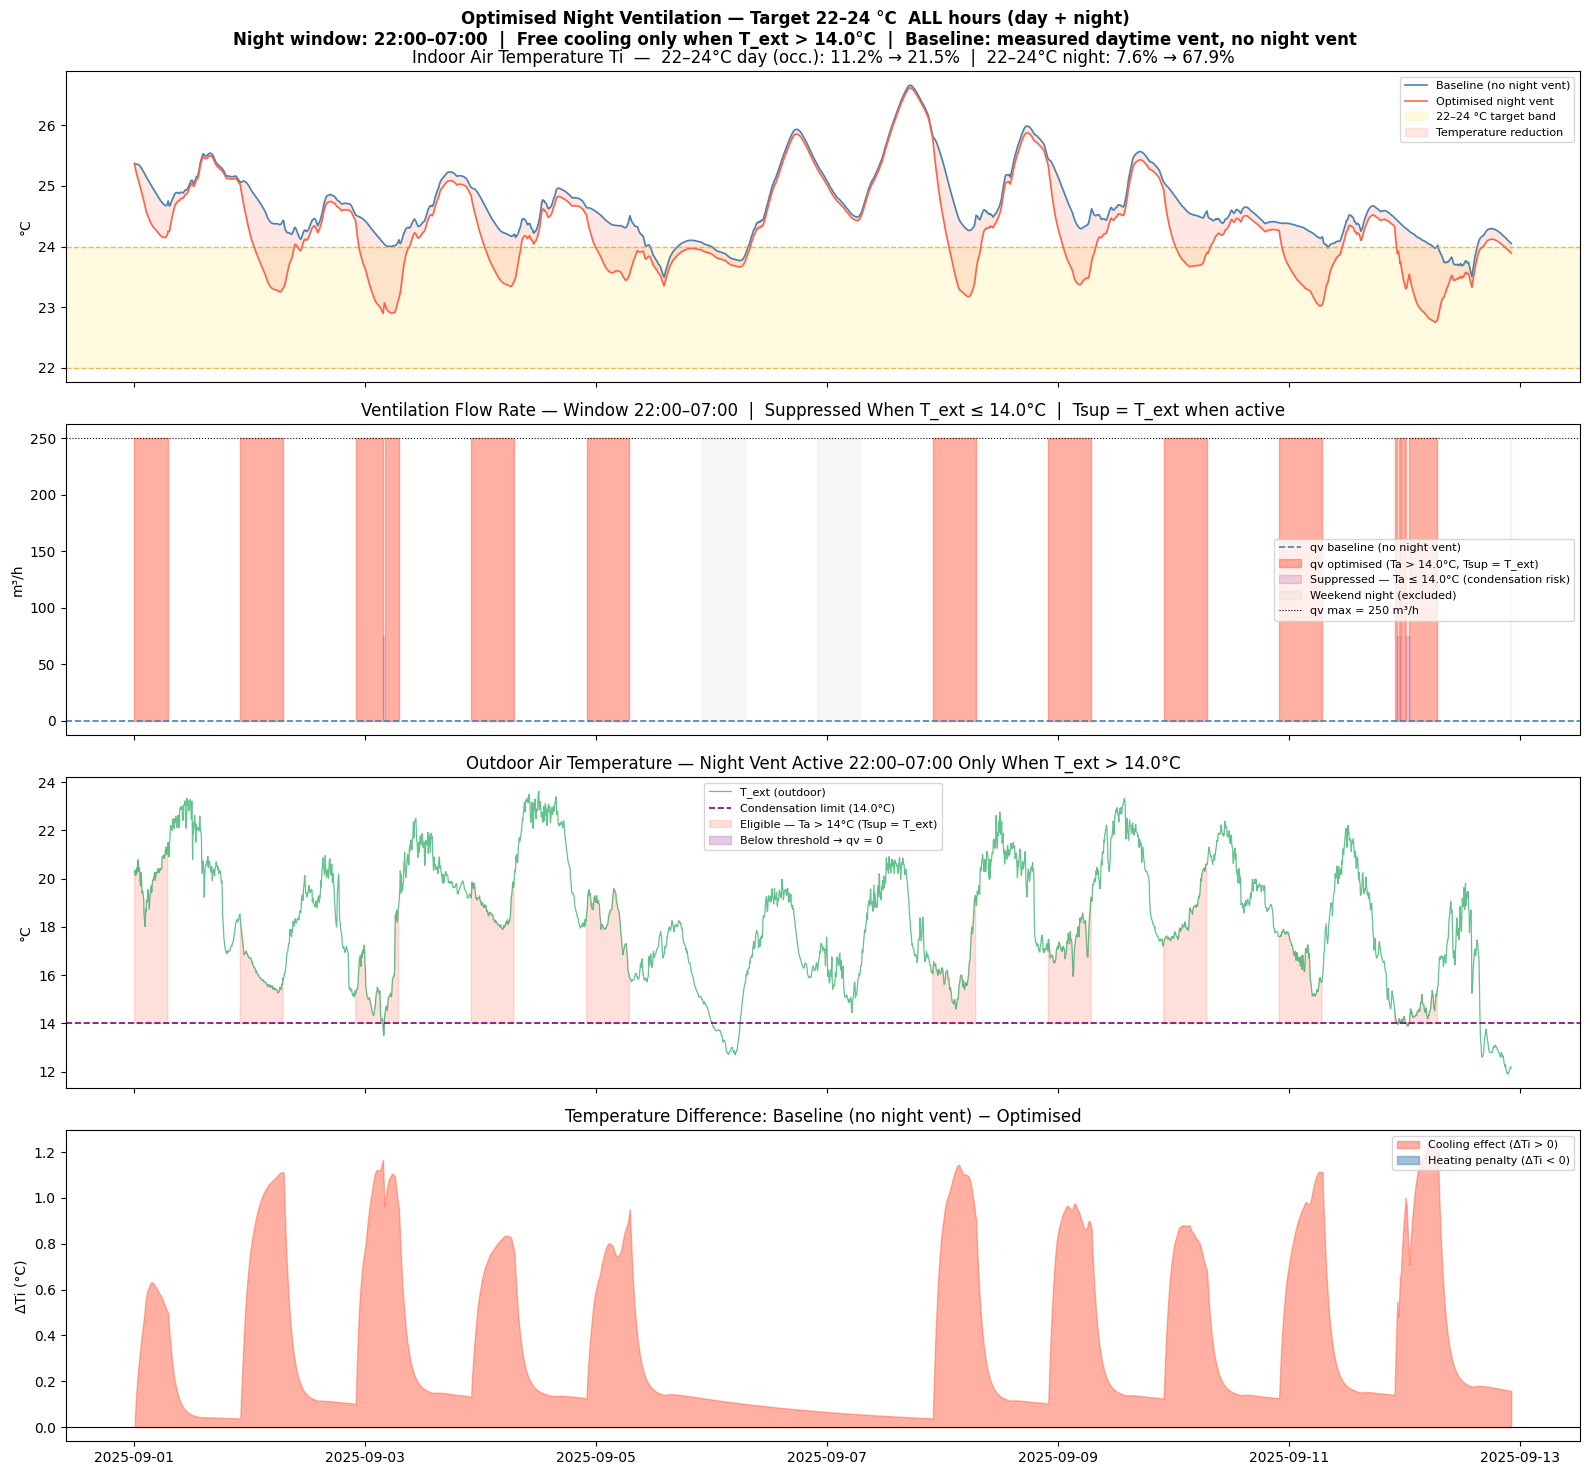

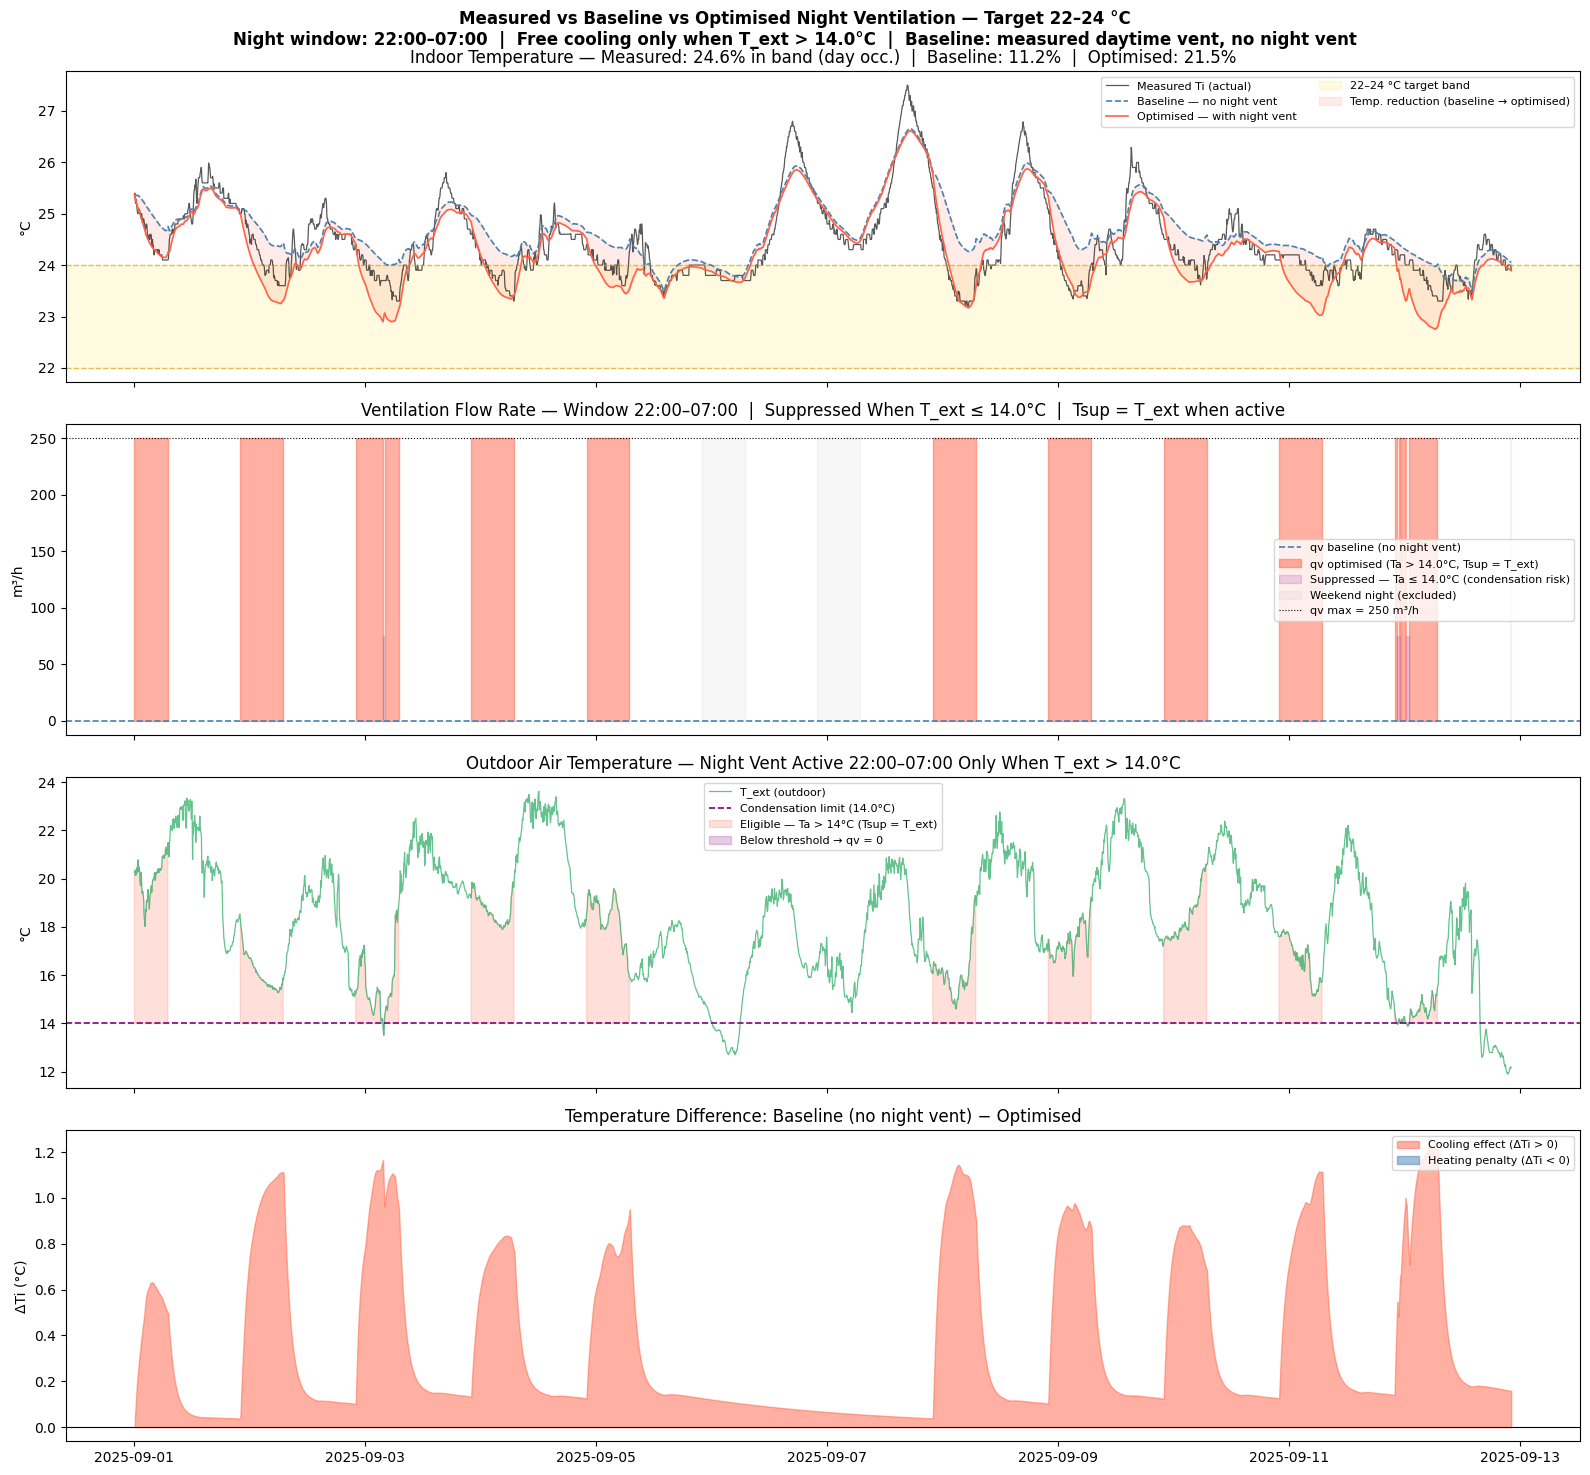

In [11]:
# ════════════════════════════════════════════════════════════════════════════
#  FAN ENERGY COST TABLE — Measured / Baseline / Optimised
# ════════════════════════════════════════════════════════════════════════════
cost_measured = fan_cost(qv_arr)   # original measured flow (all hours)

print(f"\n{'─'*55}")
print(f"  Fan electricity cost over full period")
print(f"{'─'*55}")
print(f"  {'Scenario':<28} {'Cost (DKK)':>10}  {'vs Measured':>12}")
print(f"{'─'*55}")
print(f"  {'Measured (actual)':<28} {cost_measured:>10.2f}  {'—':>12}")
print(f"  {'Baseline (no night vent)':<28} {cost_baseline:>10.2f}  "
      f"{cost_baseline - cost_measured:>+11.2f}")
print(f"  {'Optimised (night vent)':<28} {cost_optimised:>10.2f}  "
      f"{cost_optimised - cost_measured:>+11.2f}")
print(f"{'─'*55}")
print(f"  Optimised vs Baseline (extra night fan cost): "
      f"{cost_optimised - cost_baseline:+.2f} DKK")


# ════════════════════════════════════════════════════════════════════════════
#  FIGURE 1 — Operational overview (no measured Ti on panel 0)
# ════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(4, 1, figsize=(16, 15), sharex=True)
fig.suptitle(
    f'Optimised Night Ventilation — Target 22–24 °C  ALL hours (day + night)\n'
    f'Night window: {NIGHT_START:02d}:00–{NIGHT_STOP:02d}:00  |  '
    f'Free cooling only when T_ext > {TA_MIN_NIGHT_VENT}°C  |  '
    f'Baseline: measured daytime vent, no night vent',
    fontsize=12, fontweight='bold'
)

ax = axes[0]
ax.plot(index, baseline['Ti'],  color='steelblue', lw=1.2,
        label='Baseline (no night vent)', zorder=2)
ax.plot(index, optimised['Ti'], color='tomato',    lw=1.2,
        label='Optimised night vent', zorder=3)
ax.axhspan(T_cat1_min, T_cat1_max, alpha=0.12, color='gold',
           label='22–24 °C target band')
ax.axhline(T_cat1_max, color='goldenrod', lw=1.0, ls='--', alpha=0.7)
ax.axhline(T_cat1_min, color='goldenrod', lw=1.0, ls='--', alpha=0.7)
ax.fill_between(index,
    np.asarray(baseline['Ti']), np.asarray(optimised['Ti']),
    where=(np.asarray(baseline['Ti']) > np.asarray(optimised['Ti'])),
    alpha=0.15, color='tomato', label='Temperature reduction')
ax.set_ylabel('°C')
ax.legend(fontsize=8)
ax.set_title(
    f'Indoor Air Temperature Ti  —  '
    f'22–24°C day (occ.): {pct_occ_base:.1f}% → {pct_occ_opt:.1f}%  |  '
    f'22–24°C night: {pct_night_base:.1f}% → {pct_night_opt:.1f}%'
)

ax = axes[1]
ax.axhline(0, color='steelblue', lw=1.2, ls='--', label='qv baseline (no night vent)')
ax.fill_between(index, qv_opt_full, 0,
    where=weekday_night_mask & ta_ok_mask,
    alpha=0.5, color='tomato',
    label=f'qv optimised (Ta > {TA_MIN_NIGHT_VENT}°C, Tsup = T_ext)')
ax.fill_between(index, QV_MAX * 0.3, 0,
    where=weekday_night_mask & ~ta_ok_mask,
    alpha=0.15, color='purple',
    label=f'Suppressed — Ta ≤ {TA_MIN_NIGHT_VENT}°C (condensation risk)')
ax.fill_between(index, QV_MAX, 0,
    where=weekend_night_mask, alpha=0.06, color='grey',
    label='Weekend night (excluded)')
ax.axhline(QV_MAX, color='black', lw=0.8, ls=':', label=f'qv max = {QV_MAX:.0f} m³/h')
ax.set_ylabel('m³/h')
ax.legend(fontsize=8)
ax.set_title(
    f'Ventilation Flow Rate — Window {NIGHT_START:02d}:00–{NIGHT_STOP:02d}:00  |  '
    f'Suppressed When T_ext ≤ {TA_MIN_NIGHT_VENT}°C  |  Tsup = T_ext when active'
)

ax = axes[2]
ax.plot(index, Ta_arr, color='mediumseagreen', lw=0.9, alpha=0.8,
        label='T_ext (outdoor)')
ax.axhline(TA_MIN_NIGHT_VENT, color='purple', lw=1.2, ls='--',
           label=f'Condensation limit ({TA_MIN_NIGHT_VENT}°C)')
ax.fill_between(index, Ta_arr, TA_MIN_NIGHT_VENT,
    where=(Ta_arr > TA_MIN_NIGHT_VENT) & weekday_night_mask,
    alpha=0.2, color='tomato', label='Eligible — Ta > 14°C (Tsup = T_ext)')
ax.fill_between(index, Ta_arr, TA_MIN_NIGHT_VENT,
    where=(Ta_arr <= TA_MIN_NIGHT_VENT) & weekday_night_mask,
    alpha=0.2, color='purple', label='Below threshold → qv = 0')
ax.set_ylabel('°C')
ax.legend(fontsize=8)
ax.set_title(
    f'Outdoor Air Temperature — Night Vent Active {NIGHT_START:02d}:00–{NIGHT_STOP:02d}:00 '
    f'Only When T_ext > {TA_MIN_NIGHT_VENT}°C'
)

ax = axes[3]
delta = np.asarray(baseline['Ti']) - np.asarray(optimised['Ti'])
ax.fill_between(index, delta, 0,
    where=(delta > 0), color='tomato',    alpha=0.5, label='Cooling effect (ΔTi > 0)')
ax.fill_between(index, delta, 0,
    where=(delta < 0), color='steelblue', alpha=0.5, label='Heating penalty (ΔTi < 0)')
ax.axhline(0, color='black', lw=0.8)
ax.set_ylabel('ΔTi (°C)')
ax.legend(fontsize=8)
ax.set_title('Temperature Difference: Baseline (no night vent) − Optimised')

plt.tight_layout()
plt.savefig('night_vent_optimised_22_24.png', dpi=150, bbox_inches='tight')
plt.show()


# ════════════════════════════════════════════════════════════════════════════
#  FIGURE 2 — Three-way comparison: Measured + Baseline + Optimised
# ════════════════════════════════════════════════════════════════════════════
fig2, axes2 = plt.subplots(4, 1, figsize=(16, 15), sharex=True)
fig2.suptitle(
    f'Measured vs Baseline vs Optimised Night Ventilation — Target 22–24 °C\n'
    f'Night window: {NIGHT_START:02d}:00–{NIGHT_STOP:02d}:00  |  '
    f'Free cooling only when T_ext > {TA_MIN_NIGHT_VENT}°C  |  '
    f'Baseline: measured daytime vent, no night vent',
    fontsize=12, fontweight='bold'
)

ax = axes2[0]
ax.plot(index, y_train,         color='black',     lw=0.9, alpha=0.65,
        label='Measured Ti (actual)', zorder=2)
ax.plot(index, baseline['Ti'],  color='steelblue', lw=1.2, ls='--',
        label='Baseline — no night vent', zorder=3)
ax.plot(index, optimised['Ti'], color='tomato',    lw=1.2,
        label='Optimised — with night vent', zorder=4)
ax.axhspan(T_cat1_min, T_cat1_max, alpha=0.12, color='gold',
           label='22–24 °C target band')
ax.axhline(T_cat1_max, color='goldenrod', lw=1.0, ls='--', alpha=0.7)
ax.axhline(T_cat1_min, color='goldenrod', lw=1.0, ls='--', alpha=0.7)
ax.fill_between(index,
    np.asarray(baseline['Ti']), np.asarray(optimised['Ti']),
    where=(np.asarray(baseline['Ti']) > np.asarray(optimised['Ti'])),
    alpha=0.12, color='tomato', label='Temp. reduction (baseline → optimised)')
ax.set_ylabel('°C')
ax.legend(fontsize=8, ncol=2)
ax.set_title(
    f'Indoor Temperature — Measured: {pct_occ_meas:.1f}% in band (day occ.)  |  '
    f'Baseline: {pct_occ_base:.1f}%  |  Optimised: {pct_occ_opt:.1f}%'
)

ax = axes2[1]
ax.axhline(0, color='steelblue', lw=1.2, ls='--', label='qv baseline (no night vent)')
ax.fill_between(index, qv_opt_full, 0,
    where=weekday_night_mask & ta_ok_mask,
    alpha=0.5, color='tomato',
    label=f'qv optimised (Ta > {TA_MIN_NIGHT_VENT}°C, Tsup = T_ext)')
ax.fill_between(index, QV_MAX * 0.3, 0,
    where=weekday_night_mask & ~ta_ok_mask,
    alpha=0.15, color='purple',
    label=f'Suppressed — Ta ≤ {TA_MIN_NIGHT_VENT}°C (condensation risk)')
ax.fill_between(index, QV_MAX, 0,
    where=weekend_night_mask, alpha=0.06, color='grey',
    label='Weekend night (excluded)')
ax.axhline(QV_MAX, color='black', lw=0.8, ls=':', label=f'qv max = {QV_MAX:.0f} m³/h')
ax.set_ylabel('m³/h')
ax.legend(fontsize=8)
ax.set_title(
    f'Ventilation Flow Rate — Window {NIGHT_START:02d}:00–{NIGHT_STOP:02d}:00  |  '
    f'Suppressed When T_ext ≤ {TA_MIN_NIGHT_VENT}°C  |  Tsup = T_ext when active'
)

ax = axes2[2]
ax.plot(index, Ta_arr, color='mediumseagreen', lw=0.9, alpha=0.8,
        label='T_ext (outdoor)')
ax.axhline(TA_MIN_NIGHT_VENT, color='purple', lw=1.2, ls='--',
           label=f'Condensation limit ({TA_MIN_NIGHT_VENT}°C)')
ax.fill_between(index, Ta_arr, TA_MIN_NIGHT_VENT,
    where=(Ta_arr > TA_MIN_NIGHT_VENT) & weekday_night_mask,
    alpha=0.2, color='tomato', label='Eligible — Ta > 14°C (Tsup = T_ext)')
ax.fill_between(index, Ta_arr, TA_MIN_NIGHT_VENT,
    where=(Ta_arr <= TA_MIN_NIGHT_VENT) & weekday_night_mask,
    alpha=0.2, color='purple', label='Below threshold → qv = 0')
ax.set_ylabel('°C')
ax.legend(fontsize=8)
ax.set_title(
    f'Outdoor Air Temperature — Night Vent Active {NIGHT_START:02d}:00–{NIGHT_STOP:02d}:00 '
    f'Only When T_ext > {TA_MIN_NIGHT_VENT}°C'
)

ax = axes2[3]
delta = np.asarray(baseline['Ti']) - np.asarray(optimised['Ti'])
ax.fill_between(index, delta, 0,
    where=(delta > 0), color='tomato',    alpha=0.5, label='Cooling effect (ΔTi > 0)')
ax.fill_between(index, delta, 0,
    where=(delta < 0), color='steelblue', alpha=0.5, label='Heating penalty (ΔTi < 0)')
ax.axhline(0, color='black', lw=0.8)
ax.set_ylabel('ΔTi (°C)')
ax.legend(fontsize=8)
ax.set_title('Temperature Difference: Baseline (no night vent) − Optimised')

plt.tight_layout()
plt.savefig('three_way_comparison.png', dpi=150, bbox_inches='tight')
plt.show()



──────────────────────────────────────────────────────────────
  Fan electricity cost — all scenarios vs base simulation
──────────────────────────────────────────────────────────────
  Scenario                             Cost (DKK)   vs Base sim
──────────────────────────────────────────────────────────────
  Base simulation (original qv+Tsup)        21.52             —
  Base sim qv + T_ext Tsup at night         21.51        -0.01
  Baseline (no night vent)                  12.78        -8.74
  Optimised (night vent)                    26.25        +4.74
──────────────────────────────────────────────────────────────


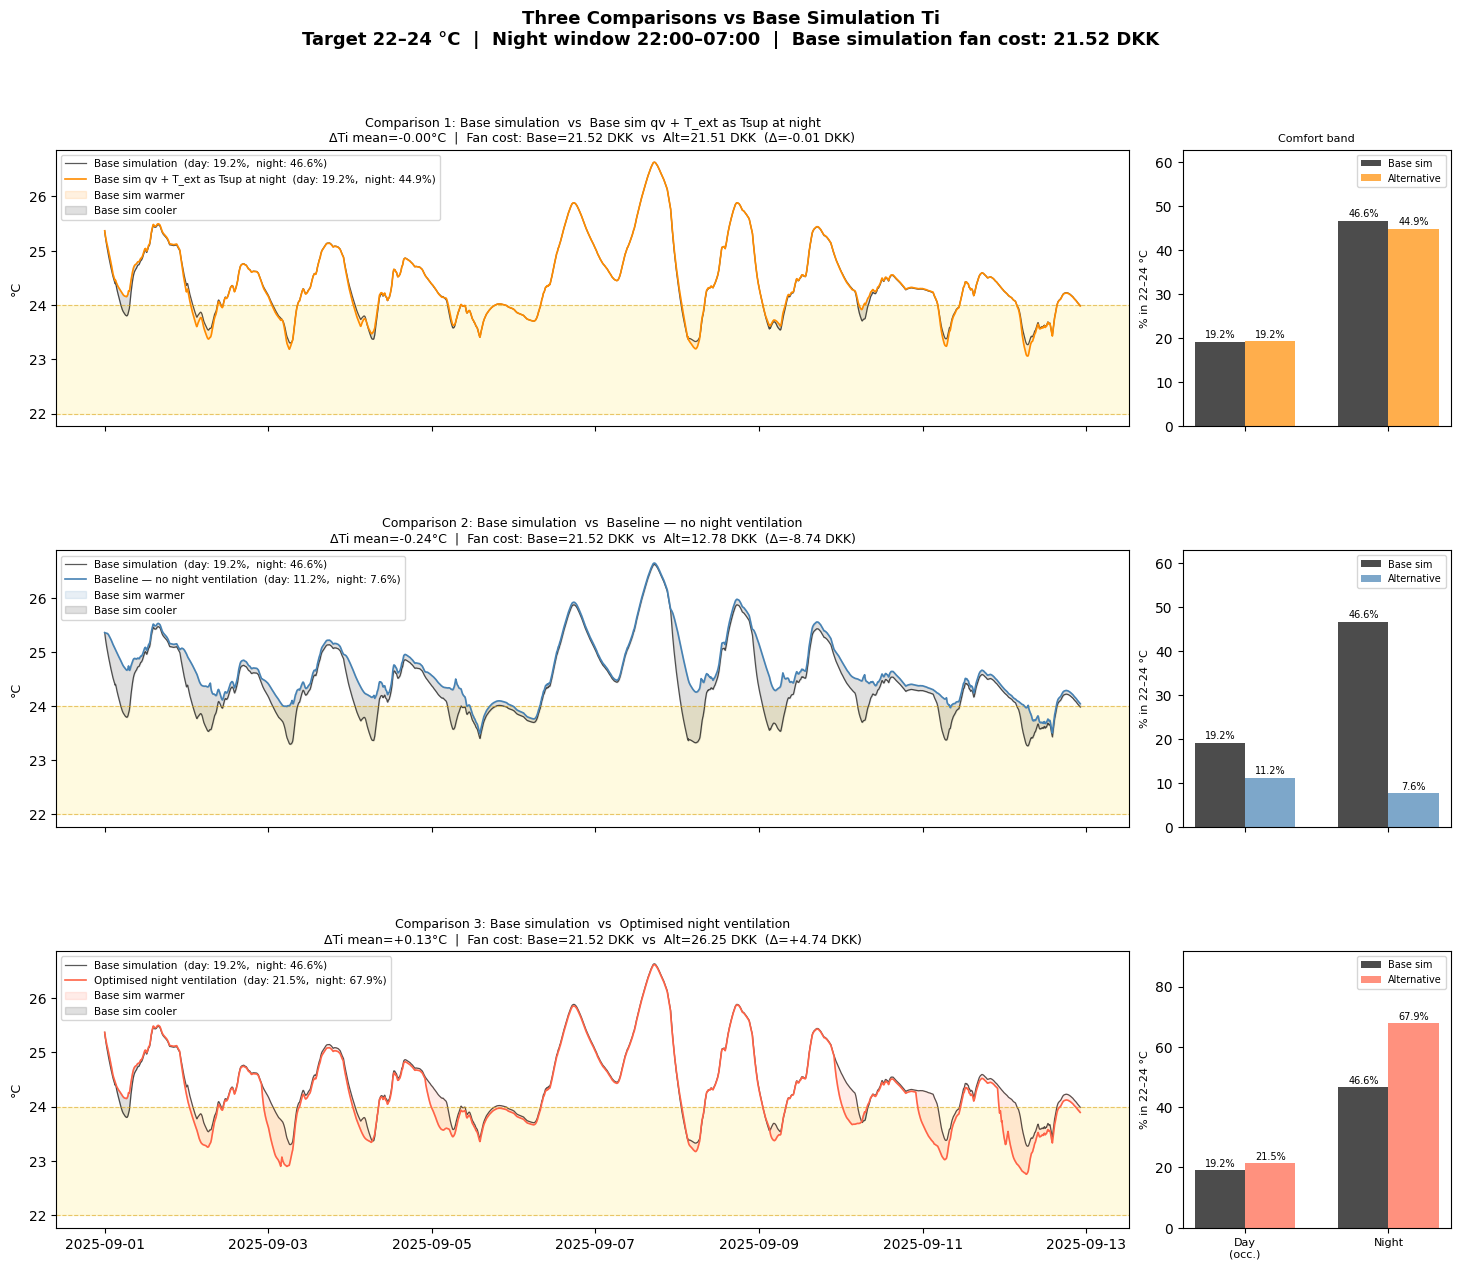

In [12]:
# ════════════════════════════════════════════════════════════════════════════
#  BASE SIMULATION — model run with original measured qv + Tsup, unchanged
# ════════════════════════════════════════════════════════════════════════════
base_sim = simulate_night_vent_scenario(
    fitted_params, X_train, N_hist,
    night_start_hour=0, night_stop_hour=0,
    qv_night=0,
    rec_duration=rec_duration,
    Ti_init=Ti_init, Tm_init=Tm_init, c_init=c_init
)

Ti_ref        = np.asarray(base_sim['Ti'])
cost_ref      = fan_cost(qv_arr)
pct_occ_ref   = pct_in_band(base_sim['Ti'], T_cat1_min, T_cat1_max, occ_mask)
pct_night_ref = pct_in_band(base_sim['Ti'], T_cat1_min, T_cat1_max, all_night_mask)


# ════════════════════════════════════════════════════════════════════════════
#  NEW SCENARIO: Base simulation qv + T_ext as Tsup at night
#  Same flow as base simulation, but Tsup replaced with T_ext at night
# ════════════════════════════════════════════════════════════════════════════
qv_meas_text   = qv_arr.copy()
Tsup_meas_text = Tsup_arr.copy()

for step_idx in night_step_indices:
    if ta_ok_mask[step_idx]:
        Tsup_meas_text[step_idx] = Ta_arr[step_idx]   # ← Tsup = T_ext, qv unchanged
    else:
        qv_meas_text[step_idx]   = 0.0                # condensation guard

X_meas_text         = X_train.copy()
X_meas_text['qv']   = qv_meas_text
X_meas_text['Tsup'] = Tsup_meas_text

meas_text = simulate_night_vent_scenario(
    fitted_params, X_meas_text, N_hist,
    night_start_hour=0, night_stop_hour=0,
    qv_night=0,
    rec_duration=rec_duration,
    Ti_init=Ti_init, Tm_init=Tm_init, c_init=c_init
)

pct_occ_meas_text   = pct_in_band(meas_text['Ti'], T_cat1_min, T_cat1_max, occ_mask)
pct_night_meas_text = pct_in_band(meas_text['Ti'], T_cat1_min, T_cat1_max, all_night_mask)
cost_meas_text      = fan_cost(qv_meas_text)


# ════════════════════════════════════════════════════════════════════════════
#  COST TABLE — all scenarios vs base simulation
# ════════════════════════════════════════════════════════════════════════════
print(f"\n{'─'*62}")
print(f"  Fan electricity cost — all scenarios vs base simulation")
print(f"{'─'*62}")
print(f"  {'Scenario':<36} {'Cost (DKK)':>10}  {'vs Base sim':>12}")
print(f"{'─'*62}")
print(f"  {'Base simulation (original qv+Tsup)':<36} {cost_ref:>10.2f}  {'—':>12}")
print(f"  {'Base sim qv + T_ext Tsup at night':<36} {cost_meas_text:>10.2f}  {cost_meas_text - cost_ref:>+11.2f}")
print(f"  {'Baseline (no night vent)':<36} {cost_baseline:>10.2f}  {cost_baseline - cost_ref:>+11.2f}")
print(f"  {'Optimised (night vent)':<36} {cost_optimised:>10.2f}  {cost_optimised - cost_ref:>+11.2f}")
print(f"{'─'*62}")


# ════════════════════════════════════════════════════════════════════════════
#  FIGURE — Three comparisons vs Base Simulation
# ════════════════════════════════════════════════════════════════════════════
comparisons = [
    {
        'label'     : 'Base sim qv + T_ext as Tsup at night',
        'Ti_alt'    : np.asarray(meas_text['Ti']),
        'color'     : 'darkorange',
        'pct_occ'   : pct_occ_meas_text,
        'pct_night' : pct_night_meas_text,
        'cost'      : cost_meas_text,
    },
    {
        'label'     : 'Baseline — no night ventilation',
        'Ti_alt'    : np.asarray(baseline['Ti']),
        'color'     : 'steelblue',
        'pct_occ'   : pct_occ_base,
        'pct_night' : pct_night_base,
        'cost'      : cost_baseline,
    },
    {
        'label'     : 'Optimised night ventilation',
        'Ti_alt'    : np.asarray(optimised['Ti']),
        'color'     : 'tomato',
        'pct_occ'   : pct_occ_opt,
        'pct_night' : pct_night_opt,
        'cost'      : cost_optimised,
    },
]

fig3, axes3 = plt.subplots(
    3, 2, figsize=(18, 14), sharex='col',
    gridspec_kw={'width_ratios': [4, 1], 'hspace': 0.45, 'wspace': 0.08}
)
fig3.suptitle(
    'Three Comparisons vs Base Simulation Ti\n'
    f'Target 22–24 °C  |  Night window {NIGHT_START:02d}:00–{NIGHT_STOP:02d}:00  |  '
    f'Base simulation fan cost: {cost_ref:.2f} DKK',
    fontsize=13, fontweight='bold'
)

for row, cmp in enumerate(comparisons):
    ax_ts  = axes3[row, 0]
    ax_bar = axes3[row, 1]

    # ── Time series ───────────────────────────────────────────────────────────
    ax_ts.plot(index, Ti_ref,        color='black',      lw=0.9, alpha=0.65,
               label=f'Base simulation  (day: {pct_occ_ref:.1f}%,  night: {pct_night_ref:.1f}%)',
               zorder=2)
    ax_ts.plot(index, cmp['Ti_alt'], color=cmp['color'], lw=1.2,
               label=f"{cmp['label']}  (day: {cmp['pct_occ']:.1f}%,  night: {cmp['pct_night']:.1f}%)",
               zorder=3)
    ax_ts.axhspan(T_cat1_min, T_cat1_max, alpha=0.12, color='gold')
    ax_ts.axhline(T_cat1_max, color='goldenrod', lw=0.8, ls='--', alpha=0.6)
    ax_ts.axhline(T_cat1_min, color='goldenrod', lw=0.8, ls='--', alpha=0.6)

    delta = Ti_ref - cmp['Ti_alt']
    ax_ts.fill_between(index, Ti_ref, cmp['Ti_alt'],
        where=(Ti_ref > cmp['Ti_alt']),
        alpha=0.12, color=cmp['color'], label='Base sim warmer')
    ax_ts.fill_between(index, Ti_ref, cmp['Ti_alt'],
        where=(Ti_ref < cmp['Ti_alt']),
        alpha=0.12, color='black', label='Base sim cooler')

    ax_ts.set_ylabel('°C', fontsize=9)
    ax_ts.legend(fontsize=7.5, loc='upper left')
    ax_ts.set_title(
        f'Comparison {row+1}: Base simulation  vs  {cmp["label"]}\n'
        f'ΔTi mean={delta.mean():+.2f}°C  |  '
        f'Fan cost: Base={cost_ref:.2f} DKK  vs  Alt={cmp["cost"]:.2f} DKK  '
        f'(Δ={cmp["cost"] - cost_ref:+.2f} DKK)',
        fontsize=9
    )

    # ── Bar chart ─────────────────────────────────────────────────────────────
    x, w = np.arange(2), 0.35
    b1 = ax_bar.bar(x - w/2, [pct_occ_ref,    pct_night_ref],    w,
                    color='black',      alpha=0.7, label='Base sim')
    b2 = ax_bar.bar(x + w/2, [cmp['pct_occ'], cmp['pct_night']], w,
                    color=cmp['color'], alpha=0.7, label='Alternative')
    for b in list(b1) + list(b2):
        ax_bar.text(b.get_x() + b.get_width()/2, b.get_height() + 0.5,
                    f'{b.get_height():.1f}%', ha='center', va='bottom', fontsize=7)

    ax_bar.set_xticks(x)
    ax_bar.set_xticklabels(['Day\n(occ.)', 'Night'], fontsize=8)
    ax_bar.set_ylim(0, min(100, max(pct_occ_ref, pct_night_ref,
                                    cmp['pct_occ'], cmp['pct_night']) * 1.35))
    ax_bar.set_ylabel('% in 22–24 °C', fontsize=8)
    ax_bar.legend(fontsize=7, loc='upper right')
    if row == 0:
        ax_bar.set_title('Comfort band', fontsize=8)

plt.savefig('three_comparisons_vs_basesim.png', dpi=150, bbox_inches='tight')
plt.show()


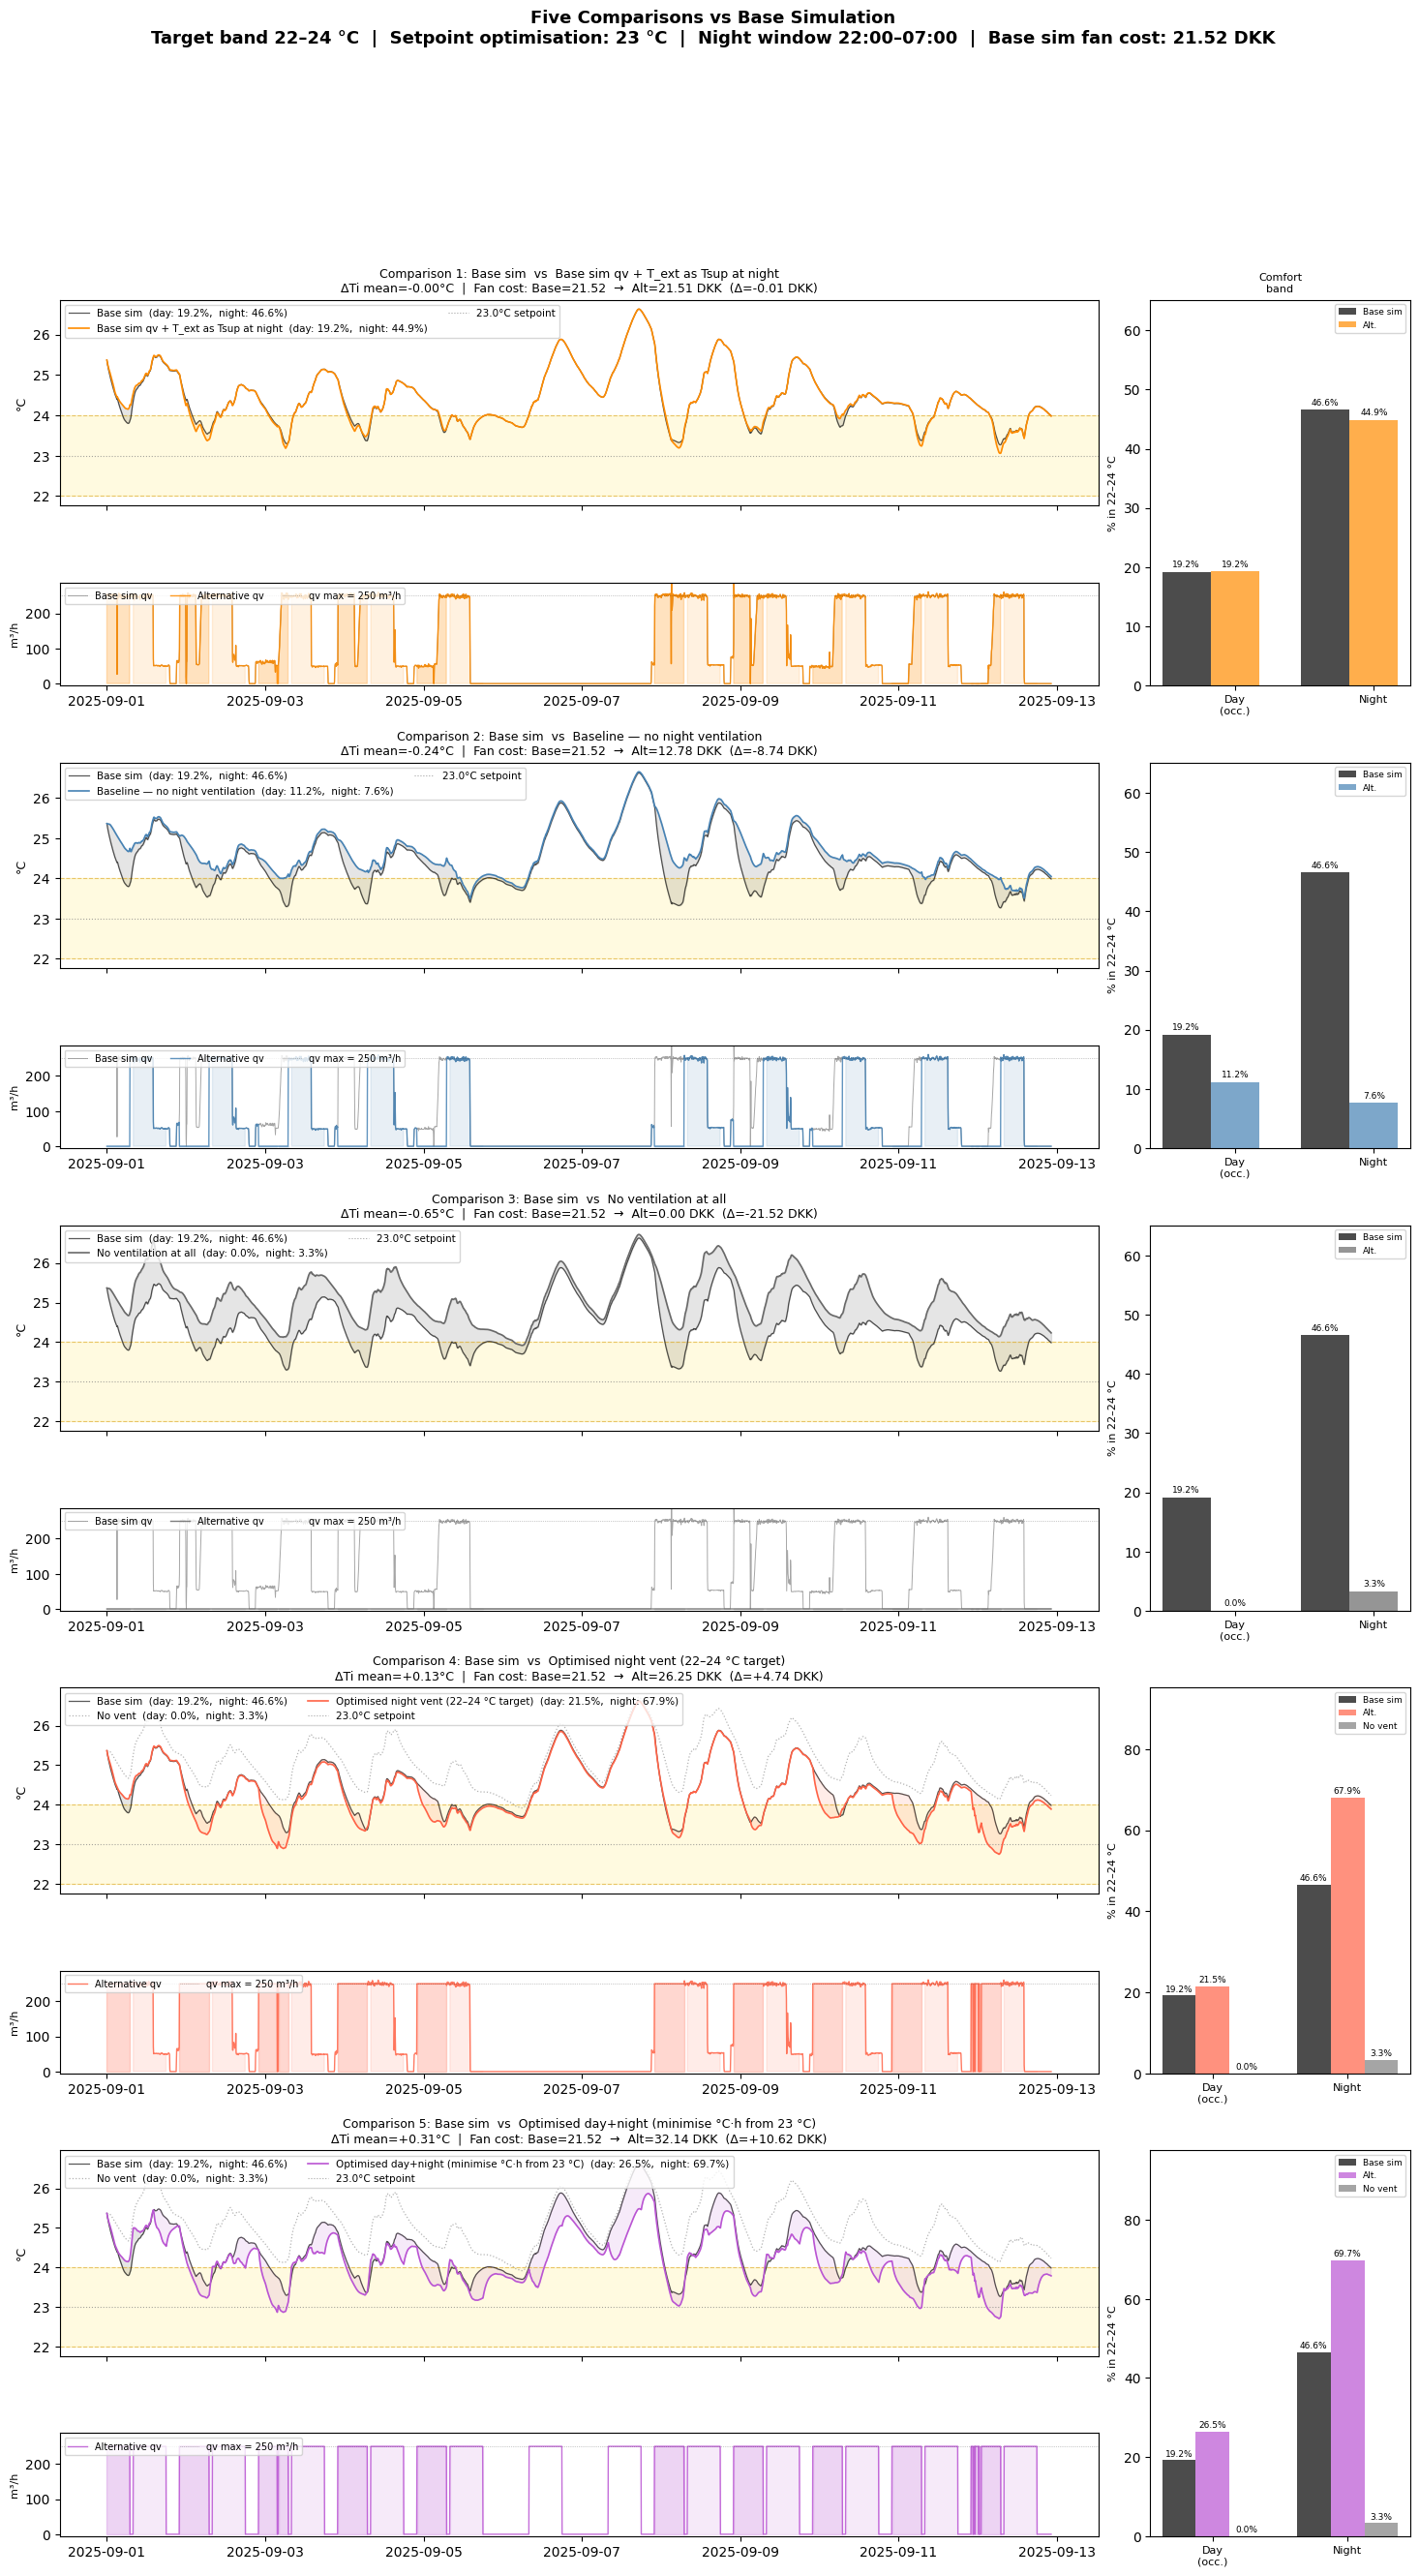


════════════════════════════════════════════════════════════
  Fan electricity cost — all scenarios
════════════════════════════════════════════════════════════
  Scenario                                        DKK   vs Base
────────────────────────────────────────────────────────────
  Base simulation                               21.52         —
  Base sim + T_ext Tsup at night                21.51     -0.01
  Baseline — no night vent                      12.78     -8.74
  No ventilation at all                          0.00    -21.52
  Optimised night vent (22–24°C)                26.25     +4.74
  Optimised day+night (23°C target)             32.14    +10.62
════════════════════════════════════════════════════════════


C:\Users\clemr\AppData\Local\Temp\ipykernel_23804\2866460339.py:202: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax_cost.set_xticklabels(names, rotation=15, ha='right', fontsize=8.5)


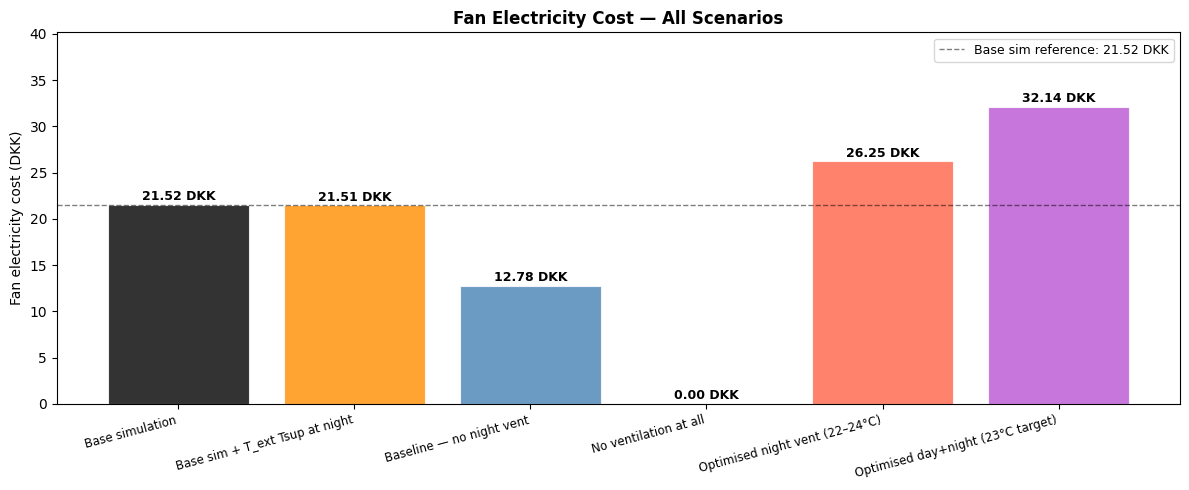


Multi-objective weights: W_TEMP=1.0, W_COST=100.0
  → 1 DKK fan saving ≡ 100 °C²·h thermal cost
Running multi-objective optimisation (temperature + cost)...

Optimisation converged : True
Final combined cost    : 1343.5358
Day qv   : [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.] m³/h
Night qv : [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.] m³/h

────────────────────────────────────────────────────────────────────
  Multi-objective results
────────────────────────────────────────────────────────────────────
  Metric                                     Base sim    Multi-obj
────────────────────────────────────────────────────────────────────
  °C·h above 23°C (all)                        409.09       594.36
  °C·h below 23°C (all)                          0.00         0.00
  °C·h above 23°C (day occ.)                   189.46       289.02
  % time 22–24°C (day occ.)                     19.2%         0.0%
  % time 22–24°C (night)                        46.6%         3.3%
  Fan cost (DKK)                   

C:\Users\clemr\AppData\Local\Temp\ipykernel_23804\2866460339.py:338: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax_c.set_xticklabels(names2, rotation=15, ha='right', fontsize=8.5)


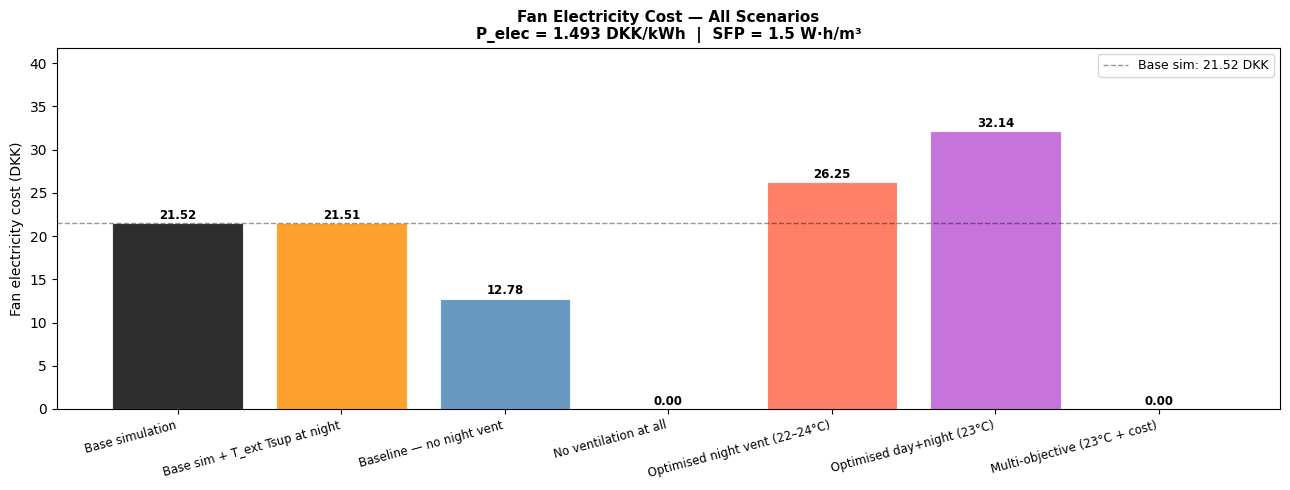

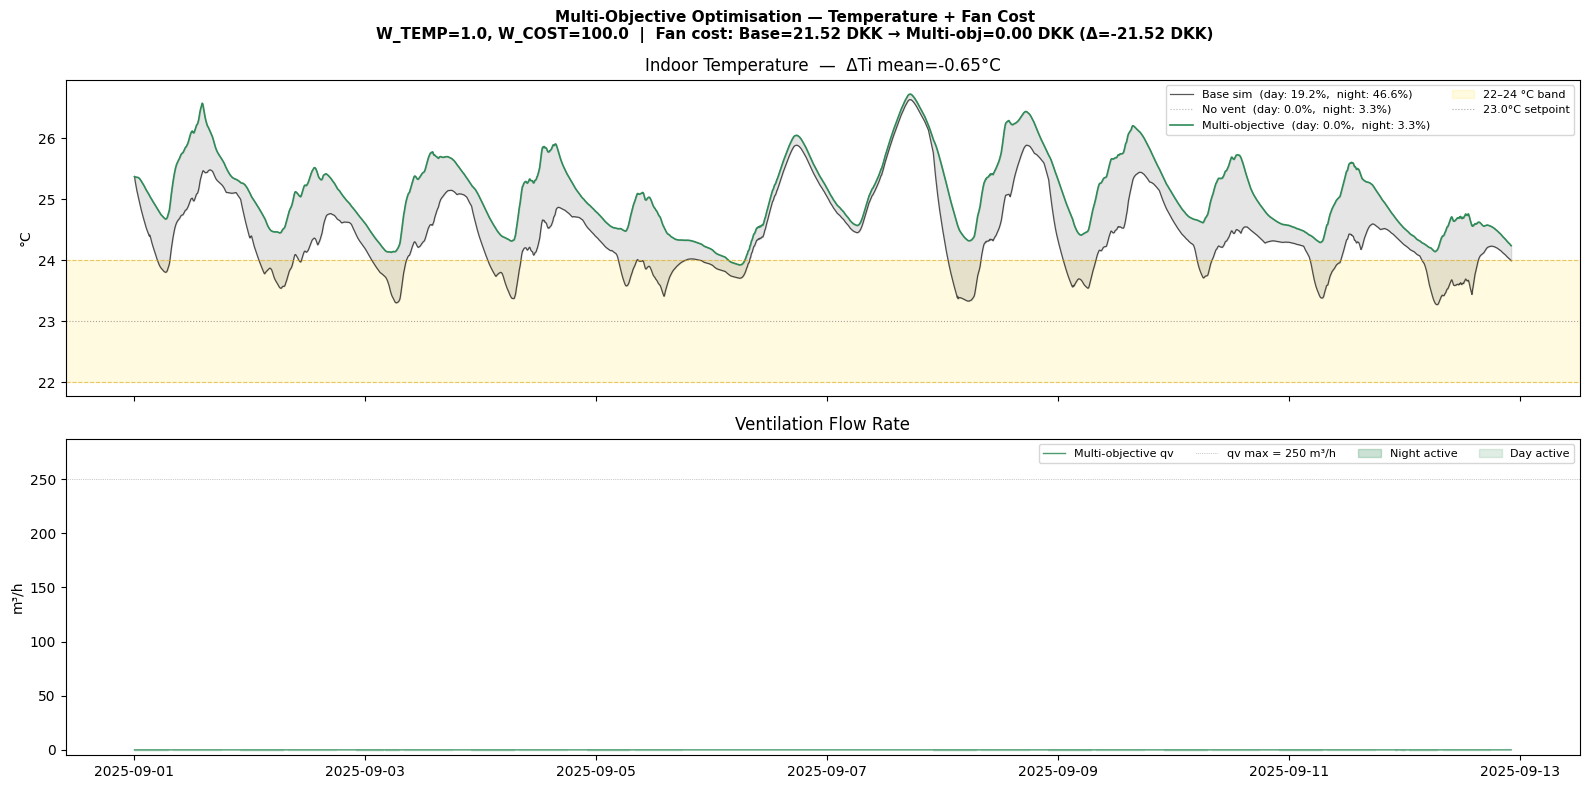

In [13]:
# ════════════════════════════════════════════════════════════════════════════
#  FIGURE — 5 comparisons vs Base Simulation  (updated)
# ════════════════════════════════════════════════════════════════════════════
import matplotlib.gridspec as gridspec

comparisons_5 = [
    {
        'label'        : 'Base sim qv + T_ext as Tsup at night',
        'Ti_alt'       : np.asarray(meas_text['Ti']),
        'qv_alt'       : qv_meas_text,
        'color'        : 'darkorange',
        'pct_occ'      : pct_occ_meas_text,
        'pct_night'    : pct_night_meas_text,
        'cost'         : cost_meas_text,
        'show_novent'  : False,
        'hide_basesim_qv': False,
    },
    {
        'label'        : 'Baseline — no night ventilation',
        'Ti_alt'       : np.asarray(baseline['Ti']),
        'qv_alt'       : qv_baseline,
        'color'        : 'steelblue',
        'pct_occ'      : pct_occ_base,
        'pct_night'    : pct_night_base,
        'cost'         : cost_baseline,
        'show_novent'  : False,
        'hide_basesim_qv': False,
    },
    {
        'label'        : 'No ventilation at all',
        'Ti_alt'       : Ti_novent,
        'qv_alt'       : np.zeros(len(qv_arr)),
        'color'        : 'dimgray',
        'pct_occ'      : pct_occ_novent,
        'pct_night'    : pct_night_novent,
        'cost'         : cost_novent,
        'show_novent'  : False,
        'hide_basesim_qv': False,
    },
    {
        'label'        : 'Optimised night vent (22–24 °C target)',
        'Ti_alt'       : np.asarray(optimised['Ti']),
        'qv_alt'       : qv_opt_full,
        'color'        : 'tomato',
        'pct_occ'      : pct_occ_opt,
        'pct_night'    : pct_night_opt,
        'cost'         : cost_optimised,
        'show_novent'  : True,
        'hide_basesim_qv': True,    # ← no base sim qv line
    },
    {
        'label'        : 'Optimised day+night (minimise °C·h from 23 °C)',
        'Ti_alt'       : Ti_fullday,
        'qv_alt'       : qv_fullday_full,
        'color'        : 'mediumorchid',
        'pct_occ'      : pct_occ_fullday,
        'pct_night'    : pct_night_fullday,
        'cost'         : cost_fullday,
        'show_novent'  : True,
        'hide_basesim_qv': True,    # ← no base sim qv line
    },
]

n_cmp = len(comparisons_5)
fig5  = plt.figure(figsize=(18, 30))
gs    = gridspec.GridSpec(
    n_cmp * 2, 2, figure=fig5,
    width_ratios=[4, 1],
    height_ratios=[2, 1] * n_cmp,
    hspace=0.5, wspace=0.08
)
fig5.suptitle(
    'Five Comparisons vs Base Simulation\n'
    f'Target band 22–24 °C  |  Setpoint optimisation: 23 °C  |  '
    f'Night window {NIGHT_START:02d}:00–{NIGHT_STOP:02d}:00  |  '
    f'Base sim fan cost: {cost_ref:.2f} DKK',
    fontsize=13, fontweight='bold'
)

for row, cmp in enumerate(comparisons_5):
    r_temp = 2 * row
    r_qv   = 2 * row + 1

    ax_ts  = fig5.add_subplot(gs[r_temp, 0])
    ax_qv  = fig5.add_subplot(gs[r_qv,   0], sharex=ax_ts)
    ax_bar = fig5.add_subplot(gs[r_temp:r_temp + 2, 1])

    # ── Temperature panel ─────────────────────────────────────────────────────
    ax_ts.plot(index, Ti_ref, color='black', lw=0.9, alpha=0.65,
               label=f'Base sim  (day: {pct_occ_ref:.1f}%,  night: {pct_night_ref:.1f}%)',
               zorder=3)
    if cmp['show_novent']:
        ax_ts.plot(index, Ti_novent, color='dimgray', lw=0.9, alpha=0.5, ls=':',
                   label=f'No vent  (day: {pct_occ_novent:.1f}%,  night: {pct_night_novent:.1f}%)',
                   zorder=2)
    ax_ts.plot(index, cmp['Ti_alt'], color=cmp['color'], lw=1.2,
               label=f"{cmp['label']}  (day: {cmp['pct_occ']:.1f}%,  night: {cmp['pct_night']:.1f}%)",
               zorder=4)
    ax_ts.axhspan(T_cat1_min, T_cat1_max, alpha=0.12, color='gold')
    ax_ts.axhline(T_cat1_max, color='goldenrod', lw=0.8, ls='--', alpha=0.6)
    ax_ts.axhline(T_cat1_min, color='goldenrod', lw=0.8, ls='--', alpha=0.6)
    ax_ts.axhline(T_TARGET,   color='grey',      lw=0.8, ls=':',  alpha=0.7,
                  label=f'{T_TARGET}°C setpoint')
    delta = Ti_ref - cmp['Ti_alt']
    ax_ts.fill_between(index, Ti_ref, cmp['Ti_alt'],
        where=(Ti_ref > cmp['Ti_alt']), alpha=0.12, color=cmp['color'])
    ax_ts.fill_between(index, Ti_ref, cmp['Ti_alt'],
        where=(Ti_ref < cmp['Ti_alt']), alpha=0.10, color='black')
    ax_ts.set_ylabel('°C', fontsize=9)
    ax_ts.legend(fontsize=7.5, loc='upper left', ncol=2)
    ax_ts.set_title(
        f'Comparison {row+1}: Base sim  vs  {cmp["label"]}\n'
        f'ΔTi mean={delta.mean():+.2f}°C  |  '
        f'Fan cost: Base={cost_ref:.2f}  →  Alt={cmp["cost"]:.2f} DKK  '
        f'(Δ={cmp["cost"] - cost_ref:+.2f} DKK)',
        fontsize=9
    )
    plt.setp(ax_ts.get_xticklabels(), visible=False)

    # ── qv panel ──────────────────────────────────────────────────────────────
    if not cmp['hide_basesim_qv']:
        ax_qv.plot(index, qv_arr, color='black', lw=0.7, alpha=0.35,
                   label='Base sim qv')
    ax_qv.plot(index, cmp['qv_alt'], color=cmp['color'], lw=1.0, alpha=0.85,
               label='Alternative qv')
    ax_qv.axhline(QV_MAX, color='black', lw=0.5, ls=':', alpha=0.4,
                  label=f'qv max = {QV_MAX:.0f} m³/h')
    ax_qv.fill_between(index, cmp['qv_alt'], 0,
        where=weekday_night_mask & ta_ok_mask, alpha=0.25, color=cmp['color'])
    ax_qv.fill_between(index, cmp['qv_alt'], 0,
        where=weekday_day_mask, alpha=0.12, color=cmp['color'])
    ax_qv.set_ylabel('m³/h', fontsize=8)
    ax_qv.set_ylim(-5, QV_MAX * 1.15)
    ax_qv.legend(fontsize=7, loc='upper left', ncol=3)

    # ── Bar chart ─────────────────────────────────────────────────────────────
    pct_vals = [pct_occ_ref, pct_night_ref, cmp['pct_occ'], cmp['pct_night']]
    if cmp['show_novent']:
        pct_vals += [pct_occ_novent, pct_night_novent]

    x, w = np.arange(2), 0.25 if cmp['show_novent'] else 0.35
    b_ref = ax_bar.bar(x - w, [pct_occ_ref,    pct_night_ref],    w,
                       color='black', alpha=0.7, label='Base sim')
    b_alt = ax_bar.bar(x,     [cmp['pct_occ'], cmp['pct_night']], w,
                       color=cmp['color'], alpha=0.7, label='Alt.')
    if cmp['show_novent']:
        b_nv = ax_bar.bar(x + w, [pct_occ_novent, pct_night_novent], w,
                          color='dimgray', alpha=0.6, label='No vent')
        for b in list(b_nv):
            ax_bar.text(b.get_x() + b.get_width()/2, b.get_height() + 0.5,
                        f'{b.get_height():.1f}%', ha='center', va='bottom', fontsize=6.5)
    for b in list(b_ref) + list(b_alt):
        ax_bar.text(b.get_x() + b.get_width()/2, b.get_height() + 0.5,
                    f'{b.get_height():.1f}%', ha='center', va='bottom', fontsize=6.5)
    ax_bar.set_xticks(x)
    ax_bar.set_xticklabels(['Day\n(occ.)', 'Night'], fontsize=8)
    ax_bar.set_ylim(0, min(100, max(pct_vals) * 1.4))
    ax_bar.set_ylabel('% in 22–24 °C', fontsize=8)
    ax_bar.legend(fontsize=6.5)
    if row == 0:
        ax_bar.set_title('Comfort\nband', fontsize=8)

plt.savefig('five_comparisons_vs_basesim.png', dpi=150, bbox_inches='tight')
plt.show()


# ════════════════════════════════════════════════════════════════════════════
#  COST COMPARISON TABLE + CHART
# ════════════════════════════════════════════════════════════════════════════
cost_scenarios = [
    ('Base simulation',                         cost_ref),
    ('Base sim + T_ext Tsup at night',          cost_meas_text),
    ('Baseline — no night vent',                cost_baseline),
    ('No ventilation at all',                   cost_novent),
    ('Optimised night vent (22–24°C)',           cost_optimised),
    ('Optimised day+night (23°C target)',        cost_fullday),
]

print(f"\n{'═'*60}")
print(f"  Fan electricity cost — all scenarios")
print(f"{'═'*60}")
print(f"  {'Scenario':<42} {'DKK':>8}  {'vs Base':>8}")
print(f"{'─'*60}")
for name, cost in cost_scenarios:
    delta_str = f'{cost - cost_ref:+.2f}' if name != 'Base simulation' else '—'
    print(f"  {name:<42} {cost:>8.2f}  {delta_str:>8}")
print(f"{'═'*60}")

# Cost bar chart
fig_cost, ax_cost = plt.subplots(figsize=(12, 5))
names  = [c[0] for c in cost_scenarios]
costs  = [c[1] for c in cost_scenarios]
colors = ['black', 'darkorange', 'steelblue', 'dimgray', 'tomato', 'mediumorchid']
bars   = ax_cost.bar(names, costs, color=colors, alpha=0.8, edgecolor='white', linewidth=0.8)
for bar, cost in zip(bars, costs):
    ax_cost.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.15,
                 f'{cost:.2f} DKK', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax_cost.axhline(cost_ref, color='black', lw=1.0, ls='--', alpha=0.5,
                label=f'Base sim reference: {cost_ref:.2f} DKK')
ax_cost.set_ylabel('Fan electricity cost (DKK)', fontsize=10)
ax_cost.set_title('Fan Electricity Cost — All Scenarios', fontsize=12, fontweight='bold')
ax_cost.set_xticklabels(names, rotation=15, ha='right', fontsize=8.5)
ax_cost.set_ylim(0, max(costs) * 1.25)
ax_cost.legend(fontsize=9)
plt.tight_layout()
plt.savefig('cost_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


# ════════════════════════════════════════════════════════════════════════════
#  NEW SCENARIO: Multi-objective optimisation — temperature + cost
#  Objective: W_TEMP * Σ(Ti-23)²·dt  +  W_COST * fan_cost
#  Controls day (08–18) + night (20–08), same Tsup logic as opt-fullday
#  W_COST tuned so fan cost contribution is same order of magnitude as Ti cost
# ════════════════════════════════════════════════════════════════════════════
# Scale factor: bring cost (DKK, ~10–30) to same order as Ti²·h (~1000–3000)
# → W_COST_SCALE = Ti_cost_typical / cost_typical ≈ 2000/20 = 100
W_TEMP_MO      = 1.0
W_COST_MO      = 100.0   # penalises each DKK of fan energy equally to 100 °C²·h
                          # ↑ increase to force more cost saving, decrease for more comfort

print(f"\nMulti-objective weights: W_TEMP={W_TEMP_MO}, W_COST={W_COST_MO}")
print(f"  → 1 DKK fan saving ≡ {W_COST_MO:.0f} °C²·h thermal cost")

def objective_multiobjective(qv_params):
    qv_safe = np.clip(np.nan_to_num(qv_params, nan=QV_MAX / 2.0), QV_MIN, QV_MAX)

    qv_mod, Tsup_mod = build_X_fullday(qv_safe)

    X_mod         = X_train.copy()
    X_mod['qv']   = qv_mod
    X_mod['Tsup'] = Tsup_mod

    result = simulate_night_vent_scenario(
        fitted_params, X_mod, N_hist,
        night_start_hour=0, night_stop_hour=0,
        qv_night=0,
        rec_duration=rec_duration,
        Ti_init=Ti_init, Tm_init=Tm_init, c_init=c_init
    )

    Ti = result['Ti'].values
    if not np.all(np.isfinite(Ti)):
        return 1e10

    # Temperature cost — deviation from 23 °C
    dev_above = np.maximum(0.0, Ti - T_TARGET) ** 2
    dev_below = np.maximum(0.0, T_TARGET - Ti) ** 2
    cost_temp = (dev_above.sum() + dev_below.sum()) * dt_h

    # Fan energy cost (DKK)
    cost_energy = fan_cost(qv_mod)

    return W_TEMP_MO * cost_temp + W_COST_MO * cost_energy


print("Running multi-objective optimisation (temperature + cost)...")
result_mo = minimize(
    objective_multiobjective,
    x0=np.full(n_days_occ + n_nights, QV_MAX / 4.0),   # start lower — cost matters
    method='L-BFGS-B',
    bounds=[(QV_MIN, QV_MAX)] * (n_days_occ + n_nights),
    options={'maxiter': 500, 'ftol': 1e-7, 'gtol': 1e-5, 'eps': 1.0, 'disp': True}
)

qv_mo_params = np.clip(np.nan_to_num(result_mo.x, nan=0.0), QV_MIN, QV_MAX)
print(f"\nOptimisation converged : {result_mo.success}")
print(f"Final combined cost    : {result_mo.fun:.4f}")
print(f"Day qv   : {np.round(qv_mo_params[:n_days_occ], 1)} m³/h")
print(f"Night qv : {np.round(qv_mo_params[n_days_occ:], 1)} m³/h")

qv_mo_full, Tsup_mo_full = build_X_fullday(qv_mo_params)

X_mo         = X_train.copy()
X_mo['qv']   = qv_mo_full
X_mo['Tsup'] = Tsup_mo_full

optimised_mo = simulate_night_vent_scenario(
    fitted_params, X_mo, N_hist,
    night_start_hour=0, night_stop_hour=0,
    qv_night=0,
    rec_duration=rec_duration,
    Ti_init=Ti_init, Tm_init=Tm_init, c_init=c_init
)

Ti_mo           = np.asarray(optimised_mo['Ti'])
cost_mo         = fan_cost(qv_mo_full)
pct_occ_mo      = pct_in_band(optimised_mo['Ti'], T_cat1_min, T_cat1_max, occ_mask)
pct_night_mo    = pct_in_band(optimised_mo['Ti'], T_cat1_min, T_cat1_max, all_night_mask)

dh_above_mo, dh_below_mo = dh_from_target(Ti_mo, T_TARGET)
dh_above_mo_occ, dh_below_mo_occ = dh_from_target(Ti_mo, T_TARGET, occ_mask)

print(f"\n{'─'*68}")
print(f"  Multi-objective results")
print(f"{'─'*68}")
print(f"  {'Metric':<38} {'Base sim':>12} {'Multi-obj':>12}")
print(f"{'─'*68}")
print(f"  {'°C·h above 23°C (all)':<38} {dh_above_ref:>12.2f} {dh_above_mo:>12.2f}")
print(f"  {'°C·h below 23°C (all)':<38} {dh_below_ref:>12.2f} {dh_below_mo:>12.2f}")
print(f"  {'°C·h above 23°C (day occ.)':<38} {dh_above_ref_occ:>12.2f} {dh_above_mo_occ:>12.2f}")
print(f"  {'% time 22–24°C (day occ.)':<38} {pct_occ_ref:>11.1f}% {pct_occ_mo:>11.1f}%")
print(f"  {'% time 22–24°C (night)':<38} {pct_night_ref:>11.1f}% {pct_night_mo:>11.1f}%")
print(f"  {'Fan cost (DKK)':<38} {cost_ref:>12.2f} {cost_mo:>12.2f}")
print(f"  {'Δ cost vs base sim (DKK)':<38} {'—':>12} {cost_mo - cost_ref:>+11.2f}")
print(f"  {'Δ cost vs opt-fullday (DKK)':<38} {'—':>12} {cost_mo - cost_fullday:>+11.2f}")
print(f"{'─'*68}")


# ── Final updated cost chart with multi-objective scenario ────────────────────
cost_scenarios_full = [
    ('Base simulation',                       cost_ref,       'black'),
    ('Base sim + T_ext Tsup at night',        cost_meas_text, 'darkorange'),
    ('Baseline — no night vent',              cost_baseline,  'steelblue'),
    ('No ventilation at all',                 cost_novent,    'dimgray'),
    ('Optimised night vent (22–24°C)',         cost_optimised, 'tomato'),
    ('Optimised day+night (23°C)',             cost_fullday,   'mediumorchid'),
    ('Multi-objective (23°C + cost)',          cost_mo,        'seagreen'),
]

fig_cost2, ax_c = plt.subplots(figsize=(13, 5))
names2  = [c[0] for c in cost_scenarios_full]
costs2  = [c[1] for c in cost_scenarios_full]
colors2 = [c[2] for c in cost_scenarios_full]
bars2   = ax_c.bar(names2, costs2, color=colors2, alpha=0.82,
                   edgecolor='white', linewidth=0.8)
for bar, cost in zip(bars2, costs2):
    ax_c.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.15,
              f'{cost:.2f}', ha='center', va='bottom', fontsize=8.5, fontweight='bold')
ax_c.axhline(cost_ref, color='black', lw=1.0, ls='--', alpha=0.4,
             label=f'Base sim: {cost_ref:.2f} DKK')
ax_c.set_ylabel('Fan electricity cost (DKK)', fontsize=10)
ax_c.set_title(
    f'Fan Electricity Cost — All Scenarios\n'
    f'P_elec = {P_ELEC} DKK/kWh  |  SFP = {SFP} W·h/m³',
    fontsize=11, fontweight='bold'
)
ax_c.set_xticklabels(names2, rotation=15, ha='right', fontsize=8.5)
ax_c.set_ylim(0, max(costs2) * 1.3)
ax_c.legend(fontsize=9)
plt.tight_layout()
plt.savefig('cost_comparison_full.png', dpi=150, bbox_inches='tight')
plt.show()


# ── Quick temperature plot for multi-objective scenario ───────────────────────
fig_mo, axes_mo = plt.subplots(2, 1, figsize=(16, 8), sharex=True)
fig_mo.suptitle(
    f'Multi-Objective Optimisation — Temperature + Fan Cost\n'
    f'W_TEMP={W_TEMP_MO}, W_COST={W_COST_MO}  |  '
    f'Fan cost: Base={cost_ref:.2f} DKK → Multi-obj={cost_mo:.2f} DKK '
    f'(Δ={cost_mo - cost_ref:+.2f} DKK)',
    fontsize=11, fontweight='bold'
)

ax = axes_mo[0]
ax.plot(index, Ti_ref,    color='black',     lw=0.9, alpha=0.65,
        label=f'Base sim  (day: {pct_occ_ref:.1f}%,  night: {pct_night_ref:.1f}%)')
ax.plot(index, Ti_novent, color='dimgray',   lw=0.8, alpha=0.5, ls=':',
        label=f'No vent  (day: {pct_occ_novent:.1f}%,  night: {pct_night_novent:.1f}%)')
ax.plot(index, Ti_mo,     color='seagreen',  lw=1.2,
        label=f'Multi-objective  (day: {pct_occ_mo:.1f}%,  night: {pct_night_mo:.1f}%)')
ax.axhspan(T_cat1_min, T_cat1_max, alpha=0.12, color='gold', label='22–24 °C band')
ax.axhline(T_cat1_max, color='goldenrod', lw=0.8, ls='--', alpha=0.6)
ax.axhline(T_cat1_min, color='goldenrod', lw=0.8, ls='--', alpha=0.6)
ax.axhline(T_TARGET,   color='grey',      lw=0.8, ls=':',  alpha=0.7,
           label=f'{T_TARGET}°C setpoint')
delta_mo = Ti_ref - Ti_mo
ax.fill_between(index, Ti_ref, Ti_mo,
    where=(Ti_ref > Ti_mo), alpha=0.12, color='seagreen')
ax.fill_between(index, Ti_ref, Ti_mo,
    where=(Ti_ref < Ti_mo), alpha=0.10, color='black')
ax.set_ylabel('°C')
ax.legend(fontsize=8, ncol=2)
ax.set_title(f'Indoor Temperature  —  ΔTi mean={delta_mo.mean():+.2f}°C')

ax = axes_mo[1]
ax.plot(index, qv_mo_full, color='seagreen', lw=1.0, alpha=0.85,
        label='Multi-objective qv')
ax.axhline(QV_MAX, color='black', lw=0.5, ls=':', alpha=0.4,
           label=f'qv max = {QV_MAX:.0f} m³/h')
ax.fill_between(index, qv_mo_full, 0,
    where=weekday_night_mask & ta_ok_mask, alpha=0.25, color='seagreen',
    label='Night active')
ax.fill_between(index, qv_mo_full, 0,
    where=weekday_day_mask, alpha=0.15, color='seagreen',
    label='Day active')
ax.set_ylabel('m³/h')
ax.set_ylim(-5, QV_MAX * 1.15)
ax.legend(fontsize=8, ncol=4)
ax.set_title('Ventilation Flow Rate')

plt.tight_layout()
plt.savefig('multiobjective_scenario.png', dpi=150, bbox_inches='tight')
plt.show()


  [0.00/1.00] optimising... Ti=1343.5 °C²·h  |  Fan=0.00 DKK  |  Day=0.0%  Night=3.3%
  [0.05/0.95] optimising... Ti=1343.5 °C²·h  |  Fan=0.00 DKK  |  Day=0.0%  Night=3.3%
  [0.10/0.90] optimising... Ti=1343.5 °C²·h  |  Fan=0.00 DKK  |  Day=0.0%  Night=3.3%
  [0.15/0.85] optimising... Ti=1343.5 °C²·h  |  Fan=0.00 DKK  |  Day=0.0%  Night=3.3%
  [0.20/0.80] optimising... Ti=1343.5 °C²·h  |  Fan=0.00 DKK  |  Day=0.0%  Night=3.3%
  [0.25/0.75] optimising... Ti=1343.5 °C²·h  |  Fan=0.00 DKK  |  Day=0.0%  Night=3.3%
  [0.30/0.70] optimising... Ti=1343.5 °C²·h  |  Fan=0.00 DKK  |  Day=0.0%  Night=3.3%
  [0.35/0.65] optimising... Ti=1330.9 °C²·h  |  Fan=0.20 DKK  |  Day=0.0%  Night=3.3%
  [0.40/0.60] optimising... Ti=1207.8 °C²·h  |  Fan=2.42 DKK  |  Day=0.0%  Night=3.4%
  [0.45/0.55] optimising... Ti=966.2 °C²·h  |  Fan=10.45 DKK  |  Day=2.7%  Night=23.6%
  [0.50/0.50] optimising... Ti=941.7 °C²·h  |  Fan=11.25 DKK  |  Day=2.8%  Night=27.4%
  [0.55/0.45] optimising... Ti=917.7 °C²·h  |  Fan=1

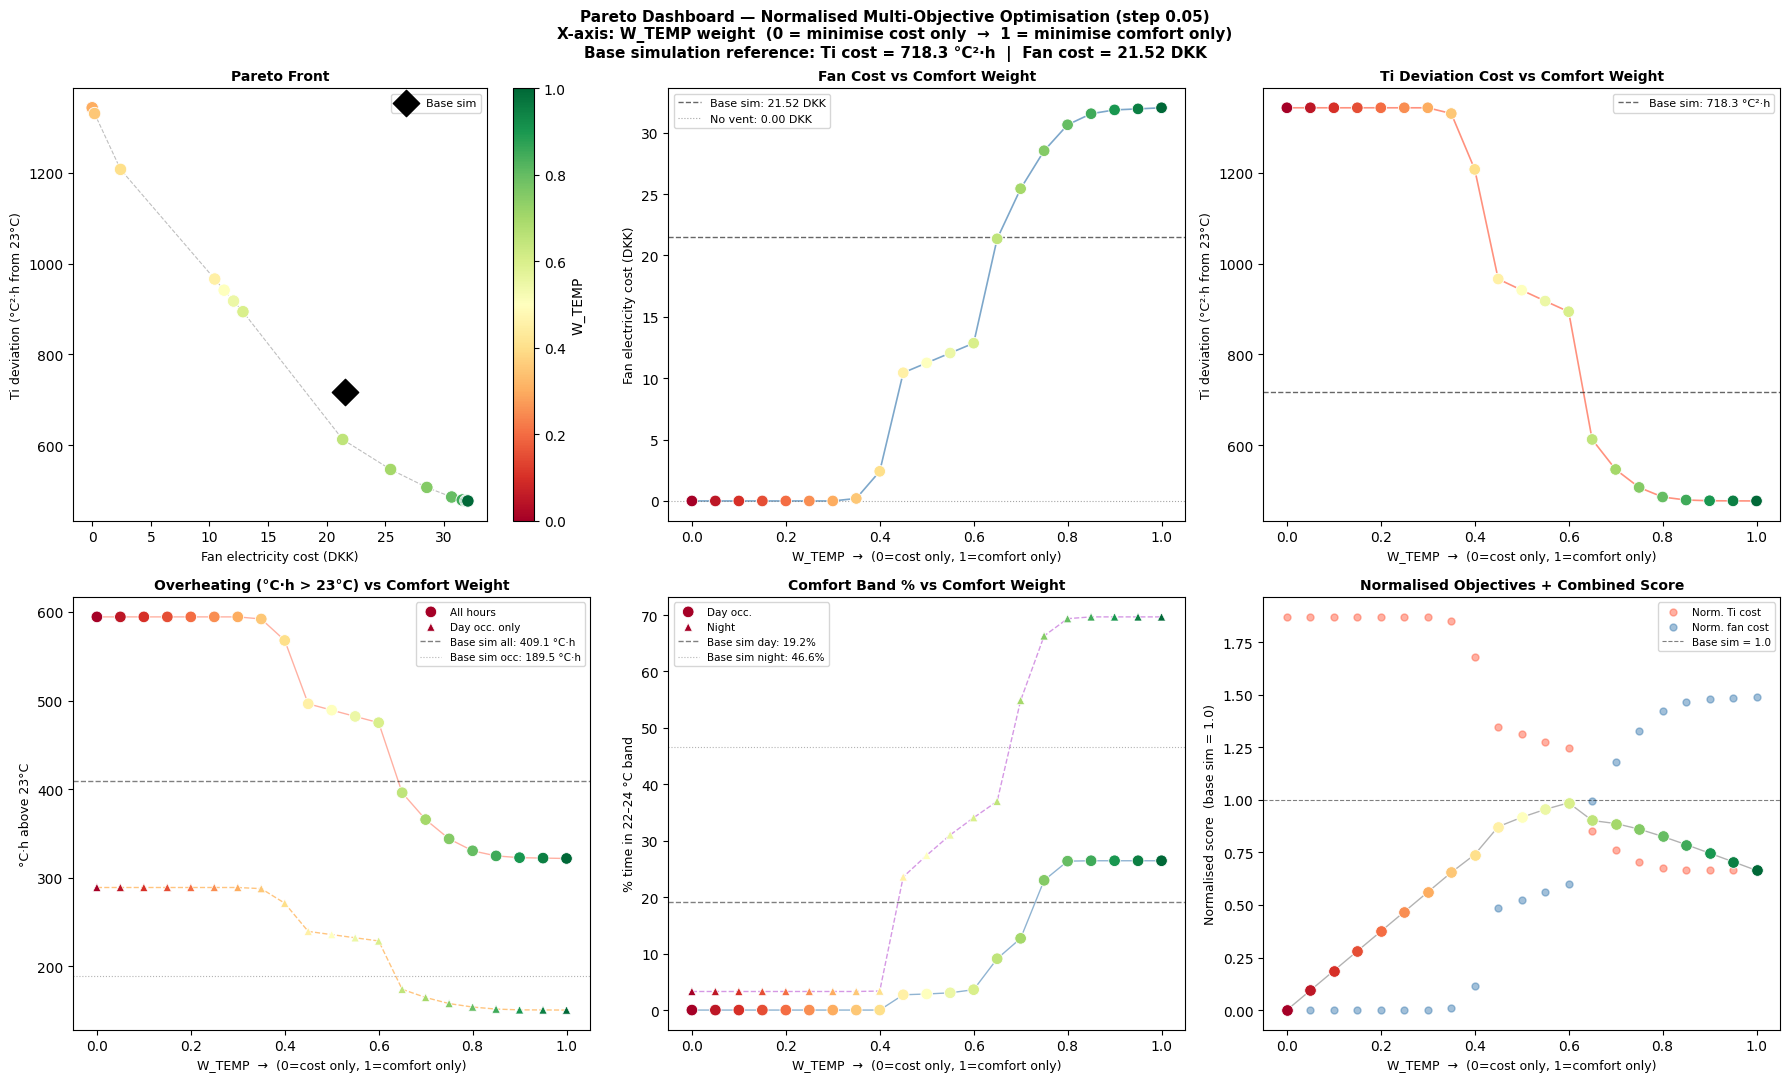

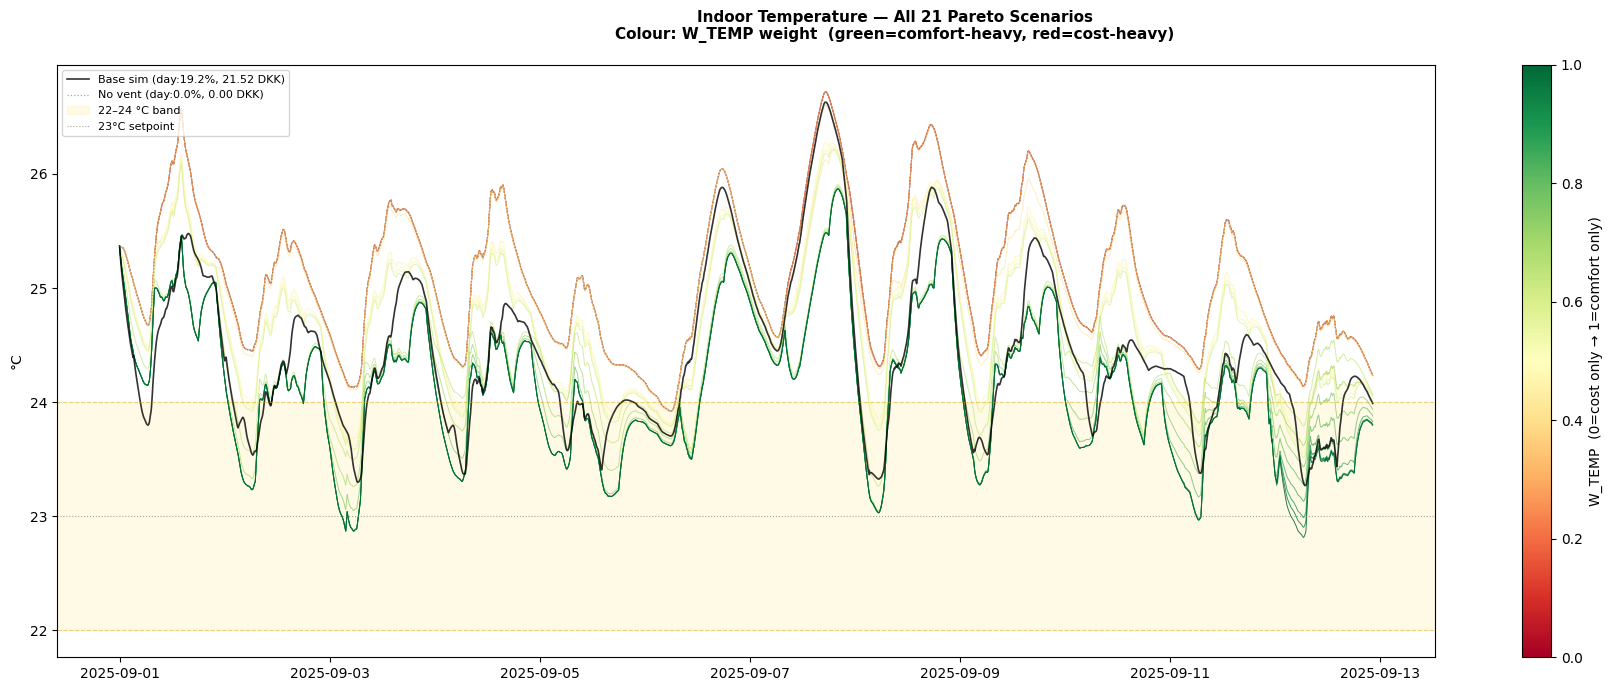

In [14]:
# ════════════════════════════════════════════════════════════════════════════
#  PARETO FRONT — every 0.05 step  (21 weight pairs)
# ════════════════════════════════════════════════════════════════════════════
weight_pairs_fine = [(round(w, 2), round(1 - w, 2))
                     for w in np.arange(0.0, 1.05, 0.05)]

pareto_results_fine = []

for W_TEMP_N, W_COST_N in weight_pairs_fine:
    label = f'T={W_TEMP_N:.2f}/C={W_COST_N:.2f}'

    def objective_norm_fine(qv_params, wt=W_TEMP_N, wc=W_COST_N):
        qv_safe = np.clip(np.nan_to_num(qv_params, nan=QV_MAX/2.0), QV_MIN, QV_MAX)
        qv_mod, Tsup_mod = build_X_fullday(qv_safe)
        X_mod         = X_train.copy()
        X_mod['qv']   = qv_mod
        X_mod['Tsup'] = Tsup_mod
        result = simulate_night_vent_scenario(
            fitted_params, X_mod, N_hist,
            night_start_hour=0, night_stop_hour=0,
            qv_night=0,
            rec_duration=rec_duration,
            Ti_init=Ti_init, Tm_init=Tm_init, c_init=c_init
        )
        Ti = result['Ti'].values
        if not np.all(np.isfinite(Ti)):
            return 1e10
        dev = (np.maximum(0.0, Ti - T_TARGET)**2 +
               np.maximum(0.0, T_TARGET - Ti)**2)
        return wt * (float(dev.sum() * dt_h) / Ti_cost_ref) + \
               wc * (fan_cost(qv_mod)        / fan_cost_ref_v)

    print(f"  [{W_TEMP_N:.2f}/{W_COST_N:.2f}] optimising...", end=' ')
    res = minimize(
        objective_norm_fine,
        x0=np.full(n_days_occ + n_nights, QV_MAX * (0.5 * W_TEMP_N + 0.1)),
        method='L-BFGS-B',
        bounds=[(QV_MIN, QV_MAX)] * (n_days_occ + n_nights),
        options={'maxiter': 500, 'ftol': 1e-7, 'gtol': 1e-5, 'eps': 1.0}
    )

    qv_p = np.clip(np.nan_to_num(res.x, nan=0.0), QV_MIN, QV_MAX)
    qv_f, Tsup_f = build_X_fullday(qv_p)
    X_p         = X_train.copy()
    X_p['qv']   = qv_f
    X_p['Tsup'] = Tsup_f
    sim_p = simulate_night_vent_scenario(
        fitted_params, X_p, N_hist,
        night_start_hour=0, night_stop_hour=0,
        qv_night=0,
        rec_duration=rec_duration,
        Ti_init=Ti_init, Tm_init=Tm_init, c_init=c_init
    )
    Ti_p        = np.asarray(sim_p['Ti'])
    dev_p       = (np.maximum(0.0, Ti_p - T_TARGET)**2 +
                   np.maximum(0.0, T_TARGET - Ti_p)**2)
    ti_cost_p   = float(dev_p.sum() * dt_h)
    fc_p        = fan_cost(qv_f)
    pct_occ_p   = pct_in_band(sim_p['Ti'], T_cat1_min, T_cat1_max, occ_mask)
    pct_night_p = pct_in_band(sim_p['Ti'], T_cat1_min, T_cat1_max, all_night_mask)
    dh_ab, dh_bel = dh_from_target(Ti_p, T_TARGET)
    dh_ab_occ, _  = dh_from_target(Ti_p, T_TARGET, occ_mask)

    pareto_results_fine.append({
        'label'        : label,
        'W_TEMP'       : W_TEMP_N,
        'W_COST'       : W_COST_N,
        'Ti_cost'      : ti_cost_p,
        'fan_cost'     : fc_p,
        'pct_occ'      : pct_occ_p,
        'pct_night'    : pct_night_p,
        'dh_above'     : dh_ab,
        'dh_below'     : dh_bel,
        'dh_above_occ' : dh_ab_occ,
        'Ti_arr'       : Ti_p,
        'qv_arr'       : qv_f,
        'converged'    : res.success,
    })
    print(f"Ti={ti_cost_p:.1f} °C²·h  |  Fan={fc_p:.2f} DKK  "
          f"|  Day={pct_occ_p:.1f}%  Night={pct_night_p:.1f}%")


# ── Print full Pareto table ───────────────────────────────────────────────────
print(f"\n{'═'*100}")
print(f"  Full Pareto table (step 0.05)")
print(f"{'═'*100}")
print(f"  {'Weights T/C':<16} {'Ti°C²·h':>10} {'ΔTi':>8} "
      f"{'DKK':>8} {'ΔDKK':>8} "
      f"{'°Ch>23':>9} {'°Ch>23occ':>11} "
      f"{'Day%':>7} {'Night%':>8} {'Conv':>6}")
print(f"{'─'*100}")
print(f"  {'Base sim (ref)':<16} {Ti_cost_ref:>10.1f} {'—':>8} "
      f"{fan_cost_ref_v:>8.2f} {'—':>8} "
      f"{'—':>9} {'—':>11} "
      f"{pct_occ_ref:>6.1f}% {pct_night_ref:>7.1f}% {'—':>6}")
for r in pareto_results_fine:
    print(f"  {r['label']:<16} {r['Ti_cost']:>10.1f} {r['Ti_cost']-Ti_cost_ref:>+8.1f} "
          f"{r['fan_cost']:>8.2f} {r['fan_cost']-fan_cost_ref_v:>+8.2f} "
          f"{r['dh_above']:>9.2f} {r['dh_above_occ']:>11.2f} "
          f"{r['pct_occ']:>6.1f}% {r['pct_night']:>7.1f}% "
          f"{'✓' if r['converged'] else '✗':>6}")
print(f"{'═'*100}")


# ════════════════════════════════════════════════════════════════════════════
#  FIGURE — Pareto dashboard  (5 panels)
# ════════════════════════════════════════════════════════════════════════════
wt_vals    = np.array([r['W_TEMP']    for r in pareto_results_fine])
ti_costs_f = np.array([r['Ti_cost']   for r in pareto_results_fine])
fc_vals    = np.array([r['fan_cost']  for r in pareto_results_fine])
pct_occ_f  = np.array([r['pct_occ']  for r in pareto_results_fine])
pct_ngt_f  = np.array([r['pct_night']for r in pareto_results_fine])
dh_ab_f    = np.array([r['dh_above'] for r in pareto_results_fine])
dh_ab_occ_f= np.array([r['dh_above_occ'] for r in pareto_results_fine])
x_axis     = wt_vals   # W_TEMP on x-axis (0 = pure cost, 1 = pure comfort)

cmap_p = plt.cm.RdYlGn
colors_fine = [cmap_p(w) for w in wt_vals]

fig_dash, axes_d = plt.subplots(2, 3, figsize=(18, 11))
fig_dash.suptitle(
    'Pareto Dashboard — Normalised Multi-Objective Optimisation (step 0.05)\n'
    f'X-axis: W_TEMP weight  (0 = minimise cost only  →  1 = minimise comfort only)\n'
    f'Base simulation reference: Ti cost = {Ti_cost_ref:.1f} °C²·h  |  '
    f'Fan cost = {fan_cost_ref_v:.2f} DKK',
    fontsize=11, fontweight='bold'
)

# ── Panel 0: Pareto front scatter (Ti cost vs fan cost) ──────────────────────
ax = axes_d[0, 0]
sc = ax.scatter(fc_vals, ti_costs_f, c=wt_vals, cmap=cmap_p, s=80,
                zorder=3, edgecolors='white', linewidths=0.6, vmin=0, vmax=1)
ax.plot(fc_vals, ti_costs_f, color='grey', lw=0.8, ls='--', alpha=0.5, zorder=1)
ax.scatter(fan_cost_ref_v, Ti_cost_ref, color='black', s=180,
           marker='D', zorder=5, label='Base sim')
plt.colorbar(sc, ax=ax, label='W_TEMP')
ax.set_xlabel('Fan electricity cost (DKK)', fontsize=9)
ax.set_ylabel('Ti deviation (°C²·h from 23°C)', fontsize=9)
ax.set_title('Pareto Front', fontsize=10, fontweight='bold')
ax.legend(fontsize=8)

# ── Panel 1: Fan cost vs W_TEMP ───────────────────────────────────────────────
ax = axes_d[0, 1]
ax.scatter(x_axis, fc_vals, c=wt_vals, cmap=cmap_p, s=70,
           zorder=3, edgecolors='white', linewidths=0.6, vmin=0, vmax=1)
ax.plot(x_axis, fc_vals, color='steelblue', lw=1.2, alpha=0.7)
ax.axhline(fan_cost_ref_v, color='black', lw=1.0, ls='--', alpha=0.6,
           label=f'Base sim: {fan_cost_ref_v:.2f} DKK')
ax.axhline(cost_novent, color='dimgray', lw=0.8, ls=':', alpha=0.6,
           label=f'No vent: {cost_novent:.2f} DKK')
ax.set_xlabel('W_TEMP  →  (0=cost only, 1=comfort only)', fontsize=9)
ax.set_ylabel('Fan electricity cost (DKK)', fontsize=9)
ax.set_title('Fan Cost vs Comfort Weight', fontsize=10, fontweight='bold')
ax.legend(fontsize=8)

# ── Panel 2: Ti cost (°C²·h) vs W_TEMP ───────────────────────────────────────
ax = axes_d[0, 2]
ax.scatter(x_axis, ti_costs_f, c=wt_vals, cmap=cmap_p, s=70,
           zorder=3, edgecolors='white', linewidths=0.6, vmin=0, vmax=1)
ax.plot(x_axis, ti_costs_f, color='tomato', lw=1.2, alpha=0.7)
ax.axhline(Ti_cost_ref, color='black', lw=1.0, ls='--', alpha=0.6,
           label=f'Base sim: {Ti_cost_ref:.1f} °C²·h')
ax.set_xlabel('W_TEMP  →  (0=cost only, 1=comfort only)', fontsize=9)
ax.set_ylabel('Ti deviation (°C²·h from 23°C)', fontsize=9)
ax.set_title('Ti Deviation Cost vs Comfort Weight', fontsize=10, fontweight='bold')
ax.legend(fontsize=8)

# ── Panel 3: °C·h above 23°C vs W_TEMP ───────────────────────────────────────
ax = axes_d[1, 0]
ax.scatter(x_axis, dh_ab_f,     c=wt_vals, cmap=cmap_p, s=70,
           zorder=3, edgecolors='white', linewidths=0.6, vmin=0, vmax=1,
           label='All hours')
ax.scatter(x_axis, dh_ab_occ_f, c=wt_vals, cmap=cmap_p, s=35, marker='^',
           zorder=3, edgecolors='white', linewidths=0.5, vmin=0, vmax=1,
           label='Day occ. only')
ax.plot(x_axis, dh_ab_f,     color='tomato',    lw=1.0, alpha=0.5)
ax.plot(x_axis, dh_ab_occ_f, color='darkorange', lw=1.0, alpha=0.5, ls='--')
ax.axhline(dh_above_ref,     color='black',  lw=1.0, ls='--', alpha=0.5,
           label=f'Base sim all: {dh_above_ref:.1f} °C·h')
ax.axhline(dh_above_ref_occ, color='dimgray', lw=0.8, ls=':', alpha=0.5,
           label=f'Base sim occ: {dh_above_ref_occ:.1f} °C·h')
ax.set_xlabel('W_TEMP  →  (0=cost only, 1=comfort only)', fontsize=9)
ax.set_ylabel('°C·h above 23°C', fontsize=9)
ax.set_title('Overheating (°C·h > 23°C) vs Comfort Weight', fontsize=10, fontweight='bold')
ax.legend(fontsize=7.5)

# ── Panel 4: % in 22–24°C band vs W_TEMP ─────────────────────────────────────
ax = axes_d[1, 1]
ax.scatter(x_axis, pct_occ_f, c=wt_vals, cmap=cmap_p, s=70,
           zorder=3, edgecolors='white', linewidths=0.6, vmin=0, vmax=1,
           label='Day occ.')
ax.scatter(x_axis, pct_ngt_f, c=wt_vals, cmap=cmap_p, s=35, marker='^',
           zorder=3, edgecolors='white', linewidths=0.5, vmin=0, vmax=1,
           label='Night')
ax.plot(x_axis, pct_occ_f, color='steelblue',    lw=1.0, alpha=0.6)
ax.plot(x_axis, pct_ngt_f, color='mediumorchid', lw=1.0, alpha=0.6, ls='--')
ax.axhline(pct_occ_ref,   color='black',  lw=1.0, ls='--', alpha=0.5,
           label=f'Base sim day: {pct_occ_ref:.1f}%')
ax.axhline(pct_night_ref, color='dimgray', lw=0.8, ls=':', alpha=0.5,
           label=f'Base sim night: {pct_night_ref:.1f}%')
ax.set_xlabel('W_TEMP  →  (0=cost only, 1=comfort only)', fontsize=9)
ax.set_ylabel('% time in 22–24 °C band', fontsize=9)
ax.set_title('Comfort Band % vs Comfort Weight', fontsize=10, fontweight='bold')
ax.legend(fontsize=7.5)

# ── Panel 5: Normalised combined score ────────────────────────────────────────
ax = axes_d[1, 2]
norm_ti = ti_costs_f / Ti_cost_ref
norm_fc = fc_vals    / fan_cost_ref_v
for i, (wt, wc) in enumerate([(r['W_TEMP'], r['W_COST']) for r in pareto_results_fine]):
    combined = wt * norm_ti[i] + wc * norm_fc[i]
    ax.scatter(x_axis[i], combined, color=colors_fine[i], s=70,
               zorder=3, edgecolors='white', linewidths=0.6)
combined_all = wt_vals * norm_ti + (1 - wt_vals) * norm_fc
ax.plot(x_axis, combined_all, color='grey', lw=1.0, alpha=0.6)
ax.scatter(x_axis, norm_ti, color='tomato',    s=25, alpha=0.5, label='Norm. Ti cost')
ax.scatter(x_axis, norm_fc, color='steelblue', s=25, alpha=0.5, label='Norm. fan cost')
ax.axhline(1.0, color='black', lw=0.8, ls='--', alpha=0.5, label='Base sim = 1.0')
ax.set_xlabel('W_TEMP  →  (0=cost only, 1=comfort only)', fontsize=9)
ax.set_ylabel('Normalised score  (base sim = 1.0)', fontsize=9)
ax.set_title('Normalised Objectives + Combined Score', fontsize=10, fontweight='bold')
ax.legend(fontsize=7.5)

plt.tight_layout()
plt.savefig('pareto_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()


# ════════════════════════════════════════════════════════════════════════════
#  BONUS — Temperature time series for every scenario (heatmap style)
# ════════════════════════════════════════════════════════════════════════════
fig_ts, ax_ts_all = plt.subplots(figsize=(18, 7))
fig_ts.suptitle(
    'Indoor Temperature — All 21 Pareto Scenarios\n'
    'Colour: W_TEMP weight  (green=comfort-heavy, red=cost-heavy)',
    fontsize=11, fontweight='bold'
)
for i, r in enumerate(pareto_results_fine):
    alpha = 0.35 + 0.5 * r['W_TEMP']
    ax_ts_all.plot(index, r['Ti_arr'], color=cmap_p(r['W_TEMP']),
                   lw=0.7, alpha=alpha)

ax_ts_all.plot(index, Ti_ref,    color='black', lw=1.2, alpha=0.8,
               label=f'Base sim (day:{pct_occ_ref:.1f}%, {fan_cost_ref_v:.2f} DKK)')
ax_ts_all.plot(index, Ti_novent, color='dimgray', lw=0.9, ls=':', alpha=0.6,
               label=f'No vent (day:{pct_occ_novent:.1f}%, {cost_novent:.2f} DKK)')
ax_ts_all.axhspan(T_cat1_min, T_cat1_max, alpha=0.10, color='gold',
                  label='22–24 °C band')
ax_ts_all.axhline(T_cat1_max, color='goldenrod', lw=0.8, ls='--', alpha=0.5)
ax_ts_all.axhline(T_cat1_min, color='goldenrod', lw=0.8, ls='--', alpha=0.5)
ax_ts_all.axhline(T_TARGET,   color='grey',      lw=0.8, ls=':',  alpha=0.7,
                  label='23°C setpoint')

sm = plt.cm.ScalarMappable(cmap=cmap_p, norm=plt.Normalize(0, 1))
sm.set_array([])
plt.colorbar(sm, ax=ax_ts_all, label='W_TEMP  (0=cost only → 1=comfort only)')
ax_ts_all.set_ylabel('°C', fontsize=10)
ax_ts_all.legend(fontsize=8, loc='upper left')
plt.tight_layout()
plt.savefig('pareto_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()



────────────────────────────────────────────────────────────────────────────────
  Rule-based heuristic results  (proportional, iterative 4×)
────────────────────────────────────────────────────────────────────────────────
   delta_max     Ti°C²h      DKK    °Ch>23    Day%   Night%
────────────────────────────────────────────────────────────────────────────────
    Base sim      718.3    21.52    409.09   19.2%    46.6%
         0.5      543.5    31.38    330.77   28.6%    69.8%
         1.0      543.5    31.38    330.77   28.6%    69.8%
         2.0      543.5    31.38    330.77   28.6%    69.8%
         3.0      543.5    31.38    330.78   28.6%    69.8%
         5.0      546.3    31.07    332.08   28.3%    69.7%
────────────────────────────────────────────────────────────────────────────────
   bang-bang      543.5    31.38    330.77   28.6%    69.8%
  [0.00/1.00] best of 5 starts: Ti=1343.5  Fan=0.00 DKK  Day=0.0%  Night=3.3%
  [0.05/0.95] best of 5 starts: Ti=1343.5  Fan=0.00 DKK 

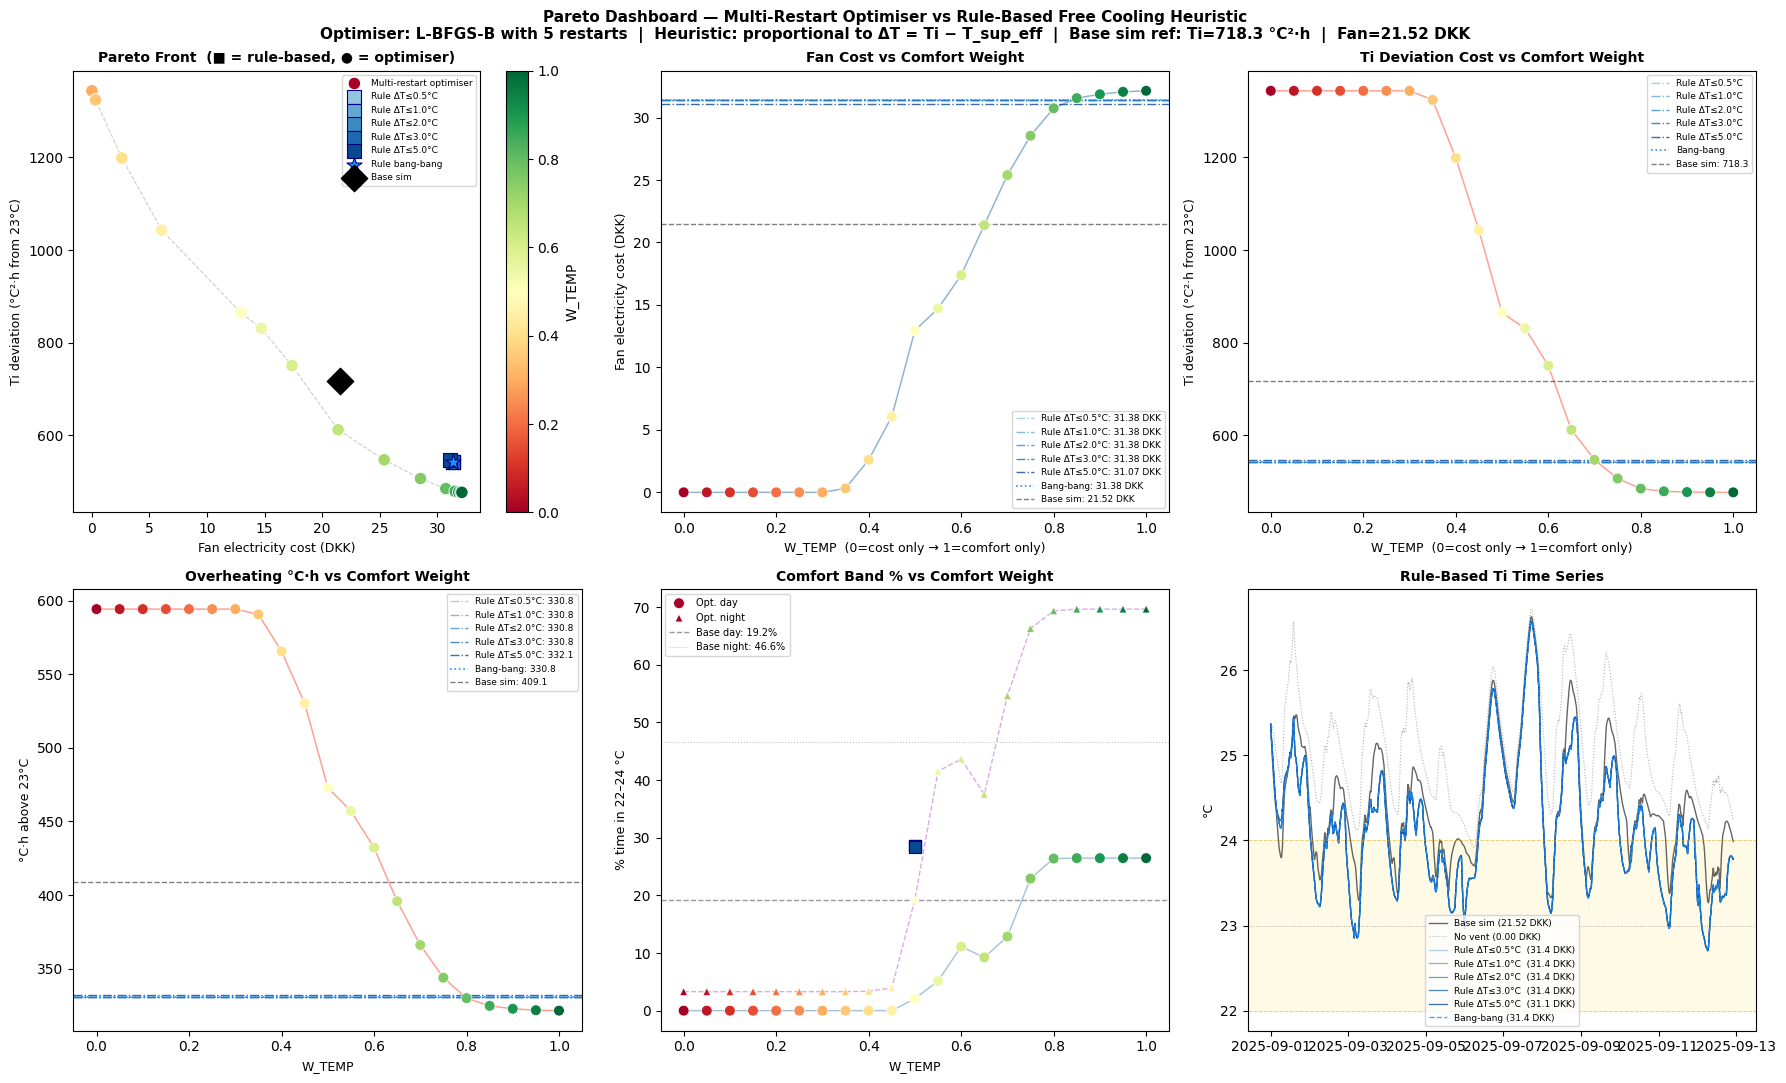

In [15]:
# ════════════════════════════════════════════════════════════════════════════
#  RULE-BASED FREE COOLING HEURISTIC
#  At each timestep:
#    - Night (weekday, 20–08, Ta > 14°C): qv ∝ max(0, Ti − T_ext)
#    - Day   (weekday, 08–18)           : qv ∝ max(0, Ti − Tsup_measured)
#    - Else                             : qv = 0
#
#  Strategy: ventilate at full rate when ΔT > delta_max, proportionally below
#  Iterative: simulate → compute ΔT → update qv → re-simulate (3 iterations)
# ════════════════════════════════════════════════════════════════════════════

def build_X_rule_based(Ti_arr_ref, delta_max=2.0, mode='proportional'):
    """
    Ti_arr_ref : Ti from previous iteration (used to compute driving ΔT)
    delta_max  : ΔT at which qv reaches QV_MAX
    mode       : 'proportional' | 'bangbang'
    """
    qv_mod   = qv_arr.copy()
    Tsup_mod = Tsup_arr.copy()

    for i in range(len(index)):
        t     = index[i]
        h     = hours[i]
        is_wkday = t.weekday() < 5

        # Night: free cooling with T_ext
        if night_time_mask[i] and is_wkday and ta_ok_mask[i]:
            delta = float(Ti_arr_ref[i]) - float(Ta_arr[i])
            if mode == 'bangbang':
                qv_mod[i] = QV_MAX if delta > 0 else 0.0
            else:
                qv_mod[i] = float(np.clip(delta / delta_max, 0.0, 1.0)) * QV_MAX
            Tsup_mod[i] = Ta_arr[i]

        # Night but Ta ≤ 14°C: cut flow
        elif night_time_mask[i] and is_wkday and not ta_ok_mask[i]:
            qv_mod[i]   = 0.0

        # Day: use measured Tsup, ventilate based on Ti − Tsup
        elif (h >= OCC_START) and (h < OCC_END) and is_wkday:
            delta = float(Ti_arr_ref[i]) - float(Tsup_arr[i])
            if mode == 'bangbang':
                qv_mod[i] = QV_MAX if delta > 0 else 0.0
            else:
                qv_mod[i] = float(np.clip(delta / delta_max, 0.0, 1.0)) * QV_MAX
            # Tsup stays at measured value

    return qv_mod, Tsup_mod


def simulate_rule_based(delta_max=2.0, mode='proportional', n_iter=4):
    """
    Iterative loop:
      1. Start from base_sim Ti as initial reference
      2. Build qv based on ΔT rule
      3. Re-simulate → get new Ti
      4. Repeat n_iter times (converges fast)
    """
    Ti_ref_iter = Ti_ref.copy()   # initialise from base simulation

    for it in range(n_iter):
        qv_mod, Tsup_mod = build_X_rule_based(Ti_ref_iter, delta_max, mode)
        X_mod         = X_train.copy()
        X_mod['qv']   = qv_mod
        X_mod['Tsup'] = Tsup_mod
        sim = simulate_night_vent_scenario(
            fitted_params, X_mod, N_hist,
            night_start_hour=0, night_stop_hour=0,
            qv_night=0,
            rec_duration=rec_duration,
            Ti_init=Ti_init, Tm_init=Tm_init, c_init=c_init
        )
        Ti_ref_iter = np.asarray(sim['Ti'])

    return sim, qv_mod, Tsup_mod


# ── Run for several delta_max thresholds ─────────────────────────────────────
delta_max_values = [0.5, 1.0, 2.0, 3.0, 5.0]
rule_results = {}

print(f"\n{'─'*80}")
print(f"  Rule-based heuristic results  (proportional, iterative 4×)")
print(f"{'─'*80}")
print(f"  {'delta_max':>10} {'Ti°C²h':>10} {'DKK':>8} "
      f"{'°Ch>23':>9} {'Day%':>7} {'Night%':>8}")
print(f"{'─'*80}")
print(f"  {'Base sim':>10} {Ti_cost_ref:>10.1f} {fan_cost_ref_v:>8.2f} "
      f"{dh_above_ref:>9.2f} {pct_occ_ref:>6.1f}% {pct_night_ref:>7.1f}%")

for dm in delta_max_values:
    sim_r, qv_r, _ = simulate_rule_based(delta_max=dm, mode='proportional')
    Ti_r   = np.asarray(sim_r['Ti'])
    dev_r  = (np.maximum(0.0, Ti_r - T_TARGET)**2 +
              np.maximum(0.0, T_TARGET - Ti_r)**2)
    ti_c   = float(dev_r.sum() * dt_h)
    fc     = fan_cost(qv_r)
    pct_d  = pct_in_band(sim_r['Ti'], T_cat1_min, T_cat1_max, occ_mask)
    pct_n  = pct_in_band(sim_r['Ti'], T_cat1_min, T_cat1_max, all_night_mask)
    dh_ab, _ = dh_from_target(Ti_r, T_TARGET)
    dh_ab_occ, _ = dh_from_target(Ti_r, T_TARGET, occ_mask)

    rule_results[dm] = {
        'Ti_arr': Ti_r, 'qv_arr': qv_r,
        'Ti_cost': ti_c, 'fan_cost': fc,
        'pct_occ': pct_d, 'pct_night': pct_n,
        'dh_above': dh_ab, 'dh_above_occ': dh_ab_occ,
    }
    print(f"  {dm:>10.1f} {ti_c:>10.1f} {fc:>8.2f} "
          f"{dh_ab:>9.2f} {pct_d:>6.1f}% {pct_n:>7.1f}%")

print(f"{'─'*80}")


# ── Bang-bang version (full QV_MAX whenever Ti > T_sup) ──────────────────────
sim_bb, qv_bb, _ = simulate_rule_based(delta_max=0, mode='bangbang')
Ti_bb    = np.asarray(sim_bb['Ti'])
dev_bb   = (np.maximum(0.0, Ti_bb - T_TARGET)**2 +
            np.maximum(0.0, T_TARGET - Ti_bb)**2)
ti_c_bb  = float(dev_bb.sum() * dt_h)
fc_bb    = fan_cost(qv_bb)
pct_d_bb = pct_in_band(sim_bb['Ti'], T_cat1_min, T_cat1_max, occ_mask)
pct_n_bb = pct_in_band(sim_bb['Ti'], T_cat1_min, T_cat1_max, all_night_mask)
dh_bb, _ = dh_from_target(Ti_bb, T_TARGET)

rule_results['bangbang'] = {
    'Ti_arr': Ti_bb, 'qv_arr': qv_bb,
    'Ti_cost': ti_c_bb, 'fan_cost': fc_bb,
    'pct_occ': pct_d_bb, 'pct_night': pct_n_bb,
    'dh_above': dh_bb,
}
print(f"  {'bang-bang':>10} {ti_c_bb:>10.1f} {fc_bb:>8.2f} "
      f"{dh_bb:>9.2f} {pct_d_bb:>6.1f}% {pct_n_bb:>7.1f}%")


# ════════════════════════════════════════════════════════════════════════════
#  IMPROVED PARETO: multi-restart L-BFGS-B to avoid local minima
# ════════════════════════════════════════════════════════════════════════════
N_RESTARTS = 3   # number of random restarts per weight pair

pareto_results_mr = []
rng = np.random.default_rng(42)

for W_TEMP_N, W_COST_N in weight_pairs_fine:
    label = f'T={W_TEMP_N:.2f}/C={W_COST_N:.2f}'
    best_res, best_fun = None, np.inf

    # Starting points: warm start from rule-based + random restarts
    starts = [
        np.full(n_days_occ + n_nights, QV_MAX * 0.5),
        np.concatenate([np.full(n_days_occ, QV_MAX * W_TEMP_N),
                        np.full(n_nights,   QV_MAX * W_TEMP_N)]),
    ]
    for _ in range(N_RESTARTS):
        starts.append(rng.uniform(QV_MIN, QV_MAX, n_days_occ + n_nights))

    def obj_mr(qv_params, wt=W_TEMP_N, wc=W_COST_N):
        qv_safe = np.clip(np.nan_to_num(qv_params, nan=QV_MAX/2.0), QV_MIN, QV_MAX)
        qv_mod, Tsup_mod = build_X_fullday(qv_safe)
        X_mod = X_train.copy(); X_mod['qv'] = qv_mod; X_mod['Tsup'] = Tsup_mod
        result = simulate_night_vent_scenario(
            fitted_params, X_mod, N_hist,
            night_start_hour=0, night_stop_hour=0, qv_night=0,
            rec_duration=rec_duration,
            Ti_init=Ti_init, Tm_init=Tm_init, c_init=c_init
        )
        Ti = result['Ti'].values
        if not np.all(np.isfinite(Ti)):
            return 1e10
        dev = (np.maximum(0.0, Ti - T_TARGET)**2 +
               np.maximum(0.0, T_TARGET - Ti)**2)
        return wt * (float(dev.sum() * dt_h) / Ti_cost_ref) + \
               wc * (fan_cost(qv_mod)        / fan_cost_ref_v)

    for x0_mr in starts:
        r = minimize(obj_mr, x0_mr, method='L-BFGS-B',
                     bounds=[(QV_MIN, QV_MAX)] * (n_days_occ + n_nights),
                     options={'maxiter': 500, 'ftol': 1e-7, 'gtol': 1e-5, 'eps': 1.0})
        if r.fun < best_fun:
            best_fun, best_res = r.fun, r

    qv_p = np.clip(np.nan_to_num(best_res.x, nan=0.0), QV_MIN, QV_MAX)
    qv_f, Tsup_f = build_X_fullday(qv_p)
    X_p = X_train.copy(); X_p['qv'] = qv_f; X_p['Tsup'] = Tsup_f
    sim_p = simulate_night_vent_scenario(
        fitted_params, X_p, N_hist,
        night_start_hour=0, night_stop_hour=0, qv_night=0,
        rec_duration=rec_duration,
        Ti_init=Ti_init, Tm_init=Tm_init, c_init=c_init
    )
    Ti_p    = np.asarray(sim_p['Ti'])
    dev_p   = (np.maximum(0.0, Ti_p - T_TARGET)**2 +
               np.maximum(0.0, T_TARGET - Ti_p)**2)
    ti_c_p  = float(dev_p.sum() * dt_h)
    fc_p    = fan_cost(qv_f)
    pct_o_p = pct_in_band(sim_p['Ti'], T_cat1_min, T_cat1_max, occ_mask)
    pct_n_p = pct_in_band(sim_p['Ti'], T_cat1_min, T_cat1_max, all_night_mask)
    dh_p, _ = dh_from_target(Ti_p, T_TARGET)
    dh_p_occ, _ = dh_from_target(Ti_p, T_TARGET, occ_mask)

    pareto_results_mr.append({
        'label': label, 'W_TEMP': W_TEMP_N, 'W_COST': W_COST_N,
        'Ti_cost': ti_c_p, 'fan_cost': fc_p,
        'pct_occ': pct_o_p, 'pct_night': pct_n_p,
        'dh_above': dh_p, 'dh_above_occ': dh_p_occ,
        'Ti_arr': Ti_p, 'qv_arr': qv_f,
    })
    print(f"  [{W_TEMP_N:.2f}/{W_COST_N:.2f}] best of {len(starts)} starts: "
          f"Ti={ti_c_p:.1f}  Fan={fc_p:.2f} DKK  "
          f"Day={pct_o_p:.1f}%  Night={pct_n_p:.1f}%")


# ════════════════════════════════════════════════════════════════════════════
#  FIGURE — Pareto dashboard with rule-based overlaid
# ════════════════════════════════════════════════════════════════════════════
wt_mr  = np.array([r['W_TEMP']    for r in pareto_results_mr])
ti_mr  = np.array([r['Ti_cost']   for r in pareto_results_mr])
fc_mr  = np.array([r['fan_cost']  for r in pareto_results_mr])
po_mr  = np.array([r['pct_occ']   for r in pareto_results_mr])
pn_mr  = np.array([r['pct_night'] for r in pareto_results_mr])
dh_mr  = np.array([r['dh_above']  for r in pareto_results_mr])

cmap_p = plt.cm.RdYlGn
# rule-based series for scatter overlays
dm_keys   = [0.5, 1.0, 2.0, 3.0, 5.0]
rb_colors = plt.cm.Blues(np.linspace(0.4, 0.9, len(dm_keys)))

fig_db2, axes_db = plt.subplots(2, 3, figsize=(18, 11))
fig_db2.suptitle(
    'Pareto Dashboard — Multi-Restart Optimiser vs Rule-Based Free Cooling Heuristic\n'
    'Optimiser: L-BFGS-B with 5 restarts  |  Heuristic: proportional to ΔT = Ti − T_sup_eff  |  '
    f'Base sim ref: Ti={Ti_cost_ref:.1f} °C²·h  |  Fan={fan_cost_ref_v:.2f} DKK',
    fontsize=11, fontweight='bold'
)

# ── Panel 0: Pareto front (Ti cost vs fan cost) ───────────────────────────────
ax = axes_db[0, 0]
sc = ax.scatter(fc_mr, ti_mr, c=wt_mr, cmap=cmap_p, s=80, zorder=3,
                edgecolors='white', linewidths=0.6, vmin=0, vmax=1,
                label='Multi-restart optimiser')
ax.plot(fc_mr, ti_mr, color='grey', lw=0.8, ls='--', alpha=0.4, zorder=1)
# Rule-based points
for i, dm in enumerate(dm_keys):
    r = rule_results[dm]
    ax.scatter(r['fan_cost'], r['Ti_cost'], color=rb_colors[i], s=100,
               marker='s', zorder=4, edgecolors='navy', linewidths=0.8,
               label=f'Rule ΔT≤{dm}°C')
ax.scatter(rule_results['bangbang']['fan_cost'],
           rule_results['bangbang']['Ti_cost'],
           color='dodgerblue', s=130, marker='*', zorder=5,
           edgecolors='navy', linewidths=0.8, label='Rule bang-bang')
ax.scatter(fan_cost_ref_v, Ti_cost_ref, color='black', s=180,
           marker='D', zorder=6, label='Base sim')
plt.colorbar(sc, ax=ax, label='W_TEMP')
ax.set_xlabel('Fan electricity cost (DKK)', fontsize=9)
ax.set_ylabel('Ti deviation (°C²·h from 23°C)', fontsize=9)
ax.set_title('Pareto Front  (■ = rule-based, ● = optimiser)', fontsize=10, fontweight='bold')
ax.legend(fontsize=6.5, loc='upper right')

# ── Panel 1: Fan cost vs W_TEMP + rule-based lines ────────────────────────────
ax = axes_db[0, 1]
ax.scatter(wt_mr, fc_mr, c=wt_mr, cmap=cmap_p, s=60, zorder=3,
           edgecolors='white', linewidths=0.5, vmin=0, vmax=1)
ax.plot(wt_mr, fc_mr, color='steelblue', lw=1.1, alpha=0.6)
for i, dm in enumerate(dm_keys):
    ax.axhline(rule_results[dm]['fan_cost'], color=rb_colors[i], lw=1.0,
               ls='-.', alpha=0.8, label=f'Rule ΔT≤{dm}°C: {rule_results[dm]["fan_cost"]:.2f} DKK')
ax.axhline(rule_results['bangbang']['fan_cost'], color='dodgerblue', lw=1.2,
           ls=':', label=f'Bang-bang: {rule_results["bangbang"]["fan_cost"]:.2f} DKK')
ax.axhline(fan_cost_ref_v, color='black', lw=1.0, ls='--', alpha=0.5,
           label=f'Base sim: {fan_cost_ref_v:.2f} DKK')
ax.set_xlabel('W_TEMP  (0=cost only → 1=comfort only)', fontsize=9)
ax.set_ylabel('Fan electricity cost (DKK)', fontsize=9)
ax.set_title('Fan Cost vs Comfort Weight', fontsize=10, fontweight='bold')
ax.legend(fontsize=6.5)

# ── Panel 2: Ti cost vs W_TEMP ────────────────────────────────────────────────
ax = axes_db[0, 2]
ax.scatter(wt_mr, ti_mr, c=wt_mr, cmap=cmap_p, s=60, zorder=3,
           edgecolors='white', linewidths=0.5, vmin=0, vmax=1)
ax.plot(wt_mr, ti_mr, color='tomato', lw=1.1, alpha=0.6)
for i, dm in enumerate(dm_keys):
    ax.axhline(rule_results[dm]['Ti_cost'], color=rb_colors[i], lw=1.0,
               ls='-.', alpha=0.8, label=f'Rule ΔT≤{dm}°C')
ax.axhline(rule_results['bangbang']['Ti_cost'], color='dodgerblue', lw=1.2, ls=':',
           label=f'Bang-bang')
ax.axhline(Ti_cost_ref, color='black', lw=1.0, ls='--', alpha=0.5,
           label=f'Base sim: {Ti_cost_ref:.1f}')
ax.set_xlabel('W_TEMP  (0=cost only → 1=comfort only)', fontsize=9)
ax.set_ylabel('Ti deviation (°C²·h from 23°C)', fontsize=9)
ax.set_title('Ti Deviation Cost vs Comfort Weight', fontsize=10, fontweight='bold')
ax.legend(fontsize=6.5)

# ── Panel 3: °C·h above 23°C ─────────────────────────────────────────────────
ax = axes_db[1, 0]
ax.scatter(wt_mr, dh_mr, c=wt_mr, cmap=cmap_p, s=60, zorder=3,
           edgecolors='white', linewidths=0.5, vmin=0, vmax=1)
ax.plot(wt_mr, dh_mr, color='tomato', lw=1.1, alpha=0.6)
for i, dm in enumerate(dm_keys):
    ax.axhline(rule_results[dm]['dh_above'], color=rb_colors[i], lw=1.0,
               ls='-.', alpha=0.8, label=f'Rule ΔT≤{dm}°C: {rule_results[dm]["dh_above"]:.1f}')
ax.axhline(rule_results['bangbang']['dh_above'], color='dodgerblue', lw=1.2, ls=':',
           label=f'Bang-bang: {rule_results["bangbang"]["dh_above"]:.1f}')
ax.axhline(dh_above_ref, color='black', lw=1.0, ls='--', alpha=0.5,
           label=f'Base sim: {dh_above_ref:.1f}')
ax.set_xlabel('W_TEMP', fontsize=9)
ax.set_ylabel('°C·h above 23°C', fontsize=9)
ax.set_title('Overheating °C·h vs Comfort Weight', fontsize=10, fontweight='bold')
ax.legend(fontsize=6.5)

# ── Panel 4: % in 22–24°C band ────────────────────────────────────────────────
ax = axes_db[1, 1]
ax.scatter(wt_mr, po_mr, c=wt_mr, cmap=cmap_p, s=60, zorder=3,
           edgecolors='white', linewidths=0.5, vmin=0, vmax=1, label='Opt. day')
ax.scatter(wt_mr, pn_mr, c=wt_mr, cmap=cmap_p, s=30, marker='^', zorder=3,
           edgecolors='white', linewidths=0.4, vmin=0, vmax=1, label='Opt. night')
ax.plot(wt_mr, po_mr, color='steelblue',    lw=1.0, alpha=0.5)
ax.plot(wt_mr, pn_mr, color='mediumorchid', lw=1.0, alpha=0.5, ls='--')
for i, dm in enumerate(dm_keys):
    ax.scatter(0.5, rule_results[dm]['pct_occ'],
               color=rb_colors[i], s=80, marker='s', zorder=4,
               edgecolors='navy', linewidths=0.8)
ax.axhline(pct_occ_ref,   color='black',  lw=1.0, ls='--', alpha=0.4,
           label=f'Base day: {pct_occ_ref:.1f}%')
ax.axhline(pct_night_ref, color='dimgray', lw=0.8, ls=':', alpha=0.4,
           label=f'Base night: {pct_night_ref:.1f}%')
ax.set_xlabel('W_TEMP', fontsize=9)
ax.set_ylabel('% time in 22–24 °C', fontsize=9)
ax.set_title('Comfort Band % vs Comfort Weight', fontsize=10, fontweight='bold')
ax.legend(fontsize=7)

# ── Panel 5: Rule-based Ti time series ───────────────────────────────────────
ax = axes_db[1, 2]
ax.plot(index, Ti_ref,  color='black',     lw=1.0, alpha=0.6,
        label=f'Base sim ({fan_cost_ref_v:.2f} DKK)')
ax.plot(index, Ti_novent, color='dimgray', lw=0.8, ls=':', alpha=0.5,
        label='No vent (0.00 DKK)')
for i, dm in enumerate(dm_keys):
    r = rule_results[dm]
    ax.plot(index, r['Ti_arr'], color=rb_colors[i], lw=0.9, alpha=0.8,
            label=f'Rule ΔT≤{dm}°C  ({r["fan_cost"]:.1f} DKK)')
ax.plot(index, rule_results['bangbang']['Ti_arr'],
        color='dodgerblue', lw=1.0, ls='--', alpha=0.8,
        label=f'Bang-bang ({rule_results["bangbang"]["fan_cost"]:.1f} DKK)')
ax.axhspan(T_cat1_min, T_cat1_max, alpha=0.10, color='gold')
ax.axhline(T_cat1_max, color='goldenrod', lw=0.7, ls='--', alpha=0.5)
ax.axhline(T_cat1_min, color='goldenrod', lw=0.7, ls='--', alpha=0.5)
ax.axhline(T_TARGET,   color='grey',      lw=0.7, ls=':',  alpha=0.6)
ax.set_ylabel('°C', fontsize=9)
ax.set_title('Rule-Based Ti Time Series', fontsize=10, fontweight='bold')
ax.legend(fontsize=6.5)

plt.tight_layout()
plt.savefig('pareto_dashboard_with_rules.png', dpi=150, bbox_inches='tight')
plt.show()


# Open-Meteo Historical Forecast validation

  X_train period: 2025-09-01 00:00:00 → 2025-09-12 22:15:00
Fetching DMI HARMONIE archived forecasts: 2025-09-01 → 2025-09-12
  Fetched 288 hourly rows from Open-Meteo.
  Merged rows: 3436  | Period: 2025-09-01 00:00:00 → 2025-09-12 22:15:00

══════════════════════════════════════════════════════════
  DMI HARMONIE forecast vs measured Ta  (full period)
──────────────────────────────────────────────────────────
  MAE   (all hours)  : 1.21 °C
  RMSE  (all hours)  : 1.49 °C
  Bias  (all hours)  : +0.51 °C
  MAE   (night only) : 1.15 °C  ← critical for 14°C threshold
──────────────────────────────────────────────────────────

  Condensation threshold decision (Ta > 14.0°C at night):
  Agreement (forecast = measured) : 93.0%
  False positive (risk of cond.)  : 7.0%  ← dangerous
  False negative (missed vent)    : 0.0%  ← conservative
══════════════════════════════════════════════════════════

  → Recommended MPC threshold: 15.5°C
    (= 14.0°C + RMSE 1.49°C)


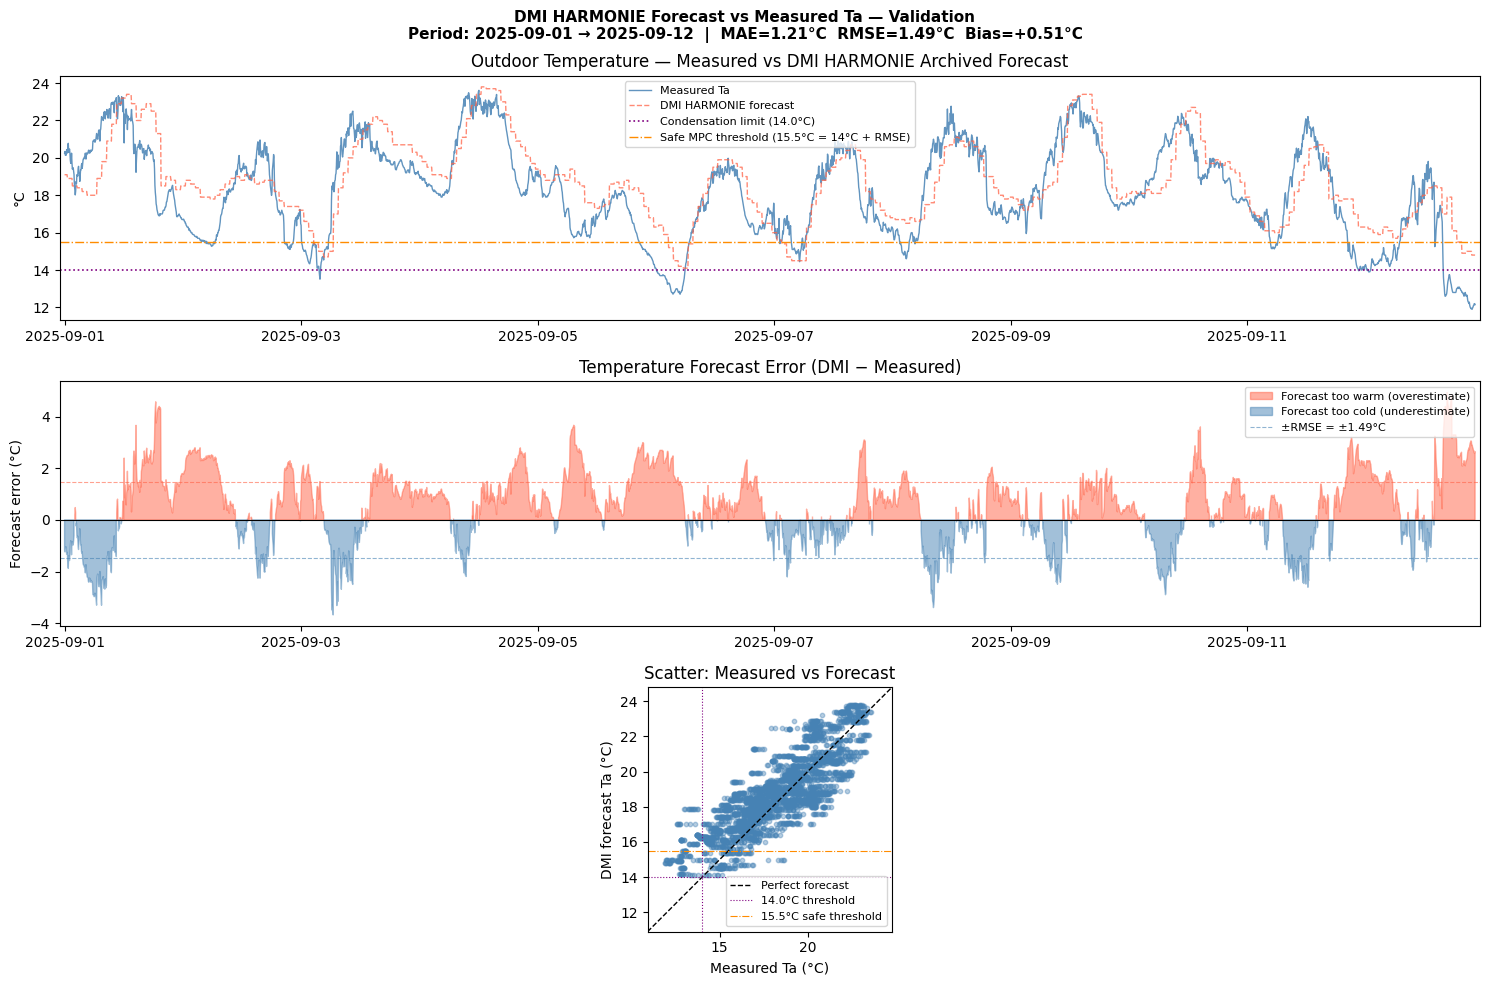

In [23]:
# ════════════════════════════════════════════════════════════════════════════
#  OPEN-METEO HISTORICAL FORECAST VALIDATION
#  Fetches archived DMI HARMONIE forecasts for the exact X_train period
#  and compares them against your measured Ta — quantifies MPC input quality.
#
#  Uses: historical-forecast-api.open-meteo.com
#  Model: dmi_harmonie_arome_dini (available from 2024-07-01 onwards)
#  No API key required.
# ════════════════════════════════════════════════════════════════════════════
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

LAT = 55.676   # ← replace with your building latitude
LON = 12.568   # ← replace with your building longitude

def fetch_openmeteo_historical_forecast(lat, lon,
                                        start_date: str,
                                        end_date: str) -> pd.DataFrame:
    """
    Fetches archived DMI HARMONIE forecast data for a specific date range.
    endpoint : historical-forecast-api.open-meteo.com  (data from 2022+)
    model    : dmi_harmonie_arome_dini (2 km, Denmark, available from 2024-07-01)
    variables: temperature_2m (°C), shortwave_radiation (W/m²),
               direct_radiation (W/m²), diffuse_radiation (W/m²)

    Parameters
    ----------
    start_date, end_date : 'YYYY-MM-DD' strings covering your X_train period
    """
    url = "https://historical-forecast-api.open-meteo.com/v1/forecast"
    params = {
        "latitude"           : lat,
        "longitude"          : lon,
        "start_date"         : start_date,
        "end_date"           : end_date,
        "hourly"             : ["temperature_2m",
                                "shortwave_radiation",
                                "direct_radiation",
                                "diffuse_radiation"],
                                "models": "dmi_harmonie_arome_europe",
        "timezone"           : "Europe/Copenhagen",
    }
    resp = requests.get(url, params=params, timeout=30)
    resp.raise_for_status()
    h = resp.json()["hourly"]

    df = pd.DataFrame({
        "timestamp"        : pd.to_datetime(h["time"]),
        "T_ext_dmi"        : h["temperature_2m"],      # °C — DMI forecast
        "rad_global_dmi"   : h["shortwave_radiation"],  # W/m² total
        "rad_direct_dmi"   : h["direct_radiation"],     # W/m² direct beam
        "rad_diffuse_dmi"  : h["diffuse_radiation"],    # W/m² diffuse
    })
    df["timestamp"] = df["timestamp"].dt.tz_localize(None)
    return df

# ── Derive date range from X_train index — robust conversion ──────────────────
# Force UTC-naive datetime regardless of index type
_idx_dt = pd.to_datetime(index, utc=False).tz_localize(None)

# Sanity check — print first/last to confirm they are Sep 2025
print(f"  X_train period: {_idx_dt[0]} → {_idx_dt[-1]}")

train_start = _idx_dt[0].strftime('%Y-%m-%d')
train_end   = _idx_dt[-1].strftime('%Y-%m-%d')
print(f"Fetching DMI HARMONIE archived forecasts: {train_start} → {train_end}")

df_hist_fc = fetch_openmeteo_historical_forecast(LAT, LON, train_start, train_end)
print(f"  Fetched {len(df_hist_fc)} hourly rows from Open-Meteo.")

# ── Merge with X_train — explicit timestamp column, drop bad rows ─────────────
X_val             = X_train.copy()
X_val["timestamp"] = _idx_dt               # use the cleaned version
X_val["Ta_meas"]   = Ta_arr

# Drop any rows where timestamp looks wrong (before 2020 = epoch artifact)
X_val = X_val[X_val["timestamp"] > pd.Timestamp("2020-01-01")]

df_merged = pd.merge_asof(
    X_val.sort_values("timestamp").reset_index(drop=True),
    df_hist_fc.sort_values("timestamp").reset_index(drop=True),
    on="timestamp",
    tolerance=pd.Timedelta("30min"),
    direction="nearest"
).dropna(subset=["T_ext_dmi"])

print(f"  Merged rows: {len(df_merged)}  "
      f"| Period: {df_merged['timestamp'].iloc[0]} → {df_merged['timestamp'].iloc[-1]}")

# ── Forecast error metrics (unchanged) ───────────────────────────────────────
df_merged["T_error"] = df_merged["T_ext_dmi"] - df_merged["Ta_meas"]
mae_t    = df_merged["T_error"].abs().mean()
rmse_t   = (df_merged["T_error"]**2).mean()**0.5
bias_t   = df_merged["T_error"].mean()

night_rows = df_merged[df_merged["timestamp"].dt.hour.apply(
    lambda h: (h >= NIGHT_START) or (h < NIGHT_STOP))]
mae_night  = (night_rows["T_ext_dmi"] - night_rows["Ta_meas"]).abs().mean()

print(f"\n{'═'*58}")
print(f"  DMI HARMONIE forecast vs measured Ta  (full period)")
print(f"{'─'*58}")
print(f"  MAE   (all hours)  : {mae_t:.2f} °C")
print(f"  RMSE  (all hours)  : {rmse_t:.2f} °C")
print(f"  Bias  (all hours)  : {bias_t:+.2f} °C")
print(f"  MAE   (night only) : {mae_night:.2f} °C  ← critical for 14°C threshold")
print(f"{'─'*58}")

df_night = df_merged[df_merged["timestamp"].dt.hour.apply(
    lambda h: (h >= NIGHT_START) or (h < NIGHT_STOP))].copy()
df_night["meas_ok"]     = df_night["Ta_meas"]   > TA_MIN_NIGHT_VENT
df_night["forecast_ok"] = df_night["T_ext_dmi"] > TA_MIN_NIGHT_VENT
agreement  = (df_night["meas_ok"] == df_night["forecast_ok"]).mean() * 100
false_pos  = ((df_night["forecast_ok"]) & (~df_night["meas_ok"])).mean() * 100
false_neg  = ((~df_night["forecast_ok"]) & (df_night["meas_ok"])).mean() * 100

print(f"\n  Condensation threshold decision (Ta > {TA_MIN_NIGHT_VENT}°C at night):")
print(f"  Agreement (forecast = measured) : {agreement:.1f}%")
print(f"  False positive (risk of cond.)  : {false_pos:.1f}%  ← dangerous")
print(f"  False negative (missed vent)    : {false_neg:.1f}%  ← conservative")
print(f"{'═'*58}")

safe_threshold = TA_MIN_NIGHT_VENT + rmse_t
print(f"\n  → Recommended MPC threshold: {safe_threshold:.1f}°C")
print(f"    (= {TA_MIN_NIGHT_VENT}°C + RMSE {rmse_t:.2f}°C)")

# ── Fixed validation plot ─────────────────────────────────────────────────────
# Explicit x-axis limits prevent epoch artifacts from stretching the axis
t_min = df_merged["timestamp"].min() - pd.Timedelta(hours=1)
t_max = df_merged["timestamp"].max() + pd.Timedelta(hours=1)

fig_val, axes_val = plt.subplots(3, 1, figsize=(15, 10), sharex=False)
fig_val.suptitle(
    f"DMI HARMONIE Forecast vs Measured Ta — Validation\n"
    f"Period: {train_start} → {train_end}  |  "
    f"MAE={mae_t:.2f}°C  RMSE={rmse_t:.2f}°C  Bias={bias_t:+.2f}°C",
    fontsize=11, fontweight='bold'
)

# Panel 1 — Time series
ax = axes_val[0]
ax.plot(df_merged["timestamp"], df_merged["Ta_meas"],
        color='steelblue', lw=1.0, alpha=0.85, label='Measured Ta')
ax.plot(df_merged["timestamp"], df_merged["T_ext_dmi"],
        color='tomato', lw=1.0, alpha=0.75, ls='--', label='DMI HARMONIE forecast')
ax.axhline(TA_MIN_NIGHT_VENT, color='purple',     lw=1.2, ls=':',
           label=f'Condensation limit ({TA_MIN_NIGHT_VENT}°C)')
ax.axhline(safe_threshold,    color='darkorange', lw=1.0, ls='-.',
           label=f'Safe MPC threshold ({safe_threshold:.1f}°C = 14°C + RMSE)')
ax.set_xlim(t_min, t_max)       # ← hard limit, prevents 1970 artifacts
ax.set_ylabel('°C')
ax.legend(fontsize=8)
ax.set_title('Outdoor Temperature — Measured vs DMI HARMONIE Archived Forecast')

# Panel 2 — Error time series
ax = axes_val[1]
ax.fill_between(df_merged["timestamp"], df_merged["T_error"], 0,
    where=(df_merged["T_error"] > 0), color='tomato',    alpha=0.5,
    label='Forecast too warm (overestimate)')
ax.fill_between(df_merged["timestamp"], df_merged["T_error"], 0,
    where=(df_merged["T_error"] < 0), color='steelblue', alpha=0.5,
    label='Forecast too cold (underestimate)')
ax.axhline(0,       color='black',      lw=0.8)
ax.axhline(+rmse_t, color='tomato',    lw=0.8, ls='--', alpha=0.6)
ax.axhline(-rmse_t, color='steelblue', lw=0.8, ls='--', alpha=0.6,
           label=f'±RMSE = ±{rmse_t:.2f}°C')
ax.set_xlim(t_min, t_max)       # ← same hard limit
ax.set_ylabel('Forecast error (°C)')
ax.legend(fontsize=8)
ax.set_title('Temperature Forecast Error (DMI − Measured)')

# Panel 3 — Scatter (no time axis, so no xlim needed)
ax = axes_val[2]
ax.scatter(df_merged["Ta_meas"], df_merged["T_ext_dmi"],
           alpha=0.4, s=10, color='steelblue')
lims = [df_merged[["Ta_meas", "T_ext_dmi"]].min().min() - 1,
        df_merged[["Ta_meas", "T_ext_dmi"]].max().max() + 1]
ax.plot(lims, lims, 'k--', lw=1.0, label='Perfect forecast')
ax.axhline(TA_MIN_NIGHT_VENT, color='purple', lw=0.8, ls=':')
ax.axvline(TA_MIN_NIGHT_VENT, color='purple', lw=0.8, ls=':',
           label=f'{TA_MIN_NIGHT_VENT}°C threshold')
ax.axhline(safe_threshold,    color='darkorange', lw=0.8, ls='-.',
           label=f'{safe_threshold:.1f}°C safe threshold')
ax.set_xlabel('Measured Ta (°C)')
ax.set_ylabel('DMI forecast Ta (°C)')
ax.set_title('Scatter: Measured vs Forecast')
ax.legend(fontsize=8)
ax.set_aspect('equal')
ax.set_xlim(lims)
ax.set_ylim(lims)

plt.tight_layout()
plt.savefig('openmeteo_dmi_validation.png', dpi=150, bbox_inches='tight')
plt.show()

# Live MPC with Open-Meteo Forecast

MPC condensation safety threshold: 15.5°C
Fetching 48h DMI HARMONIE forecast (Open-Meteo)...
  48 steps fetched  |  Night-eligible: 0 steps  |  Suppressed (Ta ≤ 15.5°C): 8 steps
Running MPC optimisation...
  MPC converged: True  |  combined cost: 176.7622

════════════════════════════════════════════════════════════════════════
  MPC Schedule — 48h ahead  |  Threshold: 15.5°C
────────────────────────────────────────────────────────────────────────
  Timestamp               T_ext  Rad W/m²   qv m³/h  Action
────────────────────────────────────────────────────────────────────────
  2026-03-26 23:00:00      3.8°C        0        0  SUPPRESSED ⚠
  2026-03-27 00:00:00      3.4°C        0        0  SUPPRESSED ⚠
  2026-03-27 01:00:00      2.8°C        0        0  SUPPRESSED ⚠
  2026-03-27 02:00:00      2.4°C        0        0  SUPPRESSED ⚠
  2026-03-27 03:00:00      2.1°C        0        0  SUPPRESSED ⚠
  2026-03-27 04:00:00      1.8°C        0        0  SUPPRESSED ⚠
  2026-03-27 05:00:00    

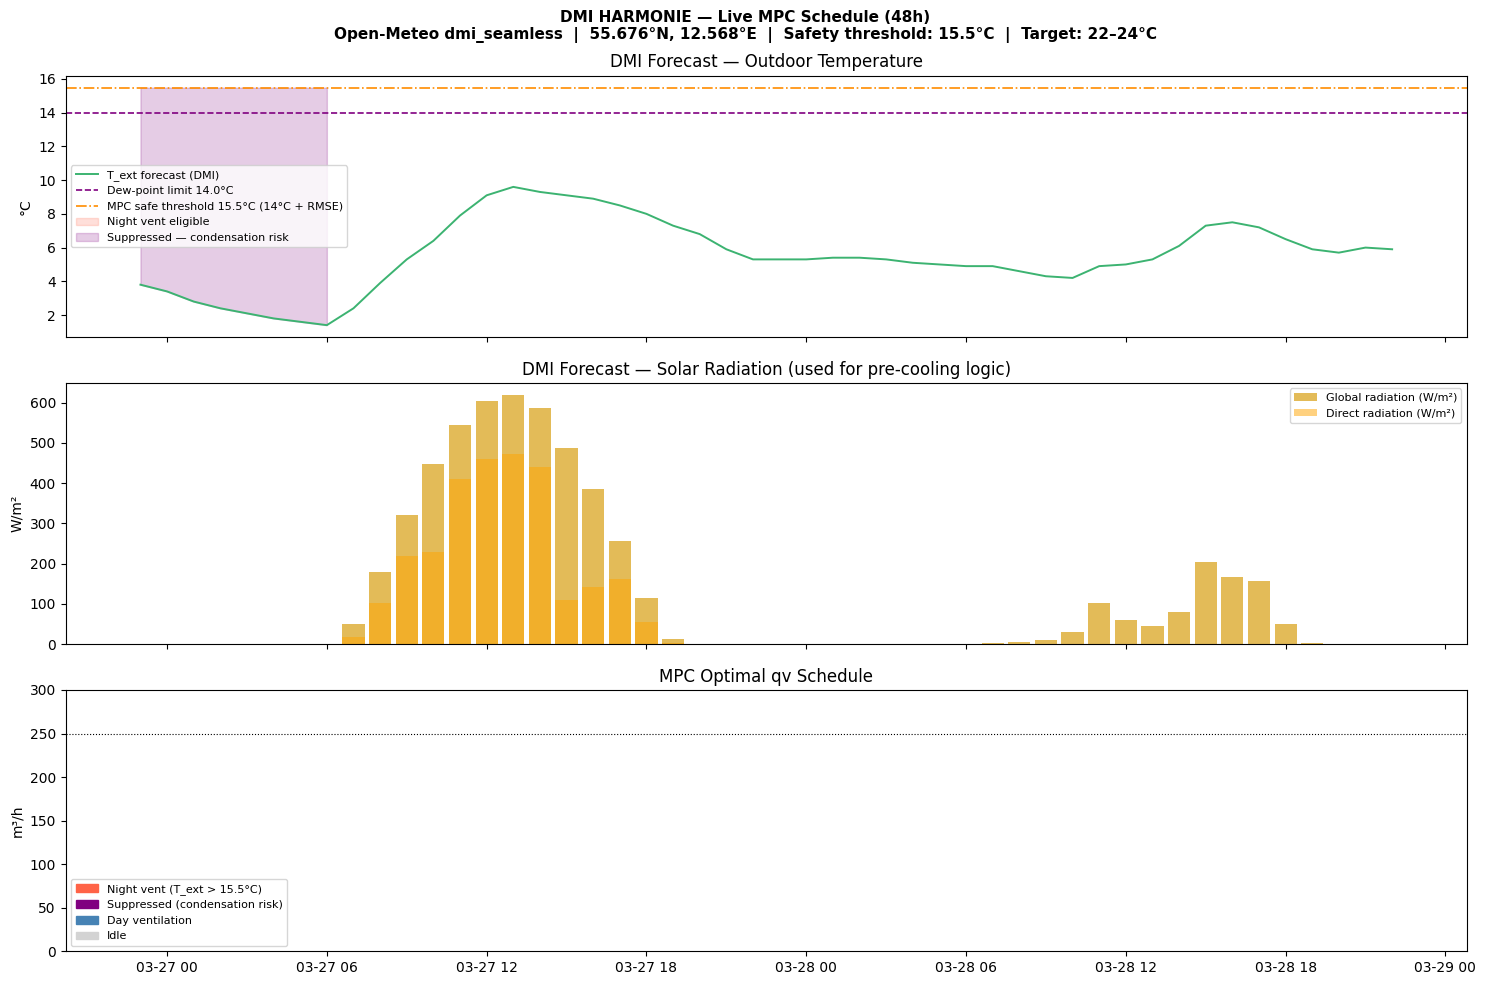

In [25]:
# ════════════════════════════════════════════════════════════════════════════
#  MPC — Live 48h forecast from Open-Meteo (DMI HARMONIE)
#  Fetch → build X_forecast → optimise qv → output schedule
#
#  endpoint : api.open-meteo.com  (live forecast, no key needed)
#  model    : dmi_seamless (HARMONIE for Denmark, best resolution)
#  Safety   : qv = 0 forced when T_ext ≤ safe_threshold (from validation)
# ════════════════════════════════════════════════════════════════════════════
from datetime import datetime, timezone, timedelta

MPC_HORIZON_H   = 48
# Use the validated safe threshold; falls back to 14°C if validation not run
try:
    MPC_SAFE_THRESHOLD = safe_threshold   # 14°C + RMSE from validation cell
except NameError:
    MPC_SAFE_THRESHOLD = TA_MIN_NIGHT_VENT + 1.5   # conservative fallback

print(f"MPC condensation safety threshold: {MPC_SAFE_THRESHOLD:.1f}°C")

def fetch_openmeteo_forecast(lat, lon, hours_ahead=48) -> pd.DataFrame:
    """
    Fetch live hourly DMI HARMONIE forecast from Open-Meteo.
    Returns DataFrame with T_ext (°C), radiation (W/m²), derived masks.
    """
    url = "https://api.open-meteo.com/v1/forecast"
    params = {
        "latitude"  : lat,
        "longitude" : lon,
        "hourly"    : ["temperature_2m",
                       "shortwave_radiation",
                       "direct_radiation",
                       "diffuse_radiation"],
        "models"    : "dmi_seamless",
        "forecast_hours": hours_ahead,
        "timezone"  : "Europe/Copenhagen",
    }
    resp = requests.get(url, params=params, timeout=20)
    resp.raise_for_status()
    h = resp.json()["hourly"]

    df = pd.DataFrame({
        "timestamp"      : pd.to_datetime(h["time"]).tz_localize(None),
        "T_ext"          : h["temperature_2m"],
        "rad_global"     : h["shortwave_radiation"],
        "rad_direct"     : h["direct_radiation"],
        "rad_diffuse"    : h["diffuse_radiation"],
    })
    hrs = df["timestamp"].dt.hour + df["timestamp"].dt.minute / 60.0
    wd  = df["timestamp"].dt.weekday

    df["is_night"]       = (hrs >= NIGHT_START) | (hrs < NIGHT_STOP)
    df["is_occ"]         = (hrs >= OCC_START)   & (hrs < OCC_END)
    # Next-morning weekday check (same as pre-computation)
    df["is_weekday_night"] = df.apply(
        lambda r: r["is_night"] and _next_morning_is_weekday(r["timestamp"]), axis=1)
    # Condensation constraint: use validated safe threshold
    df["ta_ok"]          = df["T_ext"] > MPC_SAFE_THRESHOLD
    df["vent_eligible"]  = df["is_weekday_night"] & df["ta_ok"]
    return df

def build_X_forecast(df_fc: pd.DataFrame) -> tuple:
    n_fc     = len(df_fc)
    n_hist = int(np.asarray(N_hist).flat[0])          # ← cast once here, use everywhere below

    X_fc = pd.DataFrame(
        np.tile(X_train.iloc[-1].values, (n_fc, 1)),
        columns=X_train.columns,
        index=df_fc["timestamp"],
    )
    X_fc["Ta"]   = df_fc["T_ext"].values
    X_fc["Tsup"] = np.where(
        df_fc["vent_eligible"].values,
        df_fc["T_ext"].values,
        X_train["Tsup"].mean()
    )
    X_fc["qv"] = qv_arr.mean()

    rad_cols = [c for c in X_train.columns
                if any(k in c.lower() for k in ["rad", "sol", "irr", "ghi"])]
    if rad_cols:
        X_fc[rad_cols[0]] = df_fc["rad_global"].values

    X_tail = X_train.iloc[-n_hist:].copy()    # ← uses int n_hist
    X_full = pd.concat([X_tail, X_fc], axis=0)
    return X_full, n_hist                      # ← returns int

def run_mpc_optimization(df_fc: pd.DataFrame,
                         Ti_current: float,
                         Tm_current: float = None,
                         c_current:  float = None) -> np.ndarray:

    X_full, fc_start = build_X_forecast(df_fc)
    n_fc    = len(df_fc)
    fc_sl   = slice(fc_start, fc_start + n_fc)

    # ── Extend N_profile to cover X_tail + X_forecast rows ───────────────────
    N_hist_arr = np.asarray(N_hist)
    # For forecast period: repeat the last known value (occupancy/profile)
    # Alternative: use the tail mean if the last value is unrepresentative
    N_hist_extended = np.concatenate([
        N_hist_arr,
        np.full(n_fc, N_hist_arr[-1])   # pad forecast rows with last value
    ])
    # ─────────────────────────────────────────────────────────────────────────

    Ti_init_mpc = Ti_current
    Tm_init_mpc = Tm_current if Tm_current is not None else Tm_init
    c_init_mpc  = c_current  if c_current  is not None else c_init

    eligible = df_fc["vent_eligible"].values

    def _obj(qv_vec):
        qv_safe = np.clip(np.nan_to_num(qv_vec, nan=QV_MAX / 2.0), QV_MIN, QV_MAX)

        X_run = X_full.copy()
        X_run.iloc[fc_sl, X_run.columns.get_loc("qv")]   = qv_safe
        X_run.iloc[fc_sl, X_run.columns.get_loc("Tsup")] = np.where(
            eligible, df_fc["T_ext"].values, X_train["Tsup"].mean()
        )
        res = simulate_night_vent_scenario(
            fitted_params, X_run, N_hist_extended,   # ← extended profile
            night_start_hour=0, night_stop_hour=0, qv_night=0,
            rec_duration=rec_duration,
            Ti_init=Ti_init_mpc, Tm_init=Tm_init_mpc, c_init=c_init_mpc
        )
        Ti_fc = res["Ti"].values[fc_start:]
        if not np.all(np.isfinite(Ti_fc)):
            return 1e10
        cost_temp   = float((np.maximum(0.0, Ti_fc - T_cat1_max)**2
                           + np.maximum(0.0, T_cat1_min - Ti_fc)**2).sum() * rec_duration)
        cost_energy = fan_cost(qv_safe)
        return W_TEMP_MO * cost_temp + W_COST_MO * cost_energy

    bounds = [
        (QV_MIN, QV_MAX) if eligible[i] or df_fc["is_occ"].iloc[i]
        else (0.0, 0.0)
        for i in range(n_fc)
    ]
    x0 = np.array([QV_MAX * 0.6 if eligible[i] else
                   QV_MAX * 0.4 if df_fc["is_occ"].iloc[i] else 0.0
                   for i in range(n_fc)])

    res_mpc = minimize(
        _obj, x0=x0, method="L-BFGS-B", bounds=bounds,
        options={"maxiter": 300, "ftol": 1e-9, "gtol": 1e-6, "eps": 0.5}
    )
    qv_mpc = np.clip(res_mpc.x, 0.0, QV_MAX)
    print(f"  MPC converged: {res_mpc.success}  |  combined cost: {res_mpc.fun:.4f}")
    return qv_mpc

# ── RUN ───────────────────────────────────────────────────────────────────────
Ti_sensor  = float(y_train.iloc[-1])   # ← replace with live sensor reading
print(f"Fetching {MPC_HORIZON_H}h DMI HARMONIE forecast (Open-Meteo)...")
df_fc = fetch_openmeteo_forecast(LAT, LON, hours_ahead=MPC_HORIZON_H)
print(f"  {len(df_fc)} steps fetched  |  "
      f"Night-eligible: {df_fc['vent_eligible'].sum()} steps  |  "
      f"Suppressed (Ta ≤ {MPC_SAFE_THRESHOLD:.1f}°C): "
      f"{(df_fc['is_weekday_night'] & ~df_fc['ta_ok']).sum()} steps")

print("Running MPC optimisation...")
qv_mpc = run_mpc_optimization(df_fc, Ti_current=Ti_sensor)

# ── DECISION TABLE ────────────────────────────────────────────────────────────
df_fc["qv_mpc"] = qv_mpc
df_fc["action"] = df_fc.apply(
    lambda r: "NIGHT_VENT"  if r["vent_eligible"] and r["qv_mpc"] > QV_MIN + 1
         else "SUPPRESSED"  if r["is_weekday_night"] and not r["ta_ok"]
         else "DAY_VENT"    if r["is_occ"] and r["qv_mpc"] > QV_MIN + 1
         else "IDLE",
    axis=1
)

print(f"\n{'═'*72}")
print(f"  MPC Schedule — {MPC_HORIZON_H}h ahead  |  Threshold: {MPC_SAFE_THRESHOLD:.1f}°C")
print(f"{'─'*72}")
print(f"  {'Timestamp':<22} {'T_ext':>6} {'Rad W/m²':>9} {'qv m³/h':>9}  Action")
print(f"{'─'*72}")
for _, r in df_fc.iterrows():
    flag = " ⚠" if r["action"] == "SUPPRESSED" else ""
    print(f"  {str(r['timestamp']):<22} {r['T_ext']:>5.1f}°C "
          f"{r['rad_global']:>8.0f} {r['qv_mpc']:>8.0f}  {r['action']}{flag}")
print(f"{'═'*72}")

# ── MPC FORECAST PLOT ─────────────────────────────────────────────────────────
fig_mpc, axes_mpc = plt.subplots(3, 1, figsize=(15, 10), sharex=True)
fig_mpc.suptitle(
    f"DMI HARMONIE — Live MPC Schedule ({MPC_HORIZON_H}h)\n"
    f"Open-Meteo dmi_seamless  |  {LAT}°N, {LON}°E  |  "
    f"Safety threshold: {MPC_SAFE_THRESHOLD:.1f}°C  |  Target: 22–24°C",
    fontsize=11, fontweight='bold'
)

ax = axes_mpc[0]
ax.plot(df_fc["timestamp"], df_fc["T_ext"],
        color='mediumseagreen', lw=1.4, label='T_ext forecast (DMI)')
ax.axhline(TA_MIN_NIGHT_VENT, color='purple', ls='--', lw=1.2,
           label=f'Dew-point limit {TA_MIN_NIGHT_VENT}°C')
ax.axhline(MPC_SAFE_THRESHOLD, color='darkorange', ls='-.', lw=1.2,
           label=f'MPC safe threshold {MPC_SAFE_THRESHOLD:.1f}°C (14°C + RMSE)')
ax.fill_between(df_fc["timestamp"], df_fc["T_ext"], MPC_SAFE_THRESHOLD,
    where=df_fc["vent_eligible"],
    alpha=0.2, color='tomato', label='Night vent eligible')
ax.fill_between(df_fc["timestamp"], df_fc["T_ext"], MPC_SAFE_THRESHOLD,
    where=df_fc["is_weekday_night"] & ~df_fc["ta_ok"],
    alpha=0.2, color='purple', label='Suppressed — condensation risk')
ax.set_ylabel('°C')
ax.legend(fontsize=8)
ax.set_title('DMI Forecast — Outdoor Temperature')

ax = axes_mpc[1]
ax.bar(df_fc["timestamp"], df_fc["rad_global"],
       width=pd.Timedelta(minutes=50), color='goldenrod', alpha=0.75,
       label='Global radiation (W/m²)')
ax.bar(df_fc["timestamp"], df_fc["rad_direct"],
       width=pd.Timedelta(minutes=50), color='orange', alpha=0.5,
       label='Direct radiation (W/m²)')
ax.set_ylabel('W/m²')
ax.legend(fontsize=8)
ax.set_title('DMI Forecast — Solar Radiation (used for pre-cooling logic)')

ax = axes_mpc[2]
action_colors = {
    "NIGHT_VENT" : "tomato",
    "SUPPRESSED" : "purple",
    "DAY_VENT"   : "steelblue",
    "IDLE"       : "lightgrey"
}
bar_colors = df_fc["action"].map(action_colors)
ax.bar(df_fc["timestamp"], df_fc["qv_mpc"],
       width=pd.Timedelta(minutes=50),
       color=bar_colors, alpha=0.85)
ax.axhline(QV_MAX, color='black', ls=':', lw=0.8,
           label=f'qv_max = {QV_MAX:.0f} m³/h')
from matplotlib.patches import Patch
legend_elements = [
    Patch(color='tomato',    label=f'Night vent (T_ext > {MPC_SAFE_THRESHOLD:.1f}°C)'),
    Patch(color='purple',    label='Suppressed (condensation risk)'),
    Patch(color='steelblue', label='Day ventilation'),
    Patch(color='lightgrey', label='Idle'),
]
ax.legend(handles=legend_elements, fontsize=8)
ax.set_ylabel('m³/h')
ax.set_ylim(0, QV_MAX * 1.2)
ax.set_title('MPC Optimal qv Schedule')

plt.tight_layout()
plt.savefig('dmi_mpc_schedule.png', dpi=150, bbox_inches='tight')
plt.show()